# Public Reproduction Notebook: Five Structure-First Figures

This notebook rebuilds the five public manuscript figures directly from the embedded
`experiments` registry already present in this repository.

The notebook is designed for public reproduction and exposes three main switches:

- correlation feature family: `60corr` or `20corr`
- task regime: `26task` or `30task`
- correlation channel frame: `4ch` or `14ch`

All CSV outputs are written to `Repro_CSV`.
All figures are written to `Repro_Figure`.

## Quick start

This notebook is meant to be used in the following order.

1. Set the frame switches in the **Global configuration** cell.
2. Optionally paste a full `experiments` object into the **Optional direct override** cell.
3. Run all cells from top to bottom.
4. Read the generated outputs in:
   - `Repro_CSV`
   - `Repro_Figure`

The notebook generates five figure families for the currently selected primary frame:

- Figure 1: correlation counts vs null
- Figure 2: topology separation
- Figure 3: temporal phase around peak coupling
- Figure 4: null robustness of the topology signature
- Figure 5: sensitivity to observation frame

Figure file names are prefixed by the current frame key, for example:

- `4ch_60corr_26task_Figure1_correlation_counts.png`
- `4ch_60corr_26task_Figure2_topology_separation.png`

In [65]:
# Global configuration

from pathlib import Path

REPRO_CSV_DIR = Path("Repro_CSV")
REPRO_FIG_DIR = Path("Repro_Figure")
REPRO_CSV_DIR.mkdir(parents=True, exist_ok=True)
REPRO_FIG_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_NOTEBOOK = Path("public_repro_from_embedded_experiments.ipynb")
DATA_ROOT = Path(".")

PRIMARY_CHANNEL_MODE = "4ch"      # "4ch" or "14ch"
PRIMARY_FEATURE_MODE = "60corr"   # "60corr" or "20corr"
PRIMARY_TASK_MODE = "26task"      # "26task" or "30task"

TOPOLOGY_CHANNEL_MODE = "all14"   # "all14" or "match_correlation"


NULL_ITERATIONS = 100
NULL_SEED = 20260501
FORCE_RECOMPUTE = True

FRAME_COMPARISON = [
    ("4ch", "60corr", "26task"),
    ("4ch", "20corr", "26task"),
    ("14ch", "20corr", "30task"),
]

print("CSV output directory:", REPRO_CSV_DIR.resolve())
print("Figure output directory:", REPRO_FIG_DIR.resolve())
print("Primary frame:", PRIMARY_CHANNEL_MODE, PRIMARY_FEATURE_MODE, PRIMARY_TASK_MODE)
print("Topology channel mode:", TOPOLOGY_CHANNEL_MODE)

CSV output directory: /Users/satoru/python_envs/Repro_CSV
Figure output directory: /Users/satoru/python_envs/Repro_Figure
Primary frame: 4ch 60corr 26task
Topology channel mode: all14


## Configuration guide

The four main switches are defined in the **Global configuration** cell.

### Primary frame switches

- `PRIMARY_CHANNEL_MODE`
  - `"4ch"`: use the fixed sparse channel set `AF3 + F7 + FC5 + FC6`
  - `"14ch"`: use all 14 EEG channels for the correlation screen

- `PRIMARY_FEATURE_MODE`
  - `"60corr"`: use `5 bands × 3 EEG features × 4 quantum states`
  - `"20corr"`: use `5 bands × 1 EEG feature (mean only) × 4 quantum states`

- `PRIMARY_TASK_MODE`
  - `"26task"`: use the back-4 trimmed task sequence
  - `"30task"`: use the full task sequence without back trimming

### Topology switch

- `TOPOLOGY_CHANNEL_MODE`
  - `"all14"`: compute topology on the full 14-channel network
  - `"match_correlation"`: compute topology on the same channels used for the correlation screen

### Frame-comparison switch used by Figure 5

Edit `FRAME_COMPARISON` to choose which frames appear in Figure 5.
Each tuple has the form:

- `(channel_mode, feature_mode, task_mode)`

The default comparison is:

- `("4ch", "60corr", "26task")`
- `("4ch", "20corr", "26task")`
- `("14ch", "20corr", "30task")`

## Minimal usage examples

To reproduce the main manuscript frame:

```python
PRIMARY_CHANNEL_MODE = "4ch"
PRIMARY_FEATURE_MODE = "60corr"
PRIMARY_TASK_MODE = "26task"
TOPOLOGY_CHANNEL_MODE = "all14"
```

To test the mean-only sparse alternative:

```python
PRIMARY_CHANNEL_MODE = "4ch"
PRIMARY_FEATURE_MODE = "20corr"
PRIMARY_TASK_MODE = "26task"
TOPOLOGY_CHANNEL_MODE = "all14"
```

To test the full-channel mean-only frame:

```python
PRIMARY_CHANNEL_MODE = "14ch"
PRIMARY_FEATURE_MODE = "20corr"
PRIMARY_TASK_MODE = "30task"
TOPOLOGY_CHANNEL_MODE = "all14"
```

## Optional direct override

If you already have a full `experiments` object in this notebook or want to paste one
manually, use the next cell. Otherwise, leave it untouched and the notebook will fall
back to `SOURCE_NOTEBOOK`.

In [66]:
# Optional override:
# experiments = [...]

import os
EEG_DIR = "IDPC_EEG"
experiments = [

    {
        "label": "P1",
        "EEG_CSV": os.path.join(EEG_DIR, "P1_EPOCX_354842_2025.12.22T08.01.58+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 9ad4ecab-5b26-44b8-a78d-5f89d4f42e1c
Measurement Counts: Counter({'10': 30, '00': 26, '11': 23, '01': 21})
Task Start: 2025-12-21 23:02:15.731000+00:00
Task End: 2025-12-21 23:02:16.771000+00:00
----------------------------------------
2. Task ID: c67b0819-3a27-435b-b6d5-94767ab7a6a0
Measurement Counts: Counter({'11': 29, '10': 26, '01': 23, '00': 22})
Task Start: 2025-12-21 23:02:22.019000+00:00
Task End: 2025-12-21 23:02:22.609000+00:00
----------------------------------------
3. Task ID: 473b8089-9103-45ca-911d-2085ec3e715d
Measurement Counts: Counter({'10': 27, '01': 26, '00': 25, '11': 22})
Task Start: 2025-12-21 23:02:28.254000+00:00
Task End: 2025-12-21 23:02:28.792000+00:00
----------------------------------------
4. Task ID: a6b01cee-513c-495a-af62-4125df50dff0
Measurement Counts: Counter({'00': 30, '01': 27, '10': 23, '11': 20})
Task Start: 2025-12-21 23:02:35.175000+00:00
Task End: 2025-12-21 23:02:36.012000+00:00
----------------------------------------
5. Task ID: 9c9f259b-4813-4f9f-b593-065418441ba7
Measurement Counts: Counter({'10': 30, '11': 26, '00': 25, '01': 19})
Task Start: 2025-12-21 23:02:40.601000+00:00
Task End: 2025-12-21 23:02:41.152000+00:00
----------------------------------------
6. Task ID: 48e6c2ae-9f2c-46c3-84c0-d020e9dcc590
Measurement Counts: Counter({'10': 30, '00': 27, '11': 23, '01': 20})
Task Start: 2025-12-21 23:02:46.246000+00:00
Task End: 2025-12-21 23:02:46.799000+00:00
----------------------------------------
7. Task ID: 24739bb9-d517-424f-84c2-638e794b351e
Measurement Counts: Counter({'11': 28, '10': 27, '00': 25, '01': 20})
Task Start: 2025-12-21 23:02:51.217000+00:00
Task End: 2025-12-21 23:02:52.054000+00:00
----------------------------------------
8. Task ID: df390424-598c-4b3e-87c1-5a5b84f55e87
Measurement Counts: Counter({'00': 35, '11': 27, '10': 21, '01': 17})
Task Start: 2025-12-21 23:02:56.391000+00:00
Task End: 2025-12-21 23:02:56.928000+00:00
----------------------------------------
9. Task ID: d72b8333-9260-4772-8bf2-96cfc87f2f35
Measurement Counts: Counter({'00': 33, '01': 24, '10': 23, '11': 20})
Task Start: 2025-12-21 23:03:00.275000+00:00
Task End: 2025-12-21 23:03:00.831000+00:00
----------------------------------------
10. Task ID: 5b0e0b4b-e3df-4c0c-880c-a8d8cf446848
Measurement Counts: Counter({'00': 37, '11': 25, '01': 20, '10': 18})
Task Start: 2025-12-21 23:03:05.099000+00:00
Task End: 2025-12-21 23:03:05.648000+00:00
----------------------------------------
11. Task ID: 49471b2c-2b49-4aa7-a89d-be880ed2e1aa
Measurement Counts: Counter({'00': 34, '01': 25, '11': 21, '10': 20})
Task Start: 2025-12-21 23:03:09.078000+00:00
Task End: 2025-12-21 23:03:09.907000+00:00
----------------------------------------
12. Task ID: 7c4097b7-875d-4569-8548-0cfe815299f8
Measurement Counts: Counter({'11': 28, '00': 26, '10': 26, '01': 20})
Task Start: 2025-12-21 23:03:14.190000+00:00
Task End: 2025-12-21 23:03:14.747000+00:00
----------------------------------------
13. Task ID: 40ff2d38-7804-45c7-bae4-974a48198388
Measurement Counts: Counter({'00': 27, '11': 25, '01': 25, '10': 23})
Task Start: 2025-12-21 23:03:20.284000+00:00
Task End: 2025-12-21 23:03:20.848000+00:00
----------------------------------------
14. Task ID: 7c5dccc3-d482-4bb2-b5c1-b0cd956018c2
Measurement Counts: Counter({'00': 33, '10': 28, '11': 21, '01': 18})
Task Start: 2025-12-21 23:03:23.197000+00:00
Task End: 2025-12-21 23:03:23.826000+00:00
----------------------------------------
15. Task ID: 258806fd-d03d-459f-9214-79244d6f4c1a
Measurement Counts: Counter({'01': 33, '10': 27, '00': 22, '11': 18})
Task Start: 2025-12-21 23:03:28.247000+00:00
Task End: 2025-12-21 23:03:28.800000+00:00
----------------------------------------
16. Task ID: c340201d-9034-4003-9919-d94ad2b1f74a
Measurement Counts: Counter({'10': 33, '00': 29, '11': 22, '01': 16})
Task Start: 2025-12-21 23:03:33.640000+00:00
Task End: 2025-12-21 23:03:34.165000+00:00
----------------------------------------
17. Task ID: afd9bc0b-a199-4f95-b1be-cee436686aaa
Measurement Counts: Counter({'10': 27, '00': 26, '01': 25, '11': 22})
Task Start: 2025-12-21 23:03:37.523000+00:00
Task End: 2025-12-21 23:03:38.051000+00:00
----------------------------------------
18. Task ID: 0e53b263-9b89-45b6-9264-6b353ee23c2e
Measurement Counts: Counter({'00': 31, '10': 26, '01': 22, '11': 21})
Task Start: 2025-12-21 23:03:42.323000+00:00
Task End: 2025-12-21 23:03:43.091000+00:00
----------------------------------------
19. Task ID: 8607247b-b918-45b6-9390-ecb64986efa8
Measurement Counts: Counter({'00': 29, '01': 25, '10': 24, '11': 22})
Task Start: 2025-12-21 23:03:47.213000+00:00
Task End: 2025-12-21 23:03:47.749000+00:00
----------------------------------------
20. Task ID: 8ea5c0f4-0b06-4ecb-b55e-60fc1f9d59d6
Measurement Counts: Counter({'00': 35, '10': 27, '01': 21, '11': 17})
Task Start: 2025-12-21 23:03:51.622000+00:00
Task End: 2025-12-21 23:03:52.176000+00:00
----------------------------------------
21. Task ID: 2a10262b-dace-4e07-948f-c4d1fc31633d
Measurement Counts: Counter({'10': 30, '00': 28, '11': 23, '01': 19})
Task Start: 2025-12-21 23:03:55.981000+00:00
Task End: 2025-12-21 23:03:56.558000+00:00
----------------------------------------
22. Task ID: c0093e7a-098d-46d4-9a03-60702e34688e
Measurement Counts: Counter({'00': 37, '10': 22, '11': 21, '01': 20})
Task Start: 2025-12-21 23:04:00.467000+00:00
Task End: 2025-12-21 23:04:01.267000+00:00
----------------------------------------
23. Task ID: 896b0f86-843a-428c-be14-41d22d3908e8
Measurement Counts: Counter({'00': 31, '11': 25, '01': 22, '10': 22})
Task Start: 2025-12-21 23:04:03.933000+00:00
Task End: 2025-12-21 23:04:04.493000+00:00
----------------------------------------
24. Task ID: 4d85d212-085d-4c9e-b9a6-1f56940418b2
Measurement Counts: Counter({'00': 33, '11': 31, '10': 25, '01': 11})
Task Start: 2025-12-21 23:04:06.967000+00:00
Task End: 2025-12-21 23:04:07.530000+00:00
----------------------------------------
25. Task ID: b8fec67d-235c-40e2-a9fd-5ce6ce81c380
Measurement Counts: Counter({'00': 32, '10': 30, '11': 22, '01': 16})
Task Start: 2025-12-21 23:04:11.045000+00:00
Task End: 2025-12-21 23:04:12.751000+00:00
----------------------------------------
26. Task ID: 80254673-9def-487d-b5e5-60e05a6554f1
Measurement Counts: Counter({'00': 35, '10': 23, '11': 22, '01': 20})
Task Start: 2025-12-21 23:04:16.538000+00:00
Task End: 2025-12-21 23:04:17.350000+00:00
----------------------------------------
27. Task ID: 5b867347-e8a5-492e-aa23-a8a461253f12
Measurement Counts: Counter({'10': 30, '11': 28, '01': 22, '00': 20})
Task Start: 2025-12-21 23:04:24.581000+00:00
Task End: 2025-12-21 23:04:25.134000+00:00
----------------------------------------
28. Task ID: 328a6440-0033-43ee-8eae-0f6bf3b7020b
Measurement Counts: Counter({'10': 30, '01': 24, '00': 24, '11': 22})
Task Start: 2025-12-21 23:04:28.511000+00:00
Task End: 2025-12-21 23:04:29.038000+00:00
----------------------------------------
29. Task ID: d9876dda-c820-47a5-b3af-dd54dfcae37c
Measurement Counts: Counter({'00': 34, '01': 25, '11': 23, '10': 18})
Task Start: 2025-12-21 23:04:31.566000+00:00
Task End: 2025-12-21 23:04:32.141000+00:00
----------------------------------------
30. Task ID: 9aea1835-00e3-4d79-9e2d-e9288328d6b1
Measurement Counts: Counter({'00': 29, '11': 27, '10': 23, '01': 21})
Task Start: 2025-12-21 23:04:35.354000+00:00
Task End: 2025-12-21 23:04:36.107000+00:00
----------------------------------------"""
    },
    {
        "label": "P2",
        "EEG_CSV": os.path.join(EEG_DIR, "P2_EPOCX_354842_2025.12.26T00.24.37+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 484a06cc-3706-406c-8047-ffd0b8818a82
Measurement Counts: Counter({'00': 36, '10': 27, '11': 20, '01': 17})
Task Start: 2025-12-25 15:24:49.542000+00:00
Task End: 2025-12-25 15:24:50.453000+00:00
----------------------------------------
2. Task ID: 9a5c3953-d682-410d-8d87-ef712cb9c84f
Measurement Counts: Counter({'01': 32, '10': 30, '00': 20, '11': 18})
Task Start: 2025-12-25 15:24:55.121000+00:00
Task End: 2025-12-25 15:24:55.591000+00:00
----------------------------------------
3. Task ID: 623e747e-0935-4a49-8e38-2b5891287b44
Measurement Counts: Counter({'00': 34, '10': 28, '11': 21, '01': 17})
Task Start: 2025-12-25 15:24:58.921000+00:00
Task End: 2025-12-25 15:24:59.449000+00:00
----------------------------------------
4. Task ID: e3ef3aea-fd4a-40e4-924c-93b8654df924
Measurement Counts: Counter({'00': 34, '01': 24, '11': 24, '10': 18})
Task Start: 2025-12-25 15:25:02.697000+00:00
Task End: 2025-12-25 15:25:03.197000+00:00
----------------------------------------
5. Task ID: 6c27d37c-465c-4baf-a60a-046ad7f27689
Measurement Counts: Counter({'00': 37, '10': 27, '11': 20, '01': 16})
Task Start: 2025-12-25 15:25:05.570000+00:00
Task End: 2025-12-25 15:25:06.338000+00:00
----------------------------------------
6. Task ID: 437858fd-2010-4b68-989e-d747f78c01e8
Measurement Counts: Counter({'10': 32, '11': 28, '00': 27, '01': 13})
Task Start: 2025-12-25 15:25:09.396000+00:00
Task End: 2025-12-25 15:25:09.881000+00:00
----------------------------------------
7. Task ID: 5eb57445-a619-48e7-b606-f2255109f314
Measurement Counts: Counter({'00': 38, '10': 26, '11': 20, '01': 16})
Task Start: 2025-12-25 15:25:12.976000+00:00
Task End: 2025-12-25 15:25:13.458000+00:00
----------------------------------------
8. Task ID: ff897d28-c62b-41e2-a677-2f0d79bbc48c
Measurement Counts: Counter({'00': 36, '10': 28, '11': 23, '01': 13})
Task Start: 2025-12-25 15:25:15.608000+00:00
Task End: 2025-12-25 15:25:16.061000+00:00
----------------------------------------
9. Task ID: d33592f7-04d7-4d75-851e-a18192348d39
Measurement Counts: Counter({'00': 38, '11': 29, '10': 19, '01': 14})
Task Start: 2025-12-25 15:25:19.520000+00:00
Task End: 2025-12-25 15:25:20.067000+00:00
----------------------------------------
10. Task ID: a64edc29-17ee-462f-b4a0-88573c9d8a95
Measurement Counts: Counter({'00': 33, '01': 29, '10': 24, '11': 14})
Task Start: 2025-12-25 15:25:23.248000+00:00
Task End: 2025-12-25 15:25:23.993000+00:00
----------------------------------------
11. Task ID: b057cf63-0057-437b-a189-9f232851e2be
Measurement Counts: Counter({'00': 38, '11': 28, '10': 18, '01': 16})
Task Start: 2025-12-25 15:25:27.187000+00:00
Task End: 2025-12-25 15:25:27.629000+00:00
----------------------------------------
12. Task ID: 14782955-3c86-4790-8590-ddd01d8a682b
Measurement Counts: Counter({'00': 27, '11': 25, '10': 24, '01': 24})
Task Start: 2025-12-25 15:25:29.954000+00:00
Task End: 2025-12-25 15:25:30.407000+00:00
----------------------------------------
13. Task ID: e3dcd022-099a-4423-b246-1e0e93dd16d6
Measurement Counts: Counter({'01': 29, '11': 28, '00': 26, '10': 17})
Task Start: 2025-12-25 15:25:33.673000+00:00
Task End: 2025-12-25 15:25:34.157000+00:00
----------------------------------------
14. Task ID: e90739d7-18cd-419e-b92d-6b9fcf0bf325
Measurement Counts: Counter({'00': 38, '10': 31, '11': 18, '01': 13})
Task Start: 2025-12-25 15:25:37.470000+00:00
Task End: 2025-12-25 15:25:38.010000+00:00
----------------------------------------
15. Task ID: 6b87579c-0b1a-49b4-bb07-2ab532484553
Measurement Counts: Counter({'10': 33, '00': 27, '11': 21, '01': 19})
Task Start: 2025-12-25 15:25:40.342000+00:00
Task End: 2025-12-25 15:25:41.056000+00:00
----------------------------------------
16. Task ID: a7310c36-7751-4bd8-971e-e0eea2f3e0ec
Measurement Counts: Counter({'00': 38, '10': 23, '01': 20, '11': 19})
Task Start: 2025-12-25 15:25:44.035000+00:00
Task End: 2025-12-25 15:25:44.585000+00:00
----------------------------------------
17. Task ID: 2b49428d-9659-4814-b996-0a62f2e3cbe1
Measurement Counts: Counter({'11': 31, '00': 28, '10': 27, '01': 14})
Task Start: 2025-12-25 15:25:47.460000+00:00
Task End: 2025-12-25 15:25:47.965000+00:00
----------------------------------------
18. Task ID: 3c774c06-efec-4820-aca8-500ac087e7f3
Measurement Counts: Counter({'10': 29, '00': 26, '01': 26, '11': 19})
Task Start: 2025-12-25 15:25:51.670000+00:00
Task End: 2025-12-25 15:25:52.178000+00:00
----------------------------------------
19. Task ID: 15474c2f-0891-492e-a364-f0f8d03f613c
Measurement Counts: Counter({'00': 33, '10': 26, '11': 23, '01': 18})
Task Start: 2025-12-25 15:25:54.616000+00:00
Task End: 2025-12-25 15:25:55.164000+00:00
----------------------------------------
20. Task ID: 6978d0eb-28d2-4ea9-a1d0-9daebeb7231d
Measurement Counts: Counter({'00': 36, '10': 26, '11': 24, '01': 14})
Task Start: 2025-12-25 15:25:57.802000+00:00
Task End: 2025-12-25 15:25:58.491000+00:00
----------------------------------------
21. Task ID: 95a1cedf-e6cf-4f53-8334-6485f31058b2
Measurement Counts: Counter({'10': 34, '00': 27, '01': 21, '11': 18})
Task Start: 2025-12-25 15:26:03.617000+00:00
Task End: 2025-12-25 15:26:04.080000+00:00
----------------------------------------
22. Task ID: d91c5fc6-b2e5-429b-ab7a-3e5aa9be5233
Measurement Counts: Counter({'00': 30, '10': 25, '11': 24, '01': 21})
Task Start: 2025-12-25 15:26:10.690000+00:00
Task End: 2025-12-25 15:26:11.166000+00:00
----------------------------------------
23. Task ID: d361e59f-fd3c-444c-9e12-8edc18bac2a3
Measurement Counts: Counter({'00': 35, '10': 26, '01': 20, '11': 19})
Task Start: 2025-12-25 15:26:14.539000+00:00
Task End: 2025-12-25 15:26:15.233000+00:00
----------------------------------------
24. Task ID: b61eb318-6bbb-433b-96f8-866f6a2befa1
Measurement Counts: Counter({'10': 35, '00': 25, '01': 24, '11': 16})
Task Start: 2025-12-25 15:26:18.759000+00:00
Task End: 2025-12-25 15:26:19.286000+00:00
----------------------------------------
25. Task ID: ff954373-e3d9-4c1b-91dd-9aefb7b37b98
Measurement Counts: Counter({'00': 38, '10': 29, '01': 22, '11': 11})
Task Start: 2025-12-25 15:26:21.966000+00:00
Task End: 2025-12-25 15:26:22.461000+00:00
----------------------------------------
26. Task ID: cba367ad-d4ed-42a8-8586-b7d6065e8e32
Measurement Counts: Counter({'11': 32, '00': 26, '10': 24, '01': 18})
Task Start: 2025-12-25 15:26:26.359000+00:00
Task End: 2025-12-25 15:26:26.848000+00:00
----------------------------------------
27. Task ID: e7a33f39-9bf7-4745-b008-d6e4da7c879e
Measurement Counts: Counter({'10': 32, '00': 28, '11': 22, '01': 18})
Task Start: 2025-12-25 15:26:29.259000+00:00
Task End: 2025-12-25 15:26:29.823000+00:00
----------------------------------------
28. Task ID: 483f2ba6-c282-4761-8eab-473878c58eb0
Measurement Counts: Counter({'00': 27, '01': 26, '11': 26, '10': 21})
Task Start: 2025-12-25 15:26:36.825000+00:00
Task End: 2025-12-25 15:26:37.593000+00:00
----------------------------------------
29. Task ID: e1cd2766-97a1-4df6-8c8e-fa33028d1a6f
Measurement Counts: Counter({'00': 37, '10': 22, '01': 21, '11': 20})
Task Start: 2025-12-25 15:26:46.664000+00:00
Task End: 2025-12-25 15:26:47.171000+00:00
----------------------------------------
30. Task ID: f3a524bb-0405-49f6-acba-1fd7b24773ca
Measurement Counts: Counter({'11': 31, '00': 30, '10': 25, '01': 14})
Task Start: 2025-12-25 15:26:53.912000+00:00
Task End: 2025-12-25 15:26:54.670000+00:00
----------------------------------------"""
    },
    {
        "label": "P3",
        "EEG_CSV": os.path.join(EEG_DIR, "P3_EPOCX_354842_2026.01.02T11.33.41+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 4f06283d-201f-4623-89ff-4e592a47356f
Measurement Counts: Counter({'00': 36, '01': 23, '11': 21, '10': 20})
Task Start: 2026-01-02 02:34:38.499000+00:00
Task End: 2026-01-02 02:34:41.384000+00:00
----------------------------------------
2. Task ID: 42879ed5-3b58-467b-9406-3b09d3a5e62d
Measurement Counts: Counter({'00': 34, '01': 29, '10': 22, '11': 15})
Task Start: 2026-01-02 02:34:47.018000+00:00
Task End: 2026-01-02 02:34:47.548000+00:00
----------------------------------------
3. Task ID: c2999d55-815f-4cfc-9c3d-a7ed36d7489f
Measurement Counts: Counter({'00': 36, '10': 23, '11': 22, '01': 19})
Task Start: 2026-01-02 02:34:56.297000+00:00
Task End: 2026-01-02 02:34:57.027000+00:00
----------------------------------------
4. Task ID: adcca37b-e407-491d-819f-fe575105c95e
Measurement Counts: Counter({'00': 33, '10': 25, '11': 22, '01': 20})
Task Start: 2026-01-02 02:35:02.678000+00:00
Task End: 2026-01-02 02:35:03.173000+00:00
----------------------------------------
5. Task ID: e2701a6f-3fad-4aab-9a4a-df5c41d0d612
Measurement Counts: Counter({'00': 37, '10': 25, '01': 21, '11': 17})
Task Start: 2026-01-02 02:35:08.456000+00:00
Task End: 2026-01-02 02:35:09.005000+00:00
----------------------------------------
6. Task ID: 0151a3e0-1a0d-4bc2-991f-789419e61687
Measurement Counts: Counter({'00': 29, '10': 27, '11': 24, '01': 20})
Task Start: 2026-01-02 02:35:14.576000+00:00
Task End: 2026-01-02 02:35:15.395000+00:00
----------------------------------------
7. Task ID: a5024b4c-fa57-4582-a407-f71bba44af2d
Measurement Counts: Counter({'00': 28, '10': 27, '01': 23, '11': 22})
Task Start: 2026-01-02 02:35:20.818000+00:00
Task End: 2026-01-02 02:35:21.374000+00:00
----------------------------------------
8. Task ID: 6901194b-eb59-48a5-a306-5cb9befa5f43
Measurement Counts: Counter({'10': 37, '00': 35, '01': 18, '11': 10})
Task Start: 2026-01-02 02:35:26.037000+00:00
Task End: 2026-01-02 02:35:26.556000+00:00
----------------------------------------
9. Task ID: 5c17cde4-45af-426b-8170-940ea5964f22
Measurement Counts: Counter({'00': 40, '01': 29, '10': 18, '11': 13})
Task Start: 2026-01-02 02:35:31.198000+00:00
Task End: 2026-01-02 02:35:31.893000+00:00
----------------------------------------
10. Task ID: 435c95d4-ec03-40ca-b8ee-c535b6f80183
Measurement Counts: Counter({'10': 30, '01': 26, '00': 24, '11': 20})
Task Start: 2026-01-02 02:35:36.377000+00:00
Task End: 2026-01-02 02:35:36.883000+00:00
----------------------------------------
11. Task ID: 3de9fb36-69af-43be-9634-325b0c60ddf8
Measurement Counts: Counter({'00': 33, '11': 27, '10': 20, '01': 20})
Task Start: 2026-01-02 02:35:42.141000+00:00
Task End: 2026-01-02 02:35:42.679000+00:00
----------------------------------------
12. Task ID: ca5e56bc-e129-473a-9abf-8c0e6a4f494b
Measurement Counts: Counter({'00': 38, '01': 23, '10': 21, '11': 18})
Task Start: 2026-01-02 02:35:48.317000+00:00
Task End: 2026-01-02 02:35:48.981000+00:00
----------------------------------------
13. Task ID: be81ddcb-3870-4b6d-b240-d1aef595eb9f
Measurement Counts: Counter({'00': 38, '10': 27, '01': 18, '11': 17})
Task Start: 2026-01-02 02:36:00.157000+00:00
Task End: 2026-01-02 02:36:00.737000+00:00
----------------------------------------
14. Task ID: 53553182-c321-450f-802e-50a3f1822b62
Measurement Counts: Counter({'00': 37, '11': 25, '01': 21, '10': 17})
Task Start: 2026-01-02 02:36:06.519000+00:00
Task End: 2026-01-02 02:36:07.274000+00:00
----------------------------------------
15. Task ID: 5bfce1d6-bac2-4cb6-98ca-e94f1c91d593
Measurement Counts: Counter({'00': 47, '10': 23, '11': 16, '01': 14})
Task Start: 2026-01-02 02:36:12.517000+00:00
Task End: 2026-01-02 02:36:13.060000+00:00
----------------------------------------
16. Task ID: 233175bc-faae-4bc8-a03d-368a81bf8986
Measurement Counts: Counter({'00': 35, '10': 26, '11': 20, '01': 19})
Task Start: 2026-01-02 02:36:19.258000+00:00
Task End: 2026-01-02 02:36:19.776000+00:00
----------------------------------------
17. Task ID: 6dcc5322-ef65-4578-b157-cb308917caea
Measurement Counts: Counter({'00': 40, '01': 23, '11': 19, '10': 18})
Task Start: 2026-01-02 02:36:24.220000+00:00
Task End: 2026-01-02 02:36:24.967000+00:00
----------------------------------------
18. Task ID: 6476a670-e054-4d3d-a05e-41e526740451
Measurement Counts: Counter({'01': 28, '00': 25, '10': 24, '11': 23})
Task Start: 2026-01-02 02:36:30.699000+00:00
Task End: 2026-01-02 02:36:31.205000+00:00
----------------------------------------
19. Task ID: e09f32be-8cc2-4375-aec3-d8ac043dded9
Measurement Counts: Counter({'00': 41, '10': 29, '11': 17, '01': 13})
Task Start: 2026-01-02 02:36:35.517000+00:00
Task End: 2026-01-02 02:36:36.018000+00:00
----------------------------------------
20. Task ID: 1137b0e1-2e7c-4b69-adca-68e491e40242
Measurement Counts: Counter({'00': 30, '10': 26, '11': 22, '01': 22})
Task Start: 2026-01-02 02:36:42.477000+00:00
Task End: 2026-01-02 02:36:43.272000+00:00
----------------------------------------
21. Task ID: dd906436-76c0-401b-b1b4-390a34fca1ca
Measurement Counts: Counter({'10': 29, '00': 27, '11': 23, '01': 21})
Task Start: 2026-01-02 02:36:47.257000+00:00
Task End: 2026-01-02 02:36:47.762000+00:00
----------------------------------------
22. Task ID: e466e8e9-7054-4719-be72-e6cb23856853
Measurement Counts: Counter({'00': 31, '10': 30, '01': 20, '11': 19})
Task Start: 2026-01-02 02:36:53.599000+00:00
Task End: 2026-01-02 02:36:54.087000+00:00
----------------------------------------
23. Task ID: f6fc3845-8d42-4ed1-aef2-6898cdae5aa1
Measurement Counts: Counter({'00': 33, '01': 31, '11': 20, '10': 16})
Task Start: 2026-01-02 02:36:57.817000+00:00
Task End: 2026-01-02 02:36:58.578000+00:00
----------------------------------------
24. Task ID: cac58b00-dca6-4c8f-b4b1-d746d6b28862
Measurement Counts: Counter({'00': 34, '10': 24, '01': 24, '11': 18})
Task Start: 2026-01-02 02:37:04.504000+00:00
Task End: 2026-01-02 02:37:04.982000+00:00
----------------------------------------
25. Task ID: 49670e3d-21f3-4724-97aa-31cb026c34f0
Measurement Counts: Counter({'10': 27, '00': 27, '11': 25, '01': 21})
Task Start: 2026-01-02 02:37:09.557000+00:00
Task End: 2026-01-02 02:37:10.032000+00:00
----------------------------------------
26. Task ID: 8e453e33-4d31-4ab0-9ccc-a51f79d918f4
Measurement Counts: Counter({'00': 33, '01': 31, '10': 18, '11': 18})
Task Start: 2026-01-02 02:37:16.741000+00:00
Task End: 2026-01-02 02:37:17.457000+00:00
----------------------------------------
27. Task ID: 37088cc7-3f9e-4a3b-984a-498adb5a9015
Measurement Counts: Counter({'00': 37, '01': 22, '10': 22, '11': 19})
Task Start: 2026-01-02 02:37:23.038000+00:00
Task End: 2026-01-02 02:37:23.559000+00:00
----------------------------------------
28. Task ID: 86e5a9b5-7ce8-46a4-8506-0f7871e1a91d
Measurement Counts: Counter({'00': 36, '01': 29, '10': 22, '11': 13})
Task Start: 2026-01-02 02:37:28.358000+00:00
Task End: 2026-01-02 02:37:28.826000+00:00
----------------------------------------
29. Task ID: c6decf36-6e3d-4556-82a9-d26c894be1c8
Measurement Counts: Counter({'00': 37, '10': 31, '01': 17, '11': 15})
Task Start: 2026-01-02 02:37:35.156000+00:00
Task End: 2026-01-02 02:37:35.766000+00:00
----------------------------------------
30. Task ID: 5aceed02-3c30-45e2-87fd-ce8784f826e9
Measurement Counts: Counter({'00': 40, '10': 23, '01': 21, '11': 16})
Task Start: 2026-01-02 02:37:41.778000+00:00
Task End: 2026-01-02 02:37:42.283000+00:00
----------------------------------------"""
    },
    {
        "label": "P4",
        "EEG_CSV": os.path.join(EEG_DIR, "P4_EPOCX_354842_2026.01.03T19.00.25+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 1e0351ff-f9b8-4c48-9d14-4177242f50a2
Measurement Counts: Counter({'11': 52, '10': 27, '01': 11, '00': 10})
Task Start: 2026-01-03 10:00:43.902000+00:00
Task End: 2026-01-03 10:00:46.848000+00:00
----------------------------------------
2. Task ID: e4947ce2-9829-4be1-a842-791bf302f4cd
Measurement Counts: Counter({'11': 39, '10': 30, '01': 16, '00': 15})
Task Start: 2026-01-03 10:00:50.550000+00:00
Task End: 2026-01-03 10:00:51.042000+00:00
----------------------------------------
3. Task ID: 8fccaa2e-66bd-44eb-839f-74342b9c7409
Measurement Counts: Counter({'11': 40, '10': 40, '00': 11, '01': 9})
Task Start: 2026-01-03 10:00:56.623000+00:00
Task End: 2026-01-03 10:00:57.143000+00:00
----------------------------------------
4. Task ID: cbde6781-91cd-447a-89ed-c47b9896db90
Measurement Counts: Counter({'11': 45, '10': 29, '00': 14, '01': 12})
Task Start: 2026-01-03 10:01:02.421000+00:00
Task End: 2026-01-03 10:01:03.209000+00:00
----------------------------------------
5. Task ID: 6eb40751-f356-42f8-a35d-0cfaa38947bd
Measurement Counts: Counter({'11': 46, '10': 23, '00': 17, '01': 14})
Task Start: 2026-01-03 10:01:08.924000+00:00
Task End: 2026-01-03 10:01:09.468000+00:00
----------------------------------------
6. Task ID: faae2253-db30-4ae3-812d-4037c1d9ec8b
Measurement Counts: Counter({'11': 43, '10': 32, '01': 15, '00': 10})
Task Start: 2026-01-03 10:01:15.182000+00:00
Task End: 2026-01-03 10:01:15.723000+00:00
----------------------------------------
7. Task ID: dd7ab073-0145-461d-b410-7b44f6695b37
Measurement Counts: Counter({'11': 49, '10': 24, '00': 18, '01': 9})
Task Start: 2026-01-03 10:01:21.182000+00:00
Task End: 2026-01-03 10:01:21.953000+00:00
----------------------------------------
8. Task ID: 909da1df-4289-4817-b145-e9ce2e0d7227
Measurement Counts: Counter({'11': 45, '10': 35, '01': 13, '00': 7})
Task Start: 2026-01-03 10:01:28.043000+00:00
Task End: 2026-01-03 10:01:28.562000+00:00
----------------------------------------
9. Task ID: 26086fc7-6ec8-4389-b15f-8af8174b1a45
Measurement Counts: Counter({'11': 44, '10': 30, '00': 16, '01': 10})
Task Start: 2026-01-03 10:01:35.213000+00:00
Task End: 2026-01-03 10:01:35.732000+00:00
----------------------------------------
10. Task ID: 312166f0-48b8-4c2a-9e15-b0a5cb4484ee
Measurement Counts: Counter({'11': 48, '10': 31, '00': 13, '01': 8})
Task Start: 2026-01-03 10:01:42.505000+00:00
Task End: 2026-01-03 10:01:43.192000+00:00
----------------------------------------
11. Task ID: 27565232-a6a7-43a6-962b-6fadf51aa137
Measurement Counts: Counter({'11': 44, '10': 30, '00': 17, '01': 9})
Task Start: 2026-01-03 10:01:50.050000+00:00
Task End: 2026-01-03 10:01:50.582000+00:00
----------------------------------------
12. Task ID: 17c49019-d008-4011-bfe5-e46c814d9981
Measurement Counts: Counter({'11': 44, '10': 35, '01': 13, '00': 8})
Task Start: 2026-01-03 10:01:55.825000+00:00
Task End: 2026-01-03 10:01:56.295000+00:00
----------------------------------------
13. Task ID: 536b55b7-ffe0-4f33-a4ed-cf9184ad75da
Measurement Counts: Counter({'11': 43, '10': 36, '01': 11, '00': 10})
Task Start: 2026-01-03 10:02:04.654000+00:00
Task End: 2026-01-03 10:02:05.372000+00:00
----------------------------------------
14. Task ID: a820350a-b5f0-47bd-a123-a64ddbb955ea
Measurement Counts: Counter({'10': 34, '11': 34, '01': 19, '00': 13})
Task Start: 2026-01-03 10:02:12.443000+00:00
Task End: 2026-01-03 10:02:12.964000+00:00
----------------------------------------
15. Task ID: ef18bfa4-1eb5-4633-ba0b-2324e2ba1e5a
Measurement Counts: Counter({'11': 44, '10': 28, '01': 16, '00': 12})
Task Start: 2026-01-03 10:02:19.926000+00:00
Task End: 2026-01-03 10:02:20.729000+00:00
----------------------------------------
16. Task ID: 0053b07a-0205-47bd-beea-327db6c17898
Measurement Counts: Counter({'11': 40, '10': 29, '00': 16, '01': 15})
Task Start: 2026-01-03 10:02:28.262000+00:00
Task End: 2026-01-03 10:02:28.752000+00:00
----------------------------------------
17. Task ID: 0d3d4cfc-b01c-422f-bc70-a8afcc6c40e9
Measurement Counts: Counter({'11': 46, '10': 35, '00': 11, '01': 8})
Task Start: 2026-01-03 10:02:36.058000+00:00
Task End: 2026-01-03 10:02:36.751000+00:00
----------------------------------------
18. Task ID: 7e93d4c6-d30f-4dc2-b5cd-45ed77a1ab75
Measurement Counts: Counter({'10': 46, '11': 34, '01': 10, '00': 10})
Task Start: 2026-01-03 10:02:44.004000+00:00
Task End: 2026-01-03 10:02:44.519000+00:00
----------------------------------------
19. Task ID: e05c31ba-74b6-445a-96f5-7bab900af820
Measurement Counts: Counter({'11': 39, '10': 30, '00': 18, '01': 13})
Task Start: 2026-01-03 10:02:46.143000+00:00
Task End: 2026-01-03 10:02:46.637000+00:00
----------------------------------------
20. Task ID: 9951af22-19ad-41cb-b44c-252fd0fa9896
Measurement Counts: Counter({'11': 51, '10': 22, '01': 16, '00': 11})
Task Start: 2026-01-03 10:02:55.167000+00:00
Task End: 2026-01-03 10:02:56.071000+00:00
----------------------------------------
21. Task ID: cfb5a11b-342b-42c0-8a21-70c169b991bb
Measurement Counts: Counter({'11': 49, '10': 28, '00': 15, '01': 8})
Task Start: 2026-01-03 10:03:06.123000+00:00
Task End: 2026-01-03 10:03:06.660000+00:00
----------------------------------------
22. Task ID: bdfb626b-6ce3-478d-a345-ee56afae3a86
Measurement Counts: Counter({'11': 48, '10': 26, '01': 18, '00': 8})
Task Start: 2026-01-03 10:03:15.983000+00:00
Task End: 2026-01-03 10:03:16.621000+00:00
----------------------------------------
23. Task ID: d379dd3e-54f2-49b5-86cb-23f2c9cc80b3
Measurement Counts: Counter({'11': 44, '10': 37, '00': 11, '01': 8})
Task Start: 2026-01-03 10:03:24.227000+00:00
Task End: 2026-01-03 10:03:24.731000+00:00
----------------------------------------
24. Task ID: 689150de-05f6-4291-8042-cb6a1cb00170
Measurement Counts: Counter({'11': 46, '10': 26, '00': 16, '01': 12})
Task Start: 2026-01-03 10:03:32.303000+00:00
Task End: 2026-01-03 10:03:33.087000+00:00
----------------------------------------
25. Task ID: 8c0c9a20-7316-445e-bcd1-ee7afc4f9820
Measurement Counts: Counter({'11': 40, '10': 29, '00': 16, '01': 15})
Task Start: 2026-01-03 10:03:39.122000+00:00
Task End: 2026-01-03 10:03:39.621000+00:00
----------------------------------------
26. Task ID: 4706ea9c-c84f-4b7f-9862-cd99a9e33ed1
Measurement Counts: Counter({'11': 36, '10': 34, '00': 17, '01': 13})
Task Start: 2026-01-03 10:03:44.003000+00:00
Task End: 2026-01-03 10:03:48.206000+00:00
----------------------------------------
27. Task ID: 2c03188a-eebc-4f3b-bc6f-2a380ca9455f
Measurement Counts: Counter({'11': 42, '10': 32, '01': 14, '00': 12})
Task Start: 2026-01-03 10:03:53.434000+00:00
Task End: 2026-01-03 10:03:54.153000+00:00
----------------------------------------
28. Task ID: f4eda787-2867-4fbc-9dee-0e42a5ba9bb7
Measurement Counts: Counter({'11': 44, '10': 32, '00': 13, '01': 11})
Task Start: 2026-01-03 10:04:01.390000+00:00
Task End: 2026-01-03 10:04:01.967000+00:00
----------------------------------------
29. Task ID: 8b612e1d-77e3-4c84-87dc-2cf197c5a97e
Measurement Counts: Counter({'11': 42, '10': 25, '00': 20, '01': 13})
Task Start: 2026-01-03 10:04:11.488000+00:00
Task End: 2026-01-03 10:04:12.225000+00:00
----------------------------------------
30. Task ID: 842db37c-991d-40d8-99c8-1c2124f407cc
Measurement Counts: Counter({'11': 41, '10': 32, '01': 17, '00': 10})
Task Start: 2026-01-03 10:04:20.969000+00:00
Task End: 2026-01-03 10:04:21.468000+00:00
----------------------------------------"""
    },
    {
        "label": "P5",
        "EEG_CSV": os.path.join(EEG_DIR, "P5_EPOCX_354842_2025.12.25T20.29.51+09.00.csv"),
        "quantum_text": r"""
1. Task ID: 050d5f29-f25e-491c-b8bc-5c12c8e672f1
Measurement Counts: Counter({'00': 31, '11': 27, '10': 22, '01': 20})
Task Start: 2025-12-25 11:30:41.987000+00:00
Task End: 2025-12-25 11:30:42.893000+00:00
----------------------------------------
2. Task ID: 083dd515-9a35-4c20-a75c-6f8079ef0586
Measurement Counts: Counter({'00': 34, '11': 26, '01': 23, '10': 17})
Task Start: 2025-12-25 11:30:48.222000+00:00
Task End: 2025-12-25 11:30:48.754000+00:00
----------------------------------------
3. Task ID: 1d6e3b1a-2e09-44eb-9e08-7ebf35514c5a
Measurement Counts: Counter({'10': 38, '00': 24, '11': 22, '01': 16})
Task Start: 2025-12-25 11:30:52.996000+00:00
Task End: 2025-12-25 11:30:53.995000+00:00
----------------------------------------
4. Task ID: 3379d8ee-8aca-47e4-8963-acda68ea114d
Measurement Counts: Counter({'00': 32, '10': 31, '11': 19, '01': 18})
Task Start: 2025-12-25 11:30:56.228000+00:00
Task End: 2025-12-25 11:30:56.716000+00:00
----------------------------------------
5. Task ID: 59cf554c-ca3c-425e-a14e-54f6fbbcc317
Measurement Counts: Counter({'10': 34, '01': 23, '11': 22, '00': 21})
Task Start: 2025-12-25 11:31:01.347000+00:00
Task End: 2025-12-25 11:31:02.169000+00:00
----------------------------------------
6. Task ID: c77955fa-27a4-4107-b34f-84765b5ead4b
Measurement Counts: Counter({'00': 32, '11': 27, '10': 21, '01': 20})
Task Start: 2025-12-25 11:31:04.777000+00:00
Task End: 2025-12-25 11:31:05.295000+00:00
----------------------------------------
7. Task ID: b55eaa34-fe8c-40bb-aa4f-a2c1ef5f1c14
Measurement Counts: Counter({'00': 32, '10': 24, '11': 23, '01': 21})
Task Start: 2025-12-25 11:31:09.048000+00:00
Task End: 2025-12-25 11:31:09.570000+00:00
----------------------------------------
8. Task ID: 626feec0-bc19-48a5-89a7-2447df05620d
Measurement Counts: Counter({'00': 37, '10': 31, '01': 16, '11': 16})
Task Start: 2025-12-25 11:31:12.741000+00:00
Task End: 2025-12-25 11:31:13.251000+00:00
----------------------------------------
9. Task ID: 8d6769ac-4c80-41a3-8df9-c32ece1bacc0
Measurement Counts: Counter({'00': 32, '11': 28, '01': 20, '10': 20})
Task Start: 2025-12-25 11:31:16.143000+00:00
Task End: 2025-12-25 11:31:16.641000+00:00
----------------------------------------
10. Task ID: b38a5a03-8ea2-4920-9d14-e4be20db13b0
Measurement Counts: Counter({'00': 38, '10': 24, '11': 23, '01': 15})
Task Start: 2025-12-25 11:31:19.414000+00:00
Task End: 2025-12-25 11:31:20.129000+00:00
----------------------------------------
11. Task ID: c8e8e3b4-f432-41b0-8c3f-29b46ba1b663
Measurement Counts: Counter({'00': 30, '10': 25, '11': 23, '01': 22})
Task Start: 2025-12-25 11:31:23.198000+00:00
Task End: 2025-12-25 11:31:23.672000+00:00
----------------------------------------
12. Task ID: 4c0ee93e-d0e8-40f1-9c78-90341466e6d1
Measurement Counts: Counter({'00': 31, '01': 27, '11': 24, '10': 18})
Task Start: 2025-12-25 11:31:29.533000+00:00
Task End: 2025-12-25 11:31:30.057000+00:00
----------------------------------------
13. Task ID: 9941308c-99bb-4925-b261-f87c0220f518
Measurement Counts: Counter({'00': 36, '10': 26, '11': 24, '01': 14})
Task Start: 2025-12-25 11:31:33.853000+00:00
Task End: 2025-12-25 11:31:34.375000+00:00
----------------------------------------
14. Task ID: efdbab43-b0e2-41dd-b136-97736d755e82
Measurement Counts: Counter({'01': 28, '00': 25, '10': 24, '11': 23})
Task Start: 2025-12-25 11:31:37.070000+00:00
Task End: 2025-12-25 11:31:37.795000+00:00
----------------------------------------
15. Task ID: d603019c-6c02-47f4-95bc-d29144f586c0
Measurement Counts: Counter({'10': 27, '00': 27, '11': 26, '01': 20})
Task Start: 2025-12-25 11:31:40.771000+00:00
Task End: 2025-12-25 11:31:41.289000+00:00
----------------------------------------
16. Task ID: 11432f02-fb63-4555-a9b4-73590bd0b228
Measurement Counts: Counter({'00': 33, '10': 24, '01': 22, '11': 21})
Task Start: 2025-12-25 11:31:43.683000+00:00
Task End: 2025-12-25 11:31:44.178000+00:00
----------------------------------------
17. Task ID: e8edd3d3-50d3-47c1-ba28-fd32d40790eb
Measurement Counts: Counter({'00': 31, '10': 27, '01': 23, '11': 19})
Task Start: 2025-12-25 11:31:46.974000+00:00
Task End: 2025-12-25 11:31:47.447000+00:00
----------------------------------------
18. Task ID: 67b7ce19-f9a1-41c5-92e5-7c18ed4426f3
Measurement Counts: Counter({'00': 35, '10': 28, '01': 24, '11': 13})
Task Start: 2025-12-25 11:31:50.929000+00:00
Task End: 2025-12-25 11:31:51.461000+00:00
----------------------------------------
19. Task ID: d1c5c073-91ce-4288-8a2c-43d872a97265
Measurement Counts: Counter({'00': 30, '10': 26, '11': 23, '01': 21})
Task Start: 2025-12-25 11:31:54.632000+00:00
Task End: 2025-12-25 11:31:55.375000+00:00
----------------------------------------
20. Task ID: 352b7a49-da57-44bc-be1f-82d06646b1dd
Measurement Counts: Counter({'00': 32, '10': 29, '11': 22, '01': 17})
Task Start: 2025-12-25 11:31:57.766000+00:00
Task End: 2025-12-25 11:31:58.279000+00:00
----------------------------------------
21. Task ID: 1331c0c4-4591-4d32-a49e-9c868d50aa03
Measurement Counts: Counter({'10': 31, '00': 30, '11': 27, '01': 12})
Task Start: 2025-12-25 11:32:02.498000+00:00
Task End: 2025-12-25 11:32:03.026000+00:00
----------------------------------------
22. Task ID: c1adea93-84d7-4eaf-a619-4d6e92db1f32
Measurement Counts: Counter({'10': 29, '11': 27, '00': 24, '01': 20})
Task Start: 2025-12-25 11:32:05.462000+00:00
Task End: 2025-12-25 11:32:05.979000+00:00
----------------------------------------
23. Task ID: f7e1d51a-f0bc-45a8-9110-bc189a0621ac
Measurement Counts: Counter({'00': 32, '11': 24, '10': 23, '01': 21})
Task Start: 2025-12-25 11:32:08.825000+00:00
Task End: 2025-12-25 11:32:09.321000+00:00
----------------------------------------
24. Task ID: 36e3143b-6a3f-4811-b993-18ad62ab5138
Measurement Counts: Counter({'00': 31, '10': 28, '01': 22, '11': 19})
Task Start: 2025-12-25 11:32:14.284000+00:00
Task End: 2025-12-25 11:32:15.029000+00:00
----------------------------------------
25. Task ID: dccba298-2459-44db-ac77-656a74456704
Measurement Counts: Counter({'00': 39, '10': 26, '01': 19, '11': 16})
Task Start: 2025-12-25 11:32:20.134000+00:00
Task End: 2025-12-25 11:32:20.656000+00:00
----------------------------------------
26. Task ID: 29605d90-e0a6-4ebc-b151-44f015c83d21
Measurement Counts: Counter({'00': 36, '10': 24, '11': 20, '01': 20})
Task Start: 2025-12-25 11:32:25.032000+00:00
Task End: 2025-12-25 11:32:25.559000+00:00
----------------------------------------
27. Task ID: 75aaaef9-5f06-4474-9344-0ca7fba67b06
Measurement Counts: Counter({'00': 30, '11': 27, '10': 23, '01': 20})
Task Start: 2025-12-25 11:32:29.492000+00:00
Task End: 2025-12-25 11:32:30.242000+00:00
----------------------------------------
28. Task ID: 8efecf35-a002-4463-ba1a-ca6528c84e47
Measurement Counts: Counter({'00': 35, '11': 30, '10': 22, '01': 13})
Task Start: 2025-12-25 11:32:34.413000+00:00
Task End: 2025-12-25 11:32:34.904000+00:00
----------------------------------------
29. Task ID: 8c2a6a2b-d6a1-458f-8271-2d8a25f7069c
Measurement Counts: Counter({'00': 37, '01': 31, '10': 20, '11': 12})
Task Start: 2025-12-25 11:32:39.736000+00:00
Task End: 2025-12-25 11:32:40.214000+00:00
----------------------------------------
30. Task ID: cc97fe54-4b9c-4a1a-818d-77213ad2b1d3
Measurement Counts: Counter({'00': 41, '10': 27, '11': 17, '01': 15})
Task Start: 2025-12-25 11:32:44.756000+00:00
Task End: 2025-12-25 11:32:45.525000+00:00
----------------------------------------"""
    },
    {
        "label": "P6",
        "EEG_CSV": os.path.join(EEG_DIR, "P6_EPOCX_354842_2026.01.04T18.21.01+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: ea2bc942-adc9-46ba-946c-d1268993aed5
Measurement Counts: Counter({'00': 34, '11': 28, '01': 24, '10': 14})
Task Start: 2026-01-04 09:21:12.500000+00:00
Task End: 2026-01-04 09:21:13.160000+00:00
----------------------------------------
2. Task ID: 204ddfe4-dd2b-4ae6-90f2-b7fdc9950489
Measurement Counts: Counter({'00': 33, '01': 29, '10': 19, '11': 19})
Task Start: 2026-01-04 09:21:17.879000+00:00
Task End: 2026-01-04 09:21:18.366000+00:00
----------------------------------------
3. Task ID: 3c63dc25-f650-40e0-810a-116c18657b35
Measurement Counts: Counter({'11': 26, '10': 26, '00': 25, '01': 23})
Task Start: 2026-01-04 09:21:21.800000+00:00
Task End: 2026-01-04 09:21:22.300000+00:00
----------------------------------------
4. Task ID: e2a75772-2f0f-4f72-b1c1-463c78afd2e0
Measurement Counts: Counter({'00': 31, '10': 27, '01': 26, '11': 16})
Task Start: 2026-01-04 09:21:25.700000+00:00
Task End: 2026-01-04 09:21:26.362000+00:00
----------------------------------------
5. Task ID: 2c467866-7390-400c-be79-9f4ecd8d4ba8
Measurement Counts: Counter({'10': 32, '00': 32, '01': 20, '11': 16})
Task Start: 2026-01-04 09:21:30.160000+00:00
Task End: 2026-01-04 09:21:30.767000+00:00
----------------------------------------
6. Task ID: 149bb6bf-1645-4205-be46-a5bcba4f7c1c
Measurement Counts: Counter({'10': 31, '00': 25, '01': 22, '11': 22})
Task Start: 2026-01-04 09:21:34.504000+00:00
Task End: 2026-01-04 09:21:34.997000+00:00
----------------------------------------
7. Task ID: 28acb933-d8b7-4fd5-92f8-f95966a6b4d8
Measurement Counts: Counter({'11': 35, '00': 23, '01': 22, '10': 20})
Task Start: 2026-01-04 09:21:39.081000+00:00
Task End: 2026-01-04 09:21:39.605000+00:00
----------------------------------------
8. Task ID: 813fb68b-8549-4248-90ed-8e5534eda47b
Measurement Counts: Counter({'11': 28, '00': 26, '10': 25, '01': 21})
Task Start: 2026-01-04 09:21:43.743000+00:00
Task End: 2026-01-04 09:21:44.363000+00:00
----------------------------------------
9. Task ID: 00a92474-56bf-412b-93fd-d3dad925e44b
Measurement Counts: Counter({'10': 30, '01': 28, '11': 23, '00': 19})
Task Start: 2026-01-04 09:21:47.645000+00:00
Task End: 2026-01-04 09:21:48.208000+00:00
----------------------------------------
10. Task ID: fb2644d0-8816-4887-abe6-8698cb6e83b2
Measurement Counts: Counter({'00': 33, '10': 26, '11': 21, '01': 20})
Task Start: 2026-01-04 09:21:51.044000+00:00
Task End: 2026-01-04 09:21:51.587000+00:00
----------------------------------------
11. Task ID: 7fccbaca-5022-4e7a-af14-c3ea55585be6
Measurement Counts: Counter({'01': 30, '00': 28, '10': 23, '11': 19})
Task Start: 2026-01-04 09:21:55.027000+00:00
Task End: 2026-01-04 09:21:55.648000+00:00
----------------------------------------
12. Task ID: 4fb7018f-b6c9-48f5-b4ea-beb1a8af5dd9
Measurement Counts: Counter({'00': 30, '01': 28, '10': 21, '11': 21})
Task Start: 2026-01-04 09:21:58.764000+00:00
Task End: 2026-01-04 09:21:59.242000+00:00
----------------------------------------
13. Task ID: 830d316d-bf95-4d00-b523-d75c82ee64b0
Measurement Counts: Counter({'10': 31, '00': 29, '01': 22, '11': 18})
Task Start: 2026-01-04 09:22:03.360000+00:00
Task End: 2026-01-04 09:22:04.133000+00:00
----------------------------------------
14. Task ID: 298e0fd1-d56f-44a7-bb79-43c19ce61c6f
Measurement Counts: Counter({'01': 30, '10': 26, '00': 24, '11': 20})
Task Start: 2026-01-04 09:22:06.841000+00:00
Task End: 2026-01-04 09:22:07.375000+00:00
----------------------------------------
15. Task ID: 37371c69-46a4-4e30-824e-721913072ebd
Measurement Counts: Counter({'00': 32, '11': 24, '10': 23, '01': 21})
Task Start: 2026-01-04 09:22:09.880000+00:00
Task End: 2026-01-04 09:22:10.411000+00:00
----------------------------------------
16. Task ID: 4ef80b53-9b30-4c0d-bc93-305f55f6981b
Measurement Counts: Counter({'00': 35, '10': 27, '01': 19, '11': 19})
Task Start: 2026-01-04 09:22:13.520000+00:00
Task End: 2026-01-04 09:22:14.005000+00:00
----------------------------------------
17. Task ID: 4359cfd8-9896-4f92-b87f-eeac15cfabe7
Measurement Counts: Counter({'00': 30, '11': 25, '10': 25, '01': 20})
Task Start: 2026-01-04 09:22:17.120000+00:00
Task End: 2026-01-04 09:22:17.617000+00:00
----------------------------------------
18. Task ID: 2dfdc16c-9fcb-40b8-8da8-65b3b5a8a755
Measurement Counts: Counter({'10': 28, '01': 27, '00': 25, '11': 20})
Task Start: 2026-01-04 09:22:20.733000+00:00
Task End: 2026-01-04 09:22:21.449000+00:00
----------------------------------------
19. Task ID: 013fe2c0-5d53-47bb-9c6f-c2e4b6d9c58c
Measurement Counts: Counter({'00': 32, '01': 27, '11': 25, '10': 16})
Task Start: 2026-01-04 09:22:25.020000+00:00
Task End: 2026-01-04 09:22:25.559000+00:00
----------------------------------------
20. Task ID: 78fe7d20-062b-4823-8789-1d780128e7f2
Measurement Counts: Counter({'01': 28, '11': 25, '00': 25, '10': 22})
Task Start: 2026-01-04 09:22:28.820000+00:00
Task End: 2026-01-04 09:22:29.290000+00:00
----------------------------------------
21. Task ID: 973259b4-6d74-4aa8-90b1-72574ea2602a
Measurement Counts: Counter({'00': 29, '10': 27, '01': 23, '11': 21})
Task Start: 2026-01-04 09:22:32.581000+00:00
Task End: 2026-01-04 09:22:33.112000+00:00
----------------------------------------
22. Task ID: b4597d43-20c9-464f-adf5-c1b4b4651840
Measurement Counts: Counter({'00': 28, '10': 25, '01': 24, '11': 23})
Task Start: 2026-01-04 09:22:36.500000+00:00
Task End: 2026-01-04 09:22:37.232000+00:00
----------------------------------------
23. Task ID: d5bdabc0-66d5-485c-842c-7004ebf89b00
Measurement Counts: Counter({'00': 32, '10': 27, '01': 22, '11': 19})
Task Start: 2026-01-04 09:22:40.344000+00:00
Task End: 2026-01-04 09:22:40.910000+00:00
----------------------------------------
24. Task ID: fe529541-a536-4de4-a7c5-96d3423c31aa
Measurement Counts: Counter({'10': 29, '00': 25, '11': 23, '01': 23})
Task Start: 2026-01-04 09:22:44.627000+00:00
Task End: 2026-01-04 09:22:45.137000+00:00
----------------------------------------
25. Task ID: c9c02685-a933-46b8-a355-2263df1664b1
Measurement Counts: Counter({'11': 30, '01': 28, '10': 24, '00': 18})
Task Start: 2026-01-04 09:22:48.584000+00:00
Task End: 2026-01-04 09:22:49.082000+00:00
----------------------------------------
26. Task ID: 20491a37-e36e-42ef-b2cf-0d062075ab39
Measurement Counts: Counter({'00': 30, '11': 28, '01': 23, '10': 19})
Task Start: 2026-01-04 09:22:53.200000+00:00
Task End: 2026-01-04 09:22:53.770000+00:00
----------------------------------------
27. Task ID: 2469d759-9789-4fa3-97dd-69944eab902d
Measurement Counts: Counter({'00': 38, '10': 24, '11': 24, '01': 14})
Task Start: 2026-01-04 09:22:58.001000+00:00
Task End: 2026-01-04 09:23:01.872000+00:00
----------------------------------------
28. Task ID: a96cc073-e717-4015-bf0a-1c9cb1fe2c21
Measurement Counts: Counter({'00': 32, '10': 29, '11': 20, '01': 19})
Task Start: 2026-01-04 09:23:06.040000+00:00
Task End: 2026-01-04 09:23:06.507000+00:00
----------------------------------------
29. Task ID: fc6bf2fc-f874-4679-bc8c-47a3102a2307
Measurement Counts: Counter({'10': 32, '11': 25, '01': 25, '00': 18})
Task Start: 2026-01-04 09:23:10.740000+00:00
Task End: 2026-01-04 09:23:11.487000+00:00
----------------------------------------
30. Task ID: fb3ca4d8-7121-462c-bdc5-1aeb4b91d70b
Measurement Counts: Counter({'00': 30, '01': 24, '11': 24, '10': 22})
Task Start: 2026-01-04 09:23:15.020000+00:00
Task End: 2026-01-04 09:23:15.561000+00:00
----------------------------------------"""
    },

        {
        "label": "P7",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P7_EPOCX_354842_2026.01.31T19.04.46+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: a6f7c4c0-b7f6-40f9-9765-26961f42132b
Measurement Counts: Counter({'10': 43, '11': 28, '00': 22, '01': 7})
Task Start: 2026-01-31 10:05:02.005000+00:00
Task End: 2026-01-31 10:05:04.028000+00:00
----------------------------------------
2. Task ID: 378e88ce-7959-4093-9b8a-436200d0e2e0
Measurement Counts: Counter({'10': 44, '11': 35, '00': 16, '01': 5})
Task Start: 2026-01-31 10:05:10.547000+00:00
Task End: 2026-01-31 10:05:11.048000+00:00
----------------------------------------
3. Task ID: 1ae4f05d-d8bc-4f58-8a94-43ac3f0100a1
Measurement Counts: Counter({'10': 39, '11': 36, '00': 23, '01': 2})
Task Start: 2026-01-31 10:05:17.126000+00:00
Task End: 2026-01-31 10:05:17.689000+00:00
----------------------------------------
4. Task ID: 13505efe-dc61-4cad-873f-2fa8bd7327f2
Measurement Counts: Counter({'11': 40, '10': 33, '00': 22, '01': 5})
Task Start: 2026-01-31 10:05:23.825000+00:00
Task End: 2026-01-31 10:05:24.613000+00:00
----------------------------------------
5. Task ID: 0b1cb930-dac1-4f4f-a5e1-71020017e57a
Measurement Counts: Counter({'10': 41, '11': 35, '00': 20, '01': 4})
Task Start: 2026-01-31 10:05:30.744000+00:00
Task End: 2026-01-31 10:05:31.267000+00:00
----------------------------------------
6. Task ID: b4ad0cea-56dc-44c1-99ff-10fb4cc34c49
Measurement Counts: Counter({'10': 45, '11': 33, '00': 20, '01': 2})
Task Start: 2026-01-31 10:05:36.944000+00:00
Task End: 2026-01-31 10:05:37.442000+00:00
----------------------------------------
7. Task ID: 9b1a03da-c091-44fc-96fb-c54cd60e156a
Measurement Counts: Counter({'10': 45, '11': 34, '00': 17, '01': 4})
Task Start: 2026-01-31 10:05:43.344000+00:00
Task End: 2026-01-31 10:05:44.150000+00:00
----------------------------------------
8. Task ID: f6316753-4291-4368-ad9d-6a22f3180e9a
Measurement Counts: Counter({'10': 39, '11': 35, '00': 21, '01': 5})
Task Start: 2026-01-31 10:05:49.924000+00:00
Task End: 2026-01-31 10:05:50.451000+00:00
----------------------------------------
9. Task ID: baa74fbd-bddf-4955-afc7-3384c500cfcb
Measurement Counts: Counter({'10': 39, '11': 36, '00': 16, '01': 9})
Task Start: 2026-01-31 10:05:59.844000+00:00
Task End: 2026-01-31 10:06:00.682000+00:00
----------------------------------------
10. Task ID: 4bc504fe-dc81-4cdc-ad7b-0b27dcf23a12
Measurement Counts: Counter({'11': 40, '10': 37, '00': 15, '01': 8})
Task Start: 2026-01-31 10:06:08.044000+00:00
Task End: 2026-01-31 10:06:08.590000+00:00
----------------------------------------
11. Task ID: a75cfbee-72df-4ac3-a571-8b579a57ed68
Measurement Counts: Counter({'10': 41, '11': 30, '00': 22, '01': 7})
Task Start: 2026-01-31 10:06:14.044000+00:00
Task End: 2026-01-31 10:06:14.553000+00:00
----------------------------------------
12. Task ID: 5e2477ee-61f4-41e4-9097-6411ca9cc5b5
Measurement Counts: Counter({'10': 42, '11': 36, '00': 17, '01': 5})
Task Start: 2026-01-31 10:06:36.588000+00:00
Task End: 2026-01-31 10:06:37.180000+00:00
----------------------------------------
13. Task ID: 1f6594b0-b0c8-41af-8616-40967e0eed45
Measurement Counts: Counter({'10': 38, '11': 34, '00': 23, '01': 5})
Task Start: 2026-01-31 10:06:42.203000+00:00
Task End: 2026-01-31 10:06:42.740000+00:00
----------------------------------------
14. Task ID: 4090efad-be47-4804-888a-b4a89645277e
Measurement Counts: Counter({'10': 37, '11': 33, '00': 25, '01': 5})
Task Start: 2026-01-31 10:06:48.265000+00:00
Task End: 2026-01-31 10:06:48.980000+00:00
----------------------------------------
15. Task ID: bf3ab04c-bac5-4456-b8ea-6770ddc7ec7d
Measurement Counts: Counter({'10': 38, '11': 37, '00': 20, '01': 5})
Task Start: 2026-01-31 10:06:53.930000+00:00
Task End: 2026-01-31 10:06:54.499000+00:00
----------------------------------------
16. Task ID: df9b525c-059a-4505-82a0-eba95cb047f4
Measurement Counts: Counter({'10': 43, '11': 30, '00': 17, '01': 10})
Task Start: 2026-01-31 10:07:00.043000+00:00
Task End: 2026-01-31 10:07:00.619000+00:00
----------------------------------------
17. Task ID: ca46bae3-e47d-4449-a16c-c1902377e573
Measurement Counts: Counter({'11': 41, '10': 31, '00': 20, '01': 8})
Task Start: 2026-01-31 10:07:06.144000+00:00
Task End: 2026-01-31 10:07:06.849000+00:00
----------------------------------------
18. Task ID: ba5c9cb7-ab86-478f-bd4e-46496282e292
Measurement Counts: Counter({'11': 39, '10': 34, '00': 20, '01': 7})
Task Start: 2026-01-31 10:07:13.305000+00:00
Task End: 2026-01-31 10:07:13.910000+00:00
----------------------------------------
19. Task ID: b9a2e01a-b237-4939-8ca7-fe47aa9f4541
Measurement Counts: Counter({'10': 44, '11': 36, '00': 15, '01': 5})
Task Start: 2026-01-31 10:07:19.503000+00:00
Task End: 2026-01-31 10:07:20.069000+00:00
----------------------------------------
20. Task ID: 0a47c9ca-e718-42dc-8c30-1982c70dd948
Measurement Counts: Counter({'10': 37, '11': 30, '00': 23, '01': 10})
Task Start: 2026-01-31 10:07:23.442000+00:00
Task End: 2026-01-31 10:07:24.087000+00:00
----------------------------------------
21. Task ID: ecd98c26-353a-480d-a0dd-3dc39aeb3fc8
Measurement Counts: Counter({'10': 39, '11': 30, '00': 21, '01': 10})
Task Start: 2026-01-31 10:07:28.124000+00:00
Task End: 2026-01-31 10:07:28.651000+00:00
----------------------------------------
22. Task ID: a13ac103-c6be-4e5c-9a15-b25709ca6563
Measurement Counts: Counter({'10': 49, '00': 23, '11': 20, '01': 8})
Task Start: 2026-01-31 10:07:33.522000+00:00
Task End: 2026-01-31 10:07:34.141000+00:00
----------------------------------------
23. Task ID: 4dc9c9f6-4eda-4ccf-a9ea-2011a1b770de
Measurement Counts: Counter({'10': 40, '11': 32, '00': 20, '01': 8})
Task Start: 2026-01-31 10:07:38.626000+00:00
Task End: 2026-01-31 10:07:39.305000+00:00
----------------------------------------
24. Task ID: 2f2fb758-da5a-40b6-b347-6a993c389d73
Measurement Counts: Counter({'10': 45, '11': 26, '00': 22, '01': 7})
Task Start: 2026-01-31 10:07:44.506000+00:00
Task End: 2026-01-31 10:07:45.027000+00:00
----------------------------------------
25. Task ID: 91bce189-4231-49d3-b0b7-97362ac190c8
Measurement Counts: Counter({'10': 43, '11': 35, '00': 21, '01': 1})
Task Start: 2026-01-31 10:07:49.124000+00:00
Task End: 2026-01-31 10:07:49.742000+00:00
----------------------------------------
26. Task ID: a72abe11-5eb6-4eba-ae71-474a29662afb
Measurement Counts: Counter({'10': 37, '11': 36, '00': 23, '01': 4})
Task Start: 2026-01-31 10:07:53.782000+00:00
Task End: 2026-01-31 10:07:54.466000+00:00
----------------------------------------
27. Task ID: 54c30211-ef61-4a1c-836f-4c2daa2c8219
Measurement Counts: Counter({'11': 38, '10': 33, '00': 21, '01': 8})
Task Start: 2026-01-31 10:08:00.510000+00:00
Task End: 2026-01-31 10:08:01.024000+00:00
----------------------------------------
28. Task ID: bc36d83f-b495-4358-a154-690f7fa07b8b
Measurement Counts: Counter({'10': 47, '11': 29, '00': 16, '01': 8})
Task Start: 2026-01-31 10:08:06.265000+00:00
Task End: 2026-01-31 10:08:06.904000+00:00
----------------------------------------
29. Task ID: e41bdeff-dc3c-4c6f-b5f3-23cedebdde62
Measurement Counts: Counter({'10': 37, '11': 30, '00': 24, '01': 9})
Task Start: 2026-01-31 10:08:12.243000+00:00
Task End: 2026-01-31 10:08:12.928000+00:00
----------------------------------------
30. Task ID: c27dad27-d058-4a30-aa65-58d67b763887
Measurement Counts: Counter({'10': 44, '11': 38, '00': 16, '01': 2})
Task Start: 2026-01-31 10:08:18.823000+00:00
Task End: 2026-01-31 10:08:19.417000+00:00
----------------------------------------
"""
    },

        {
        "label": "P8",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P8_EPOCX_354842_2026.01.31T19.39.04+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 121d01ed-c6fb-4ed5-bfec-eee49210c874
Measurement Counts: Counter({'10': 40, '00': 30, '11': 23, '01': 7})
Task Start: 2026-01-31 10:39:31.502000+00:00
Task End: 2026-01-31 10:39:32.307000+00:00
----------------------------------------
2. Task ID: e07c8bec-53b4-4fa2-872f-df01c3ec0189
Measurement Counts: Counter({'10': 42, '11': 35, '00': 15, '01': 8})
Task Start: 2026-01-31 10:39:47.424000+00:00
Task End: 2026-01-31 10:39:48.233000+00:00
----------------------------------------
3. Task ID: 9fb0ec52-5ac8-448b-aa12-487ecf6d477a
Measurement Counts: Counter({'11': 35, '10': 30, '00': 27, '01': 8})
Task Start: 2026-01-31 10:39:53.468000+00:00
Task End: 2026-01-31 10:39:54.025000+00:00
----------------------------------------
4. Task ID: bc5eed2d-d971-4bd7-a354-22a5b7955b1c
Measurement Counts: Counter({'10': 51, '11': 28, '00': 21})
Task Start: 2026-01-31 10:39:59.243000+00:00
Task End: 2026-01-31 10:39:59.736000+00:00
----------------------------------------
5. Task ID: 22a06a70-0bf2-42d8-a38c-bd3b2c9382b3
Measurement Counts: Counter({'10': 51, '11': 28, '00': 16, '01': 5})
Task Start: 2026-01-31 10:40:06.990000+00:00
Task End: 2026-01-31 10:40:07.781000+00:00
----------------------------------------
6. Task ID: 5bff9577-c9b4-4cdb-a830-64b61a90c350
Measurement Counts: Counter({'10': 42, '11': 26, '00': 23, '01': 9})
Task Start: 2026-01-31 10:40:11.646000+00:00
Task End: 2026-01-31 10:40:12.224000+00:00
----------------------------------------
7. Task ID: d085cc21-8fd3-40a3-b53c-42262cb4ebc6
Measurement Counts: Counter({'00': 35, '10': 33, '11': 27, '01': 5})
Task Start: 2026-01-31 10:40:18.085000+00:00
Task End: 2026-01-31 10:40:19.773000+00:00
----------------------------------------
8. Task ID: 19702946-0f7e-44dc-acc4-799ad83ea9f5
Measurement Counts: Counter({'11': 41, '10': 35, '00': 20, '01': 4})
Task Start: 2026-01-31 10:40:24.023000+00:00
Task End: 2026-01-31 10:40:24.771000+00:00
----------------------------------------
9. Task ID: 8451db5d-83a9-4e2f-b53e-8e9dc5acd42d
Measurement Counts: Counter({'10': 48, '11': 26, '00': 18, '01': 8})
Task Start: 2026-01-31 10:40:30.184000+00:00
Task End: 2026-01-31 10:40:30.715000+00:00
----------------------------------------
10. Task ID: 7b3382e6-39fe-4761-a451-cff4d49dfe0a
Measurement Counts: Counter({'10': 44, '11': 26, '00': 21, '01': 9})
Task Start: 2026-01-31 10:40:36.453000+00:00
Task End: 2026-01-31 10:40:37.336000+00:00
----------------------------------------
11. Task ID: 488bafbe-3492-4d1b-98ef-e20e23609a6c
Measurement Counts: Counter({'10': 44, '11': 27, '00': 18, '01': 11})
Task Start: 2026-01-31 10:40:43.243000+00:00
Task End: 2026-01-31 10:40:43.989000+00:00
----------------------------------------
12. Task ID: b148cac5-4021-4bf0-a61c-dc8781adabb1
Measurement Counts: Counter({'10': 35, '11': 30, '00': 28, '01': 7})
Task Start: 2026-01-31 10:40:49.603000+00:00
Task End: 2026-01-31 10:40:50.152000+00:00
----------------------------------------
13. Task ID: 3f0371d8-5bb2-4209-b01c-fdb2d50fda22
Measurement Counts: Counter({'10': 42, '11': 35, '00': 17, '01': 6})
Task Start: 2026-01-31 10:40:55.903000+00:00
Task End: 2026-01-31 10:40:56.648000+00:00
----------------------------------------
14. Task ID: 673060e1-5882-407b-851c-4c8f2e5f714f
Measurement Counts: Counter({'11': 38, '10': 34, '00': 20, '01': 8})
Task Start: 2026-01-31 10:41:02.847000+00:00
Task End: 2026-01-31 10:41:03.618000+00:00
----------------------------------------
15. Task ID: 02d686aa-d4d6-4039-9168-8d9c801047b3
Measurement Counts: Counter({'10': 38, '11': 34, '00': 16, '01': 12})
Task Start: 2026-01-31 10:41:10.527000+00:00
Task End: 2026-01-31 10:41:11.033000+00:00
----------------------------------------
16. Task ID: d0bbd785-bacc-41b2-96eb-19a2ecdc4c95
Measurement Counts: Counter({'10': 40, '11': 34, '00': 16, '01': 10})
Task Start: 2026-01-31 10:41:17.823000+00:00
Task End: 2026-01-31 10:41:18.357000+00:00
----------------------------------------
17. Task ID: d280fbd4-4fa0-4458-a712-8802348888de
Measurement Counts: Counter({'10': 47, '11': 31, '00': 18, '01': 4})
Task Start: 2026-01-31 10:41:26.085000+00:00
Task End: 2026-01-31 10:41:26.866000+00:00
----------------------------------------
18. Task ID: e612cfab-6a9e-4acf-bfc0-fe634137977f
Measurement Counts: Counter({'10': 39, '11': 29, '00': 25, '01': 7})
Task Start: 2026-01-31 10:41:34.664000+00:00
Task End: 2026-01-31 10:41:35.228000+00:00
----------------------------------------
19. Task ID: dd67eb7c-e721-4c25-8f9d-14a167667f7e
Measurement Counts: Counter({'10': 41, '11': 31, '00': 24, '01': 4})
Task Start: 2026-01-31 10:41:41.443000+00:00
Task End: 2026-01-31 10:41:42.193000+00:00
----------------------------------------
20. Task ID: 92b5c8e9-cd98-4937-8b55-e1f5eee2c6e7
Measurement Counts: Counter({'10': 42, '11': 26, '00': 25, '01': 7})
Task Start: 2026-01-31 10:41:49.767000+00:00
Task End: 2026-01-31 10:41:50.318000+00:00
----------------------------------------
21. Task ID: 8832a556-ddeb-4b88-9708-7b5970c5c347
Measurement Counts: Counter({'10': 49, '11': 28, '00': 16, '01': 7})
Task Start: 2026-01-31 10:41:58.483000+00:00
Task End: 2026-01-31 10:41:59.204000+00:00
----------------------------------------
22. Task ID: f7109958-c0b0-404d-b9df-cbee97f5a897
Measurement Counts: Counter({'10': 40, '11': 31, '00': 21, '01': 8})
Task Start: 2026-01-31 10:42:04.924000+00:00
Task End: 2026-01-31 10:42:05.491000+00:00
----------------------------------------
23. Task ID: 163c4a0c-21db-4ddc-9aff-c935259f4e80
Measurement Counts: Counter({'10': 38, '11': 29, '00': 22, '01': 11})
Task Start: 2026-01-31 10:42:11.906000+00:00
Task End: 2026-01-31 10:42:12.442000+00:00
----------------------------------------
24. Task ID: df196e7d-6768-4542-8b1d-febf8b5b3603
Measurement Counts: Counter({'10': 39, '00': 29, '11': 28, '01': 4})
Task Start: 2026-01-31 10:42:20.028000+00:00
Task End: 2026-01-31 10:42:20.768000+00:00
----------------------------------------
25. Task ID: ac046349-bfed-4574-8a78-f37fb5a905d3
Measurement Counts: Counter({'00': 33, '11': 29, '10': 29, '01': 9})
Task Start: 2026-01-31 10:42:28.404000+00:00
Task End: 2026-01-31 10:42:28.946000+00:00
----------------------------------------
26. Task ID: 9c2e992a-a210-49f3-b0df-1536c17621db
Measurement Counts: Counter({'10': 35, '00': 32, '11': 31, '01': 2})
Task Start: 2026-01-31 10:42:34.706000+00:00
Task End: 2026-01-31 10:42:35.262000+00:00
----------------------------------------
27. Task ID: ec5a1c4e-c7d3-4dba-a4ad-d78ea52c09f8
Measurement Counts: Counter({'11': 41, '10': 35, '00': 22, '01': 2})
Task Start: 2026-01-31 10:42:41.645000+00:00
Task End: 2026-01-31 10:42:42.238000+00:00
----------------------------------------
28. Task ID: 75f805ae-02cb-40db-b072-6fe8bb94c2f7
Measurement Counts: Counter({'10': 37, '11': 31, '00': 25, '01': 7})
Task Start: 2026-01-31 10:42:50.267000+00:00
Task End: 2026-01-31 10:42:50.816000+00:00
----------------------------------------
29. Task ID: bf5a69ab-3c51-4fdf-a3c0-98d7b65a8b02
Measurement Counts: Counter({'10': 50, '11': 33, '00': 14, '01': 3})
Task Start: 2026-01-31 10:42:59.944000+00:00
Task End: 2026-01-31 10:43:01.344000+00:00
----------------------------------------
30. Task ID: 14d71f12-6f4e-4146-8f15-c71831a625b5
Measurement Counts: Counter({'10': 40, '11': 33, '00': 23, '01': 4})
Task Start: 2026-01-31 10:43:08.485000+00:00
Task End: 2026-01-31 10:43:09.468000+00:00
----------------------------------------"""
    },
        {
        "label": "P9",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P9_EPOCX_354842_2026.01.31T19.53.22+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 109b5250-61cf-4a1b-8a5f-258e0e026b4f
Measurement Counts: Counter({'11': 39, '10': 32, '00': 21, '01': 8})
Task Start: 2026-01-31 10:53:50.043000+00:00
Task End: 2026-01-31 10:53:50.943000+00:00
----------------------------------------
2. Task ID: 05b71216-cfdf-45e1-89b2-d85c506623fa
Measurement Counts: Counter({'10': 47, '11': 35, '00': 14, '01': 4})
Task Start: 2026-01-31 10:53:55.063000+00:00
Task End: 2026-01-31 10:53:55.630000+00:00
----------------------------------------
3. Task ID: 4676c0cc-fe73-4b5a-b1e3-31e4de57c67e
Measurement Counts: Counter({'10': 41, '11': 34, '00': 19, '01': 6})
Task Start: 2026-01-31 10:54:06.023000+00:00
Task End: 2026-01-31 10:54:06.759000+00:00
----------------------------------------
4. Task ID: 560931bf-f45c-4049-9e6d-6746541329c6
Measurement Counts: Counter({'10': 42, '11': 38, '00': 17, '01': 3})
Task Start: 2026-01-31 10:54:13.303000+00:00
Task End: 2026-01-31 10:54:13.880000+00:00
----------------------------------------
5. Task ID: d1aaa9ef-b839-415f-933d-d9d7334a8411
Measurement Counts: Counter({'10': 43, '11': 29, '00': 22, '01': 6})
Task Start: 2026-01-31 10:54:22.109000+00:00
Task End: 2026-01-31 10:54:22.849000+00:00
----------------------------------------
6. Task ID: 91f54f0f-80f0-4f47-9cb7-1fbb947fb494
Measurement Counts: Counter({'10': 41, '11': 33, '00': 21, '01': 5})
Task Start: 2026-01-31 10:54:27.504000+00:00
Task End: 2026-01-31 10:54:28.071000+00:00
----------------------------------------
7. Task ID: 2c69dde3-23c5-4d2e-8c76-3cfd0f09243a
Measurement Counts: Counter({'10': 46, '11': 34, '00': 15, '01': 5})
Task Start: 2026-01-31 10:54:33.033000+00:00
Task End: 2026-01-31 10:54:33.573000+00:00
----------------------------------------
8. Task ID: 1cbcb26a-2c78-4527-94e5-b9f88c7af640
Measurement Counts: Counter({'10': 46, '11': 24, '00': 22, '01': 8})
Task Start: 2026-01-31 10:54:41.744000+00:00
Task End: 2026-01-31 10:54:42.563000+00:00
----------------------------------------
9. Task ID: 7e07d762-eb7f-4688-bc41-6832e20a3a78
Measurement Counts: Counter({'10': 37, '11': 35, '00': 23, '01': 5})
Task Start: 2026-01-31 10:54:47.864000+00:00
Task End: 2026-01-31 10:54:48.391000+00:00
----------------------------------------
10. Task ID: 6002be3a-6e79-4c98-908b-a51192c6b21c
Measurement Counts: Counter({'11': 38, '10': 32, '00': 22, '01': 8})
Task Start: 2026-01-31 10:54:53.624000+00:00
Task End: 2026-01-31 10:54:54.152000+00:00
----------------------------------------
11. Task ID: 5b0ddc18-c280-4bbd-9634-0cb4c6a78dd5
Measurement Counts: Counter({'10': 45, '11': 26, '00': 23, '01': 6})
Task Start: 2026-01-31 10:55:00.664000+00:00
Task End: 2026-01-31 10:55:01.440000+00:00
----------------------------------------
12. Task ID: 733e58a5-0aa5-456b-9ca7-f923e4b9974a
Measurement Counts: Counter({'11': 38, '10': 35, '00': 21, '01': 6})
Task Start: 2026-01-31 10:55:06.228000+00:00
Task End: 2026-01-31 10:55:06.763000+00:00
----------------------------------------
13. Task ID: ae1bfe41-b7c3-421a-af4a-5113c4a90466
Measurement Counts: Counter({'10': 37, '11': 33, '00': 20, '01': 10})
Task Start: 2026-01-31 10:55:14.484000+00:00
Task End: 2026-01-31 10:55:14.991000+00:00
----------------------------------------
14. Task ID: 37026635-3292-469e-91e6-4475da37e79e
Measurement Counts: Counter({'10': 43, '11': 41, '00': 12, '01': 4})
Task Start: 2026-01-31 10:55:19.303000+00:00
Task End: 2026-01-31 10:55:20.051000+00:00
----------------------------------------
15. Task ID: d3c45321-6fb5-49cc-97b8-f23a93c34f51
Measurement Counts: Counter({'10': 39, '00': 29, '11': 28, '01': 4})
Task Start: 2026-01-31 10:55:25.765000+00:00
Task End: 2026-01-31 10:55:26.254000+00:00
----------------------------------------
16. Task ID: 3fe0f59c-6938-4a0b-9b44-1ecdb9bcf25a
Measurement Counts: Counter({'10': 41, '11': 28, '00': 23, '01': 8})
Task Start: 2026-01-31 10:55:31.884000+00:00
Task End: 2026-01-31 10:55:32.429000+00:00
----------------------------------------
17. Task ID: bd3ceb67-281d-4fc6-bffe-52dc40dca3bd
Measurement Counts: Counter({'10': 38, '11': 30, '00': 20, '01': 12})
Task Start: 2026-01-31 10:55:37.963000+00:00
Task End: 2026-01-31 10:55:38.818000+00:00
----------------------------------------
18. Task ID: 8a0a0a9a-b32f-4954-aded-6356d670bce5
Measurement Counts: Counter({'10': 41, '11': 28, '00': 22, '01': 9})
Task Start: 2026-01-31 10:55:44.185000+00:00
Task End: 2026-01-31 10:55:44.712000+00:00
----------------------------------------
19. Task ID: fc3fea24-d0ad-40db-a243-550e7deff52e
Measurement Counts: Counter({'10': 48, '11': 27, '00': 23, '01': 2})
Task Start: 2026-01-31 10:55:49.085000+00:00
Task End: 2026-01-31 10:55:49.639000+00:00
----------------------------------------
20. Task ID: aa03d750-5b9f-4bed-ae15-28d7bb449071
Measurement Counts: Counter({'10': 48, '11': 25, '00': 20, '01': 7})
Task Start: 2026-01-31 10:55:54.546000+00:00
Task End: 2026-01-31 10:55:55.321000+00:00
----------------------------------------
21. Task ID: 6b6ee501-3d38-4ba6-aae3-9f531b8cf022
Measurement Counts: Counter({'10': 45, '11': 30, '00': 20, '01': 5})
Task Start: 2026-01-31 10:55:59.787000+00:00
Task End: 2026-01-31 10:56:00.307000+00:00
----------------------------------------
22. Task ID: 2ca09b07-2ea4-4d32-8b37-05b024ab9d10
Measurement Counts: Counter({'10': 48, '11': 26, '00': 22, '01': 4})
Task Start: 2026-01-31 10:56:04.586000+00:00
Task End: 2026-01-31 10:56:05.091000+00:00
----------------------------------------
23. Task ID: dc737fe2-7ced-4fb2-b309-28f11630bbd3
Measurement Counts: Counter({'10': 42, '11': 30, '00': 22, '01': 6})
Task Start: 2026-01-31 10:56:09.326000+00:00
Task End: 2026-01-31 10:56:09.828000+00:00
----------------------------------------
24. Task ID: 1db5b41c-945d-412c-937c-7ef241aead6a
Measurement Counts: Counter({'11': 39, '10': 36, '00': 20, '01': 5})
Task Start: 2026-01-31 10:56:14.067000+00:00
Task End: 2026-01-31 10:56:14.798000+00:00
----------------------------------------
25. Task ID: d7a31d28-5caf-49d4-90f8-da152affef5b
Measurement Counts: Counter({'11': 38, '10': 38, '00': 18, '01': 6})
Task Start: 2026-01-31 10:56:20.363000+00:00
Task End: 2026-01-31 10:56:20.880000+00:00
----------------------------------------
26. Task ID: e5da6ff2-ba12-4d32-ad65-72d38e1b7823
Measurement Counts: Counter({'10': 41, '11': 35, '00': 21, '01': 3})
Task Start: 2026-01-31 10:56:27.004000+00:00
Task End: 2026-01-31 10:56:27.554000+00:00
----------------------------------------
27. Task ID: 8381be3a-2e10-4cb8-8a65-1c31edfb1484
Measurement Counts: Counter({'10': 40, '11': 34, '00': 16, '01': 10})
Task Start: 2026-01-31 10:56:32.765000+00:00
Task End: 2026-01-31 10:56:33.568000+00:00
----------------------------------------
28. Task ID: ae74495b-42a1-4d30-93d1-3f6617b85700
Measurement Counts: Counter({'10': 39, '11': 36, '00': 18, '01': 7})
Task Start: 2026-01-31 10:56:38.364000+00:00
Task End: 2026-01-31 10:56:38.916000+00:00
----------------------------------------
29. Task ID: 5cbaf564-8f15-4195-920b-c3d4a87f2369
Measurement Counts: Counter({'10': 41, '11': 41, '00': 16, '01': 2})
Task Start: 2026-01-31 10:56:44.184000+00:00
Task End: 2026-01-31 10:56:44.682000+00:00
----------------------------------------
30. Task ID: 2a700b0f-050c-4218-b85d-e1250d1d94a7
Measurement Counts: Counter({'10': 38, '11': 34, '00': 22, '01': 6})
Task Start: 2026-01-31 10:56:50.104000+00:00
Task End: 2026-01-31 10:56:50.861000+00:00
----------------------------------------"""
    },

            {
        "label": "P10",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P10_EPOCX_354842_2026.01.31T22.09.50+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 1aa1f7e2-779a-4cf7-8f17-2e9881a93016
Measurement Counts: Counter({'11': 42, '10': 36, '00': 19, '01': 3})
Task Start: 2026-01-31 13:10:08.091000+00:00
Task End: 2026-01-31 13:10:09.021000+00:00
----------------------------------------
2. Task ID: 210a1476-0164-4c08-b1cc-02af14e194e4
Measurement Counts: Counter({'10': 40, '11': 32, '00': 24, '01': 4})
Task Start: 2026-01-31 13:10:15.252000+00:00
Task End: 2026-01-31 13:10:15.803000+00:00
----------------------------------------
3. Task ID: 764d9f25-4571-4436-978c-0fdd27526be3
Measurement Counts: Counter({'10': 38, '11': 34, '00': 25, '01': 3})
Task Start: 2026-01-31 13:10:19.710000+00:00
Task End: 2026-01-31 13:10:20.259000+00:00
----------------------------------------
4. Task ID: 89554234-3887-4772-9b2d-33d5aa3bcf7a
Measurement Counts: Counter({'11': 35, '10': 35, '00': 26, '01': 4})
Task Start: 2026-01-31 13:10:27.151000+00:00
Task End: 2026-01-31 13:10:27.917000+00:00
----------------------------------------
5. Task ID: 34a01e2b-a35c-474d-b4a6-7700e38a17f9
Measurement Counts: Counter({'10': 43, '11': 33, '00': 16, '01': 8})
Task Start: 2026-01-31 13:10:33.053000+00:00
Task End: 2026-01-31 13:10:33.601000+00:00
----------------------------------------
6. Task ID: 00aaa4d0-5f1b-437c-83a1-34a012cc2814
Measurement Counts: Counter({'11': 42, '10': 36, '00': 17, '01': 5})
Task Start: 2026-01-31 13:10:39.729000+00:00
Task End: 2026-01-31 13:10:40.280000+00:00
----------------------------------------
7. Task ID: 3e030381-81b1-4f7f-8d86-e7dd56379fea
Measurement Counts: Counter({'10': 50, '11': 30, '00': 15, '01': 5})
Task Start: 2026-01-31 13:10:45.990000+00:00
Task End: 2026-01-31 13:10:46.845000+00:00
----------------------------------------
8. Task ID: 9c98e856-0014-4ebc-8795-dfd74fff2e58
Measurement Counts: Counter({'10': 42, '11': 34, '00': 17, '01': 7})
Task Start: 2026-01-31 13:10:53.393000+00:00
Task End: 2026-01-31 13:10:53.929000+00:00
----------------------------------------
9. Task ID: 52ef82a8-9eab-4e82-af0b-af05394a8632
Measurement Counts: Counter({'10': 40, '11': 31, '00': 23, '01': 6})
Task Start: 2026-01-31 13:11:01.151000+00:00
Task End: 2026-01-31 13:11:01.739000+00:00
----------------------------------------
10. Task ID: 0a035064-93bb-449c-ab1a-00f392a9c54f
Measurement Counts: Counter({'10': 41, '11': 40, '00': 16, '01': 3})
Task Start: 2026-01-31 13:11:09.517000+00:00
Task End: 2026-01-31 13:11:10.308000+00:00
----------------------------------------
11. Task ID: fa72f0ab-9d47-4112-a231-280fa096aa12
Measurement Counts: Counter({'10': 45, '11': 32, '00': 17, '01': 6})
Task Start: 2026-01-31 13:11:16.395000+00:00
Task End: 2026-01-31 13:11:16.918000+00:00
----------------------------------------
12. Task ID: f66b1bf2-51da-4d21-8094-018dba263772
Measurement Counts: Counter({'11': 39, '10': 35, '00': 16, '01': 10})
Task Start: 2026-01-31 13:11:22.619000+00:00
Task End: 2026-01-31 13:11:23.165000+00:00
----------------------------------------
13. Task ID: 70b4d3d0-0a21-4613-8d14-10e290343943
Measurement Counts: Counter({'10': 42, '11': 36, '00': 16, '01': 6})
Task Start: 2026-01-31 13:11:30.560000+00:00
Task End: 2026-01-31 13:11:31.298000+00:00
----------------------------------------
14. Task ID: 376519bd-c815-4cb4-b53d-e42f7a4b0553
Measurement Counts: Counter({'10': 43, '11': 34, '00': 17, '01': 6})
Task Start: 2026-01-31 13:11:37.737000+00:00
Task End: 2026-01-31 13:11:38.281000+00:00
----------------------------------------
15. Task ID: 4931bd59-b974-4937-9658-beba70b28640
Measurement Counts: Counter({'11': 43, '10': 32, '00': 23, '01': 2})
Task Start: 2026-01-31 13:11:46.876000+00:00
Task End: 2026-01-31 13:11:47.629000+00:00
----------------------------------------
16. Task ID: aa175590-8f72-4f48-bec6-5de7ca5c9a78
Measurement Counts: Counter({'11': 41, '10': 39, '00': 14, '01': 6})
Task Start: 2026-01-31 13:11:53.377000+00:00
Task End: 2026-01-31 13:11:53.952000+00:00
----------------------------------------
17. Task ID: 72855d03-e81f-4202-93ef-aa1b392a6d62
Measurement Counts: Counter({'10': 47, '11': 31, '00': 17, '01': 5})
Task Start: 2026-01-31 13:11:59.717000+00:00
Task End: 2026-01-31 13:12:00.255000+00:00
----------------------------------------
18. Task ID: cb9cc63a-11d4-4b7b-b6f3-cf8291b49f7d
Measurement Counts: Counter({'10': 55, '11': 28, '00': 16, '01': 1})
Task Start: 2026-01-31 13:12:07.256000+00:00
Task End: 2026-01-31 13:12:07.968000+00:00
----------------------------------------
19. Task ID: 86838d48-8e09-4199-a749-1a68108ce6ff
Measurement Counts: Counter({'10': 38, '11': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 13:12:14.616000+00:00
Task End: 2026-01-31 13:12:15.164000+00:00
----------------------------------------
20. Task ID: a1eedb08-62fe-4465-835f-8b773bd7fd0b
Measurement Counts: Counter({'10': 47, '00': 27, '11': 22, '01': 4})
Task Start: 2026-01-31 13:12:21.616000+00:00
Task End: 2026-01-31 13:12:22.115000+00:00
----------------------------------------
21. Task ID: 3a34a27a-f946-45b1-9f0d-ea063c068f50
Measurement Counts: Counter({'10': 40, '11': 32, '00': 23, '01': 5})
Task Start: 2026-01-31 13:12:28.536000+00:00
Task End: 2026-01-31 13:12:29.166000+00:00
----------------------------------------
22. Task ID: dfbef031-1280-4060-adae-5f739d860b61
Measurement Counts: Counter({'10': 43, '11': 35, '00': 20, '01': 2})
Task Start: 2026-01-31 13:12:34.877000+00:00
Task End: 2026-01-31 13:12:35.380000+00:00
----------------------------------------
23. Task ID: 92b32380-f65d-47bb-8133-5717a70196eb
Measurement Counts: Counter({'10': 49, '11': 26, '00': 23, '01': 2})
Task Start: 2026-01-31 13:12:41.799000+00:00
Task End: 2026-01-31 13:12:42.320000+00:00
----------------------------------------
24. Task ID: 0b64e395-88aa-4f06-91ab-716eadccee46
Measurement Counts: Counter({'10': 43, '11': 32, '00': 20, '01': 5})
Task Start: 2026-01-31 13:12:48.036000+00:00
Task End: 2026-01-31 13:12:48.719000+00:00
----------------------------------------
25. Task ID: 8a0ce44e-b3ea-4f6c-aee7-9933e7978dba
Measurement Counts: Counter({'10': 40, '11': 37, '00': 18, '01': 5})
Task Start: 2026-01-31 13:12:52.875000+00:00
Task End: 2026-01-31 13:12:53.438000+00:00
----------------------------------------
26. Task ID: 474dbf5d-698e-491f-b80b-dc4b6040b962
Measurement Counts: Counter({'10': 41, '11': 28, '00': 22, '01': 9})
Task Start: 2026-01-31 13:12:58.759000+00:00
Task End: 2026-01-31 13:12:59.276000+00:00
----------------------------------------
27. Task ID: 43ca0146-4933-4c56-a1b7-644ba8ed9ab2
Measurement Counts: Counter({'10': 41, '11': 29, '00': 24, '01': 6})
Task Start: 2026-01-31 13:13:05.276000+00:00
Task End: 2026-01-31 13:13:06.088000+00:00
----------------------------------------
28. Task ID: 79b58a2a-3a61-4f68-add1-a001aa76eb9a
Measurement Counts: Counter({'10': 41, '11': 35, '00': 20, '01': 4})
Task Start: 2026-01-31 13:13:12.715000+00:00
Task End: 2026-01-31 13:13:13.272000+00:00
----------------------------------------
29. Task ID: f31ba3e5-27ee-4d49-bf77-27b073389c33
Measurement Counts: Counter({'10': 38, '11': 29, '00': 28, '01': 5})
Task Start: 2026-01-31 13:13:19.016000+00:00
Task End: 2026-01-31 13:13:19.571000+00:00
----------------------------------------
30. Task ID: 1110d541-671c-4d28-b947-8ae325497ce6
Measurement Counts: Counter({'10': 38, '11': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 13:13:24.256000+00:00
Task End: 2026-01-31 13:13:26.198000+00:00
----------------------------------------"""
    },


            {
        "label": "P11",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P11_EPOCX_354842_2026.01.31T22.36.52+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: d9823e7b-f35f-464b-a578-5497db60fac1
Measurement Counts: Counter({'10': 52, '11': 25, '00': 21, '01': 2})
Task Start: 2026-01-31 13:37:40.675000+00:00
Task End: 2026-01-31 13:37:41.652000+00:00
----------------------------------------
2. Task ID: 27be085b-bf63-4a22-ba6a-892e073c2dc4
Measurement Counts: Counter({'10': 43, '11': 32, '00': 19, '01': 6})
Task Start: 2026-01-31 13:37:46.490000+00:00
Task End: 2026-01-31 13:37:47.024000+00:00
----------------------------------------
3. Task ID: 84a2870c-347d-4f07-a605-4881273fdd65
Measurement Counts: Counter({'10': 44, '11': 37, '00': 15, '01': 4})
Task Start: 2026-01-31 13:37:53.370000+00:00
Task End: 2026-01-31 13:37:54.459000+00:00
----------------------------------------
4. Task ID: d3e33043-1553-4de8-ac7f-7a5047e553f4
Measurement Counts: Counter({'11': 35, '10': 35, '00': 21, '01': 9})
Task Start: 2026-01-31 13:38:00.689000+00:00
Task End: 2026-01-31 13:38:01.462000+00:00
----------------------------------------
5. Task ID: 510ba8f5-12f0-4dc1-a119-ccf4e6a3993c
Measurement Counts: Counter({'10': 54, '11': 26, '00': 16, '01': 4})
Task Start: 2026-01-31 13:38:05.990000+00:00
Task End: 2026-01-31 13:38:06.523000+00:00
----------------------------------------
6. Task ID: bd976dcb-ac54-42d5-b1ef-676e97dbf798
Measurement Counts: Counter({'10': 43, '11': 36, '00': 15, '01': 6})
Task Start: 2026-01-31 13:38:12.649000+00:00
Task End: 2026-01-31 13:38:13.222000+00:00
----------------------------------------
7. Task ID: 7ade5215-a5cb-41e4-8676-1bf46e74e6ba
Measurement Counts: Counter({'10': 44, '00': 28, '11': 23, '01': 5})
Task Start: 2026-01-31 13:38:19.110000+00:00
Task End: 2026-01-31 13:38:19.959000+00:00
----------------------------------------
8. Task ID: 90f4420f-0ca6-4501-b999-0f335539d0c0
Measurement Counts: Counter({'10': 41, '11': 33, '00': 26})
Task Start: 2026-01-31 13:38:25.949000+00:00
Task End: 2026-01-31 13:38:26.493000+00:00
----------------------------------------
9. Task ID: a393e2ad-7338-462f-9f21-228d892d1ae6
Measurement Counts: Counter({'10': 40, '11': 30, '00': 26, '01': 4})
Task Start: 2026-01-31 13:38:33.349000+00:00
Task End: 2026-01-31 13:38:33.903000+00:00
----------------------------------------
10. Task ID: 4bbb5b43-3e2b-417a-872d-9925831e18ca
Measurement Counts: Counter({'10': 44, '11': 28, '00': 21, '01': 7})
Task Start: 2026-01-31 13:38:46.790000+00:00
Task End: 2026-01-31 13:38:47.566000+00:00
----------------------------------------
11. Task ID: ca45eaa2-7615-43ca-a0c3-f77ba2fce7bc
Measurement Counts: Counter({'11': 35, '10': 35, '00': 23, '01': 7})
Task Start: 2026-01-31 13:38:53.030000+00:00
Task End: 2026-01-31 13:38:53.579000+00:00
----------------------------------------
12. Task ID: 16b54663-b52d-4ddf-9fe9-11d05a03d440
Measurement Counts: Counter({'10': 44, '11': 30, '00': 19, '01': 7})
Task Start: 2026-01-31 13:38:58.969000+00:00
Task End: 2026-01-31 13:38:59.846000+00:00
----------------------------------------
13. Task ID: 48941e2f-6899-49d9-a777-84757be4d9c4
Measurement Counts: Counter({'10': 42, '11': 25, '00': 20, '01': 13})
Task Start: 2026-01-31 13:39:04.612000+00:00
Task End: 2026-01-31 13:39:05.408000+00:00
----------------------------------------
14. Task ID: c4c0be9d-d830-42ac-9aa1-b044365e15c4
Measurement Counts: Counter({'10': 39, '11': 32, '00': 23, '01': 6})
Task Start: 2026-01-31 13:39:10.770000+00:00
Task End: 2026-01-31 13:39:11.287000+00:00
----------------------------------------
15. Task ID: 6b52ed74-c4be-4e25-a1c4-bc502de3149c
Measurement Counts: Counter({'10': 45, '11': 29, '00': 22, '01': 4})
Task Start: 2026-01-31 13:39:17.832000+00:00
Task End: 2026-01-31 13:39:18.364000+00:00
----------------------------------------
16. Task ID: 931093d3-f450-4dc7-9078-6b438b0f390a
Measurement Counts: Counter({'10': 40, '11': 39, '00': 19, '01': 2})
Task Start: 2026-01-31 13:39:25.689000+00:00
Task End: 2026-01-31 13:39:26.456000+00:00
----------------------------------------
17. Task ID: 3efdba11-bd8f-443c-85d9-ac861971b8c1
Measurement Counts: Counter({'10': 39, '11': 32, '00': 23, '01': 6})
Task Start: 2026-01-31 13:39:34.250000+00:00
Task End: 2026-01-31 13:39:34.794000+00:00
----------------------------------------
18. Task ID: 07c52de2-5526-410a-94cf-6c6a7a9cd07f
Measurement Counts: Counter({'10': 48, '11': 29, '00': 19, '01': 4})
Task Start: 2026-01-31 13:39:41.089000+00:00
Task End: 2026-01-31 13:39:41.832000+00:00
----------------------------------------
19. Task ID: 346ee370-ecb4-4d12-b845-95cc1874e4fd
Measurement Counts: Counter({'11': 35, '10': 33, '00': 27, '01': 5})
Task Start: 2026-01-31 13:39:46.828000+00:00
Task End: 2026-01-31 13:39:47.352000+00:00
----------------------------------------
20. Task ID: 924e9f0b-29ee-4f00-ba03-f5b98abf935a
Measurement Counts: Counter({'10': 40, '11': 34, '00': 23, '01': 3})
Task Start: 2026-01-31 13:39:51.493000+00:00
Task End: 2026-01-31 13:39:52.024000+00:00
----------------------------------------
21. Task ID: e045456e-3fdb-493b-9a07-d36bdbffd199
Measurement Counts: Counter({'10': 47, '11': 33, '00': 16, '01': 4})
Task Start: 2026-01-31 13:39:58.709000+00:00
Task End: 2026-01-31 13:39:59.466000+00:00
----------------------------------------
22. Task ID: 1bf931c7-c80e-4cc9-b14f-bc916975a4e1
Measurement Counts: Counter({'10': 42, '11': 33, '00': 22, '01': 3})
Task Start: 2026-01-31 13:40:04.153000+00:00
Task End: 2026-01-31 13:40:04.680000+00:00
----------------------------------------
23. Task ID: 07cff726-fcef-41c0-8c54-72d0285a79cd
Measurement Counts: Counter({'10': 44, '11': 37, '00': 15, '01': 4})
Task Start: 2026-01-31 13:40:13.156000+00:00
Task End: 2026-01-31 13:40:13.687000+00:00
----------------------------------------
24. Task ID: 005dea3a-20d6-4e90-add6-5cf5370e1905
Measurement Counts: Counter({'10': 44, '11': 28, '00': 24, '01': 4})
Task Start: 2026-01-31 13:40:17.631000+00:00
Task End: 2026-01-31 13:40:18.320000+00:00
----------------------------------------
25. Task ID: 38c88b54-a3d2-4e68-b562-905f35fb9c45
Measurement Counts: Counter({'10': 43, '11': 30, '00': 21, '01': 6})
Task Start: 2026-01-31 13:40:22.550000+00:00
Task End: 2026-01-31 13:40:23.075000+00:00
----------------------------------------
26. Task ID: 79a57e04-9f29-4a3b-b9dd-fac2d9b9fa32
Measurement Counts: Counter({'10': 40, '11': 32, '00': 27, '01': 1})
Task Start: 2026-01-31 13:40:27.391000+00:00
Task End: 2026-01-31 13:40:27.916000+00:00
----------------------------------------
27. Task ID: 36f857c7-f3c8-40e5-b33d-f71cb52c7306
Measurement Counts: Counter({'10': 44, '11': 34, '00': 17, '01': 5})
Task Start: 2026-01-31 13:40:34.410000+00:00
Task End: 2026-01-31 13:40:35.163000+00:00
----------------------------------------
28. Task ID: a52f2043-aa95-4978-9243-a749ee64ed8c
Measurement Counts: Counter({'10': 45, '11': 28, '00': 23, '01': 4})
Task Start: 2026-01-31 13:40:39.849000+00:00
Task End: 2026-01-31 13:40:40.410000+00:00
----------------------------------------
29. Task ID: 80f098ee-58c0-4545-94a1-b76a1ecdf545
Measurement Counts: Counter({'10': 40, '11': 37, '00': 22, '01': 1})
Task Start: 2026-01-31 13:40:45.089000+00:00
Task End: 2026-01-31 13:40:45.660000+00:00
----------------------------------------
30. Task ID: 7e0cd5c8-734d-4a10-bf04-0c8bcd28c53d
Measurement Counts: Counter({'10': 41, '11': 32, '00': 19, '01': 8})
Task Start: 2026-01-31 13:40:49.330000+00:00
Task End: 2026-01-31 13:40:49.913000+00:00
----------------------------------------
"""
    },



            {
        "label": "P12",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P12_EPOCX_354842_2026.01.31T23.26.29+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: d3cc2e48-4ecc-4eab-a2d6-fc15f7e24951
Measurement Counts: Counter({'10': 43, '11': 34, '00': 17, '01': 6})
Task Start: 2026-01-31 14:26:42.385000+00:00
Task End: 2026-01-31 14:26:43.374000+00:00
----------------------------------------
2. Task ID: acb98254-a9f8-4c34-83d7-f622d92e23d2
Measurement Counts: Counter({'10': 41, '11': 30, '00': 27, '01': 2})
Task Start: 2026-01-31 14:26:48.165000+00:00
Task End: 2026-01-31 14:26:48.705000+00:00
----------------------------------------
3. Task ID: 9c73bc1f-ea7f-46b2-b2e7-facadc8d9cd5
Measurement Counts: Counter({'10': 43, '11': 28, '00': 28, '01': 1})
Task Start: 2026-01-31 14:26:53.888000+00:00
Task End: 2026-01-31 14:26:54.440000+00:00
----------------------------------------
4. Task ID: 07a63e4c-cb1e-45a9-a9d5-901428ec1d8f
Measurement Counts: Counter({'10': 43, '11': 34, '00': 21, '01': 2})
Task Start: 2026-01-31 14:27:01.546000+00:00
Task End: 2026-01-31 14:27:02.380000+00:00
----------------------------------------
5. Task ID: 4d21417f-2cfd-45fb-8c9f-2ab67b4024f5
Measurement Counts: Counter({'10': 39, '11': 33, '00': 26, '01': 2})
Task Start: 2026-01-31 14:27:07.325000+00:00
Task End: 2026-01-31 14:27:07.844000+00:00
----------------------------------------
6. Task ID: d30fd96b-c8c7-4239-aff4-e97b86dc431c
Measurement Counts: Counter({'10': 49, '11': 31, '00': 16, '01': 4})
Task Start: 2026-01-31 14:27:30.404000+00:00
Task End: 2026-01-31 14:27:31.194000+00:00
----------------------------------------
7. Task ID: 039e15a2-892c-42b4-a674-eed168228b85
Measurement Counts: Counter({'10': 47, '11': 31, '00': 19, '01': 3})
Task Start: 2026-01-31 14:27:43.589000+00:00
Task End: 2026-01-31 14:27:44.086000+00:00
----------------------------------------
8. Task ID: 4e09a984-0006-4f69-bcbb-11be7eabe60a
Measurement Counts: Counter({'10': 49, '11': 33, '00': 15, '01': 3})
Task Start: 2026-01-31 14:27:58.688000+00:00
Task End: 2026-01-31 14:27:59.426000+00:00
----------------------------------------
9. Task ID: 664650ba-d374-48cc-9043-5b26d707d588
Measurement Counts: Counter({'10': 47, '11': 30, '00': 21, '01': 2})
Task Start: 2026-01-31 14:28:04.924000+00:00
Task End: 2026-01-31 14:28:05.476000+00:00
----------------------------------------
10. Task ID: 1afeaa2b-ed7f-4f37-90d9-6486c42dbac2
Measurement Counts: Counter({'10': 46, '11': 28, '00': 20, '01': 6})
Task Start: 2026-01-31 14:28:12.104000+00:00
Task End: 2026-01-31 14:28:12.652000+00:00
----------------------------------------
11. Task ID: b7038042-7364-45e9-b91e-083fb359aa70
Measurement Counts: Counter({'10': 42, '00': 28, '11': 27, '01': 3})
Task Start: 2026-01-31 14:28:17.144000+00:00
Task End: 2026-01-31 14:28:18.033000+00:00
----------------------------------------
12. Task ID: 436cc4de-c50d-4ab3-b12a-6e4670fa2d34
Measurement Counts: Counter({'10': 49, '11': 30, '00': 15, '01': 6})
Task Start: 2026-01-31 14:28:22.603000+00:00
Task End: 2026-01-31 14:28:23.168000+00:00
----------------------------------------
13. Task ID: f032e97b-9f80-41f7-8f6e-d949422323b6
Measurement Counts: Counter({'10': 48, '11': 24, '00': 22, '01': 6})
Task Start: 2026-01-31 14:28:28.287000+00:00
Task End: 2026-01-31 14:28:28.791000+00:00
----------------------------------------
14. Task ID: b7ad3368-2f09-4bb5-bb2d-d84bd288402d
Measurement Counts: Counter({'10': 45, '11': 29, '00': 23, '01': 3})
Task Start: 2026-01-31 14:28:34.304000+00:00
Task End: 2026-01-31 14:28:35.077000+00:00
----------------------------------------
15. Task ID: 62510388-8b65-4903-ab6c-2d0c024e9260
Measurement Counts: Counter({'10': 41, '11': 37, '00': 21, '01': 1})
Task Start: 2026-01-31 14:28:39.430000+00:00
Task End: 2026-01-31 14:28:40.029000+00:00
----------------------------------------
16. Task ID: 7e035091-4c60-40e0-a9fe-52d97238cf98
Measurement Counts: Counter({'10': 44, '11': 36, '00': 19, '01': 1})
Task Start: 2026-01-31 14:28:44.707000+00:00
Task End: 2026-01-31 14:28:45.230000+00:00
----------------------------------------
17. Task ID: 804af582-7bd3-42f0-ab70-ac3a7fabcc68
Measurement Counts: Counter({'10': 36, '00': 30, '11': 28, '01': 6})
Task Start: 2026-01-31 14:28:50.306000+00:00
Task End: 2026-01-31 14:28:51.063000+00:00
----------------------------------------
18. Task ID: fefe4e49-5e37-4133-be87-8c7610815f1b
Measurement Counts: Counter({'10': 45, '11': 30, '00': 20, '01': 5})
Task Start: 2026-01-31 14:28:55.708000+00:00
Task End: 2026-01-31 14:28:56.230000+00:00
----------------------------------------
19. Task ID: 7d465eb6-015e-4438-b1ff-df296a1a8332
Measurement Counts: Counter({'10': 38, '11': 34, '00': 27, '01': 1})
Task Start: 2026-01-31 14:29:02.525000+00:00
Task End: 2026-01-31 14:29:03.046000+00:00
----------------------------------------
20. Task ID: bb64a6f7-2509-4a3d-9b90-3c7c7088edad
Measurement Counts: Counter({'10': 38, '11': 38, '00': 23, '01': 1})
Task Start: 2026-01-31 14:29:07.825000+00:00
Task End: 2026-01-31 14:29:08.608000+00:00
----------------------------------------
21. Task ID: cf1f56e4-e403-422e-b71d-2ed2f4def6e1
Measurement Counts: Counter({'10': 38, '11': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 14:29:13.925000+00:00
Task End: 2026-01-31 14:29:14.429000+00:00
----------------------------------------
22. Task ID: fd67b966-58b9-44e3-90dd-8241d8af1371
Measurement Counts: Counter({'10': 47, '11': 29, '00': 21, '01': 3})
Task Start: 2026-01-31 14:29:19.843000+00:00
Task End: 2026-01-31 14:29:20.410000+00:00
----------------------------------------
23. Task ID: 822e810a-7825-41f7-9ab3-29dd16a930f1
Measurement Counts: Counter({'10': 49, '11': 29, '00': 18, '01': 4})
Task Start: 2026-01-31 14:29:26.111000+00:00
Task End: 2026-01-31 14:29:26.841000+00:00
----------------------------------------
24. Task ID: f54441d9-f251-407a-aefe-5c96c7e33536
Measurement Counts: Counter({'10': 49, '11': 31, '00': 17, '01': 3})
Task Start: 2026-01-31 14:29:31.145000+00:00
Task End: 2026-01-31 14:29:31.709000+00:00
----------------------------------------
25. Task ID: a2a74c7a-663d-4cec-9b97-cc8b8744b199
Measurement Counts: Counter({'10': 42, '00': 27, '11': 22, '01': 9})
Task Start: 2026-01-31 14:29:37.065000+00:00
Task End: 2026-01-31 14:29:37.658000+00:00
----------------------------------------
26. Task ID: 6b593424-4c83-4051-bfb6-78696ce814d2
Measurement Counts: Counter({'10': 46, '11': 25, '00': 24, '01': 5})
Task Start: 2026-01-31 14:29:42.025000+00:00
Task End: 2026-01-31 14:29:42.798000+00:00
----------------------------------------
27. Task ID: dae0a0b2-64ae-4fbb-a8df-88957a6d197e
Measurement Counts: Counter({'10': 46, '11': 33, '00': 19, '01': 2})
Task Start: 2026-01-31 14:29:48.969000+00:00
Task End: 2026-01-31 14:29:49.520000+00:00
----------------------------------------
28. Task ID: 22194bbe-b93e-4ba3-8963-7591635b5b03
Measurement Counts: Counter({'10': 39, '11': 32, '00': 27, '01': 2})
Task Start: 2026-01-31 14:29:55.305000+00:00
Task End: 2026-01-31 14:29:55.872000+00:00
----------------------------------------
29. Task ID: d3215290-e5f7-4533-9b60-51e41c5636dc
Measurement Counts: Counter({'10': 47, '11': 36, '00': 10, '01': 7})
Task Start: 2026-01-31 14:30:00.508000+00:00
Task End: 2026-01-31 14:30:01.258000+00:00
----------------------------------------
30. Task ID: 1b31641e-27e7-4ff1-a18b-878a99120aeb
Measurement Counts: Counter({'10': 39, '11': 37, '00': 20, '01': 4})
Task Start: 2026-01-31 14:30:06.146000+00:00
Task End: 2026-01-31 14:30:06.681000+00:00
----------------------------------------

"""
    },



            {
        "label": "P13",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P13_EPOCX_354842_2026.01.31T23.11.14+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 4af6a50a-9852-428c-afc3-c2927ebd5d17
Measurement Counts: Counter({'10': 45, '11': 36, '00': 16, '01': 3})
Task Start: 2026-01-31 14:11:52.122000+00:00
Task End: 2026-01-31 14:11:53.008000+00:00
----------------------------------------
2. Task ID: 659c7346-7c52-4693-a6ee-88b5c9cb5d8b
Measurement Counts: Counter({'10': 42, '11': 35, '00': 20, '01': 3})
Task Start: 2026-01-31 14:11:59.622000+00:00
Task End: 2026-01-31 14:12:00.206000+00:00
----------------------------------------
3. Task ID: 82bae947-b9d0-4a0b-9f71-0d1d248f9715
Measurement Counts: Counter({'10': 43, '11': 33, '00': 19, '01': 5})
Task Start: 2026-01-31 14:12:06.121000+00:00
Task End: 2026-01-31 14:12:06.650000+00:00
----------------------------------------
4. Task ID: 37688a6c-cae6-4bb7-b188-db52553ef254
Measurement Counts: Counter({'11': 38, '10': 36, '00': 24, '01': 2})
Task Start: 2026-01-31 14:12:09.544000+00:00
Task End: 2026-01-31 14:12:10.352000+00:00
----------------------------------------
5. Task ID: 26fe8851-664c-41af-a41f-cca0bb3136ac
Measurement Counts: Counter({'10': 50, '11': 30, '00': 19, '01': 1})
Task Start: 2026-01-31 14:12:14.481000+00:00
Task End: 2026-01-31 14:12:15.017000+00:00
----------------------------------------
6. Task ID: c40bb70e-9549-4814-ba45-c828698c1ba3
Measurement Counts: Counter({'11': 37, '10': 32, '00': 29, '01': 2})
Task Start: 2026-01-31 14:12:19.441000+00:00
Task End: 2026-01-31 14:12:20.052000+00:00
----------------------------------------
7. Task ID: fc408ac8-5fe2-4f46-98ec-2943e1be00d8
Measurement Counts: Counter({'11': 38, '10': 38, '00': 20, '01': 4})
Task Start: 2026-01-31 14:12:23.561000+00:00
Task End: 2026-01-31 14:12:24.061000+00:00
----------------------------------------
8. Task ID: b9d942ea-8053-4afb-a8d7-6b76b13c7d65
Measurement Counts: Counter({'10': 43, '11': 33, '00': 20, '01': 4})
Task Start: 2026-01-31 14:12:27.502000+00:00
Task End: 2026-01-31 14:12:28.357000+00:00
----------------------------------------
9. Task ID: b64bc7fb-883e-435b-aa13-68621bb9acb6
Measurement Counts: Counter({'10': 43, '11': 29, '00': 24, '01': 4})
Task Start: 2026-01-31 14:12:32.481000+00:00
Task End: 2026-01-31 14:12:33.012000+00:00
----------------------------------------
10. Task ID: ca65eb37-35b2-41fd-98b1-89e9077036d0
Measurement Counts: Counter({'10': 44, '11': 33, '00': 22, '01': 1})
Task Start: 2026-01-31 14:12:38.901000+00:00
Task End: 2026-01-31 14:12:39.403000+00:00
----------------------------------------
11. Task ID: 334f6e9b-4fae-41d1-ba83-5434a37f8c26
Measurement Counts: Counter({'10': 48, '11': 32, '00': 17, '01': 3})
Task Start: 2026-01-31 14:12:46.981000+00:00
Task End: 2026-01-31 14:12:47.579000+00:00
----------------------------------------
12. Task ID: 562615db-123c-461e-8878-68fdbd3d0beb
Measurement Counts: Counter({'10': 36, '11': 35, '00': 25, '01': 4})
Task Start: 2026-01-31 14:12:53.583000+00:00
Task End: 2026-01-31 14:12:54.100000+00:00
----------------------------------------
13. Task ID: 21df26f7-6a02-4df3-bcd5-e833102dbbfd
Measurement Counts: Counter({'10': 50, '11': 24, '00': 22, '01': 4})
Task Start: 2026-01-31 14:13:05.181000+00:00
Task End: 2026-01-31 14:13:05.947000+00:00
----------------------------------------
14. Task ID: e94ebac4-7594-4f4c-8ffa-f572858713f6
Measurement Counts: Counter({'10': 37, '11': 33, '00': 25, '01': 5})
Task Start: 2026-01-31 14:13:15.384000+00:00
Task End: 2026-01-31 14:13:15.955000+00:00
----------------------------------------
15. Task ID: 8d6e35a3-4dd1-460f-afd1-0473a4625247
Measurement Counts: Counter({'10': 38, '11': 32, '00': 26, '01': 4})
Task Start: 2026-01-31 14:13:23.062000+00:00
Task End: 2026-01-31 14:13:23.809000+00:00
----------------------------------------
16. Task ID: 9d1ad615-e7ab-4e53-a7e6-c54c00809606
Measurement Counts: Counter({'10': 47, '11': 29, '00': 19, '01': 5})
Task Start: 2026-01-31 14:13:28.581000+00:00
Task End: 2026-01-31 14:13:29.096000+00:00
----------------------------------------
17. Task ID: f3984e1d-cb97-4192-8570-3e177a42c53e
Measurement Counts: Counter({'10': 40, '11': 32, '00': 23, '01': 5})
Task Start: 2026-01-31 14:13:34.583000+00:00
Task End: 2026-01-31 14:13:35.090000+00:00
----------------------------------------
18. Task ID: 7651cb08-e43f-4cf4-83ce-809b246a78f5
Measurement Counts: Counter({'10': 43, '11': 38, '00': 18, '01': 1})
Task Start: 2026-01-31 14:13:40.322000+00:00
Task End: 2026-01-31 14:13:41.083000+00:00
----------------------------------------
19. Task ID: 72db5d16-98b0-4a4a-89e2-7a5bb58fc10e
Measurement Counts: Counter({'10': 49, '11': 31, '00': 18, '01': 2})
Task Start: 2026-01-31 14:13:46.382000+00:00
Task End: 2026-01-31 14:13:46.925000+00:00
----------------------------------------
20. Task ID: 1d921d65-7fdc-4224-b86e-1fc216f49231
Measurement Counts: Counter({'10': 39, '11': 37, '00': 21, '01': 3})
Task Start: 2026-01-31 14:13:52.202000+00:00
Task End: 2026-01-31 14:13:52.701000+00:00
----------------------------------------
21. Task ID: 9d470249-547d-48cc-88b1-c572324e5bed
Measurement Counts: Counter({'10': 41, '00': 28, '11': 28, '01': 3})
Task Start: 2026-01-31 14:13:58.381000+00:00
Task End: 2026-01-31 14:13:59.085000+00:00
----------------------------------------
22. Task ID: 014d7478-7cad-4a16-8f94-d1cfb312e582
Measurement Counts: Counter({'10': 36, '11': 33, '00': 27, '01': 4})
Task Start: 2026-01-31 14:14:04.942000+00:00
Task End: 2026-01-31 14:14:05.487000+00:00
----------------------------------------
23. Task ID: 3922eeaf-12b0-415d-aa9e-70c284e78546
Measurement Counts: Counter({'10': 48, '11': 27, '00': 20, '01': 5})
Task Start: 2026-01-31 14:14:11.385000+00:00
Task End: 2026-01-31 14:14:11.931000+00:00
----------------------------------------
24. Task ID: 24963909-0ce8-4bc5-8886-e4478afea2c3
Measurement Counts: Counter({'10': 38, '11': 32, '00': 28, '01': 2})
Task Start: 2026-01-31 14:14:18.724000+00:00
Task End: 2026-01-31 14:14:19.460000+00:00
----------------------------------------
25. Task ID: 1dc8bf50-45c7-4387-b983-cccb504d8a19
Measurement Counts: Counter({'10': 45, '11': 29, '00': 23, '01': 3})
Task Start: 2026-01-31 14:14:26.166000+00:00
Task End: 2026-01-31 14:14:26.662000+00:00
----------------------------------------
26. Task ID: 3f5adc4d-eb46-4daf-8b83-a5657a1e6cc6
Measurement Counts: Counter({'10': 49, '11': 28, '00': 19, '01': 4})
Task Start: 2026-01-31 14:14:31.368000+00:00
Task End: 2026-01-31 14:14:31.925000+00:00
----------------------------------------
27. Task ID: 973386d8-9b11-48d8-896a-f19b4ef8657e
Measurement Counts: Counter({'10': 48, '11': 30, '00': 17, '01': 5})
Task Start: 2026-01-31 14:14:37.462000+00:00
Task End: 2026-01-31 14:14:38.229000+00:00
----------------------------------------
28. Task ID: a221d837-734c-4476-8046-7e5151657008
Measurement Counts: Counter({'10': 43, '11': 27, '00': 25, '01': 5})
Task Start: 2026-01-31 14:14:45.023000+00:00
Task End: 2026-01-31 14:14:45.583000+00:00
----------------------------------------
29. Task ID: d2067b29-f0f9-4154-82d7-62aad6181708
Measurement Counts: Counter({'10': 44, '11': 34, '00': 19, '01': 3})
Task Start: 2026-01-31 14:14:49.443000+00:00
Task End: 2026-01-31 14:14:49.991000+00:00
----------------------------------------
30. Task ID: b8095b68-d1bb-4a11-b100-c98a0dc244e4
Measurement Counts: Counter({'10': 51, '11': 36, '00': 10, '01': 3})
Task Start: 2026-01-31 14:14:55.003000+00:00
Task End: 2026-01-31 14:14:55.757000+00:00
----------------------------------------
"""
    },



            {
        "label": "P14",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P14_EPOCX_354842_2026.01.31T23.42.51+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: cda40cbc-6267-46e1-ae60-91be99b3a204
Measurement Counts: Counter({'10': 44, '11': 27, '00': 24, '01': 5})
Task Start: 2026-01-31 14:43:12.076000+00:00
Task End: 2026-01-31 14:43:12.684000+00:00
----------------------------------------
2. Task ID: c787089c-498b-4237-9ba0-c26a6862461e
Measurement Counts: Counter({'10': 47, '11': 28, '00': 20, '01': 5})
Task Start: 2026-01-31 14:43:16.995000+00:00
Task End: 2026-01-31 14:43:17.527000+00:00
----------------------------------------
3. Task ID: 7e81dfe9-b5c7-4444-971d-e650788815db
Measurement Counts: Counter({'10': 39, '11': 32, '00': 24, '01': 5})
Task Start: 2026-01-31 14:43:22.396000+00:00
Task End: 2026-01-31 14:43:23.076000+00:00
----------------------------------------
4. Task ID: fe40c0c6-f036-4bb9-a1de-3c70be6dcf3e
Measurement Counts: Counter({'10': 43, '11': 33, '00': 20, '01': 4})
Task Start: 2026-01-31 14:43:27.796000+00:00
Task End: 2026-01-31 14:43:28.410000+00:00
----------------------------------------
5. Task ID: 6a5b575a-437b-43f0-bf09-ffb6d6024894
Measurement Counts: Counter({'10': 42, '11': 36, '00': 20, '01': 2})
Task Start: 2026-01-31 14:43:33.556000+00:00
Task End: 2026-01-31 14:43:34.072000+00:00
----------------------------------------
6. Task ID: a5c6f026-a956-4e5f-8526-5d6f5690f487
Measurement Counts: Counter({'11': 43, '10': 40, '00': 13, '01': 4})
Task Start: 2026-01-31 14:43:40.076000+00:00
Task End: 2026-01-31 14:43:40.831000+00:00
----------------------------------------
7. Task ID: 785be973-d2ef-4afb-bc1a-5adb373e348d
Measurement Counts: Counter({'10': 45, '11': 34, '00': 17, '01': 4})
Task Start: 2026-01-31 14:43:46.916000+00:00
Task End: 2026-01-31 14:43:47.518000+00:00
----------------------------------------
8. Task ID: 82864ab0-97df-41ae-864c-7f3a6d548338
Measurement Counts: Counter({'10': 43, '11': 28, '00': 26, '01': 3})
Task Start: 2026-01-31 14:43:52.075000+00:00
Task End: 2026-01-31 14:43:52.679000+00:00
----------------------------------------
9. Task ID: e3c27655-e5e2-409e-8ba3-15841d1b5b34
Measurement Counts: Counter({'10': 44, '11': 35, '00': 19, '01': 2})
Task Start: 2026-01-31 14:44:00.016000+00:00
Task End: 2026-01-31 14:44:00.798000+00:00
----------------------------------------
10. Task ID: 6751c548-7a00-45f7-a9fa-0ddfa287a5ed
Measurement Counts: Counter({'10': 40, '00': 30, '11': 23, '01': 7})
Task Start: 2026-01-31 14:44:05.775000+00:00
Task End: 2026-01-31 14:44:06.360000+00:00
----------------------------------------
11. Task ID: 71e143df-2a98-4f0b-8799-adb83003309d
Measurement Counts: Counter({'10': 49, '11': 26, '00': 22, '01': 3})
Task Start: 2026-01-31 14:44:12.001000+00:00
Task End: 2026-01-31 14:44:12.507000+00:00
----------------------------------------
12. Task ID: 30bc7f19-28d4-4609-b466-2e1096a0f896
Measurement Counts: Counter({'10': 45, '11': 30, '00': 23, '01': 2})
Task Start: 2026-01-31 14:44:17.556000+00:00
Task End: 2026-01-31 14:44:18.296000+00:00
----------------------------------------
13. Task ID: 68531ce7-fae6-4bf7-9fd0-dc58af45bc92
Measurement Counts: Counter({'11': 34, '10': 34, '00': 28, '01': 4})
Task Start: 2026-01-31 14:44:23.395000+00:00
Task End: 2026-01-31 14:44:24.009000+00:00
----------------------------------------
14. Task ID: 8b12a3f5-b637-4ffc-b4db-33b00b0cae29
Measurement Counts: Counter({'11': 46, '10': 32, '00': 20, '01': 2})
Task Start: 2026-01-31 14:44:29.715000+00:00
Task End: 2026-01-31 14:44:30.280000+00:00
----------------------------------------
15. Task ID: 2c8ba969-fc25-4d87-8003-e66afd9ca60c
Measurement Counts: Counter({'10': 38, '11': 37, '00': 23, '01': 2})
Task Start: 2026-01-31 14:44:35.916000+00:00
Task End: 2026-01-31 14:44:36.455000+00:00
----------------------------------------
16. Task ID: 4743b745-ce1e-4428-b929-0e7f2123fbdf
Measurement Counts: Counter({'10': 39, '11': 39, '00': 16, '01': 6})
Task Start: 2026-01-31 14:44:41.699000+00:00
Task End: 2026-01-31 14:44:42.328000+00:00
----------------------------------------
17. Task ID: c525304d-5525-48fd-ba41-88b9c9dfa5cb
Measurement Counts: Counter({'11': 43, '10': 37, '00': 19, '01': 1})
Task Start: 2026-01-31 14:44:47.659000+00:00
Task End: 2026-01-31 14:44:48.218000+00:00
----------------------------------------
18. Task ID: 4af7c7a0-c15e-4b31-b61f-2567c5859edb
Measurement Counts: Counter({'10': 43, '11': 28, '00': 21, '01': 8})
Task Start: 2026-01-31 14:44:53.477000+00:00
Task End: 2026-01-31 14:44:54.148000+00:00
----------------------------------------
19. Task ID: fdc6acac-3d69-4327-b8c4-28364aaa3efa
Measurement Counts: Counter({'10': 38, '11': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 14:45:00.625000+00:00
Task End: 2026-01-31 14:45:01.264000+00:00
----------------------------------------
20. Task ID: 7d465f74-d91c-4416-beb9-16c51b46b7c7
Measurement Counts: Counter({'10': 52, '11': 23, '00': 21, '01': 4})
Task Start: 2026-01-31 14:45:06.044000+00:00
Task End: 2026-01-31 14:45:06.598000+00:00
----------------------------------------
21. Task ID: 64c7ae19-d248-4ff2-8222-e86a963694fc
Measurement Counts: Counter({'11': 37, '10': 36, '00': 24, '01': 3})
Task Start: 2026-01-31 14:45:12.807000+00:00
Task End: 2026-01-31 14:45:13.515000+00:00
----------------------------------------
22. Task ID: ff2739c6-3112-444a-8615-94e49e141371
Measurement Counts: Counter({'10': 46, '11': 33, '00': 18, '01': 3})
Task Start: 2026-01-31 14:45:18.585000+00:00
Task End: 2026-01-31 14:45:19.415000+00:00
----------------------------------------
23. Task ID: 2cb7f02c-92b8-4747-970e-a937c32bb526
Measurement Counts: Counter({'10': 45, '11': 42, '00': 12, '01': 1})
Task Start: 2026-01-31 14:45:24.428000+00:00
Task End: 2026-01-31 14:45:24.961000+00:00
----------------------------------------
24. Task ID: 4e1f4e98-c748-4a9e-bf30-e4e2b4c18c73
Measurement Counts: Counter({'10': 48, '11': 38, '00': 10, '01': 4})
Task Start: 2026-01-31 14:45:29.826000+00:00
Task End: 2026-01-31 14:45:30.461000+00:00
----------------------------------------
25. Task ID: ef3d6692-2b0c-4534-873a-b2689d290aa0
Measurement Counts: Counter({'10': 44, '11': 30, '00': 24, '01': 2})
Task Start: 2026-01-31 14:45:35.645000+00:00
Task End: 2026-01-31 14:45:36.237000+00:00
----------------------------------------
26. Task ID: 54880c29-9279-477a-bb4c-e5d54804ac71
Measurement Counts: Counter({'10': 49, '11': 31, '00': 17, '01': 3})
Task Start: 2026-01-31 14:45:41.484000+00:00
Task End: 2026-01-31 14:45:42.042000+00:00
----------------------------------------
27. Task ID: e90280fc-0ccf-4894-abb3-86d038b19e25
Measurement Counts: Counter({'11': 36, '10': 34, '00': 26, '01': 4})
Task Start: 2026-01-31 14:45:47.646000+00:00
Task End: 2026-01-31 14:45:48.302000+00:00
----------------------------------------
28. Task ID: 7302a05b-27b1-4c75-9d76-8592bf4f9de2
Measurement Counts: Counter({'11': 35, '10': 35, '00': 25, '01': 5})
Task Start: 2026-01-31 14:45:53.845000+00:00
Task End: 2026-01-31 14:45:54.466000+00:00
----------------------------------------
29. Task ID: fa90e3ec-003d-4d74-ae0a-a4b787803114
Measurement Counts: Counter({'10': 48, '11': 32, '00': 15, '01': 5})
Task Start: 2026-01-31 14:46:01.025000+00:00
Task End: 2026-01-31 14:46:01.561000+00:00
----------------------------------------
30. Task ID: 14239bb5-c1c3-48e6-8c30-1c3d9fa527c6
Measurement Counts: Counter({'10': 44, '11': 33, '00': 18, '01': 5})
Task Start: 2026-01-31 14:46:03.624000+00:00
Task End: 2026-01-31 14:46:04.274000+00:00
----------------------------------------
"""
    },



            {
        "label": "P15",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P15_EPOCX_354842_2026.01.31T23.54.04+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 4fbe8402-d9ae-4727-bb1f-e35f9f2e6433
Measurement Counts: Counter({'10': 37, '11': 35, '00': 26, '01': 2})
Task Start: 2026-01-31 14:54:16.781000+00:00
Task End: 2026-01-31 14:54:17.646000+00:00
----------------------------------------
2. Task ID: e185fae5-0e81-496c-915f-938354578631
Measurement Counts: Counter({'10': 47, '11': 35, '00': 15, '01': 3})
Task Start: 2026-01-31 14:54:22.541000+00:00
Task End: 2026-01-31 14:54:23.144000+00:00
----------------------------------------
3. Task ID: a780f6dd-3fb7-4e2d-b8c8-32cdbc96a60b
Measurement Counts: Counter({'10': 43, '11': 35, '00': 19, '01': 3})
Task Start: 2026-01-31 14:54:28.724000+00:00
Task End: 2026-01-31 14:54:29.259000+00:00
----------------------------------------
4. Task ID: b8318675-7c53-405e-a22d-44d5d7c2f905
Measurement Counts: Counter({'10': 53, '11': 30, '00': 12, '01': 5})
Task Start: 2026-01-31 14:54:34.325000+00:00
Task End: 2026-01-31 14:54:35.192000+00:00
----------------------------------------
5. Task ID: 2c6b77a3-7988-49be-8e21-218521d7bf94
Measurement Counts: Counter({'11': 42, '10': 38, '00': 16, '01': 4})
Task Start: 2026-01-31 14:54:40.282000+00:00
Task End: 2026-01-31 14:54:40.844000+00:00
----------------------------------------
6. Task ID: cbe9ef54-c59d-46de-97c3-bc4f3514563b
Measurement Counts: Counter({'10': 43, '11': 32, '00': 21, '01': 4})
Task Start: 2026-01-31 14:54:45.680000+00:00
Task End: 2026-01-31 14:54:46.228000+00:00
----------------------------------------
7. Task ID: 4a09c826-39ca-4dfd-b9ab-e526763ef6b4
Measurement Counts: Counter({'10': 35, '11': 34, '00': 28, '01': 3})
Task Start: 2026-01-31 14:54:51.280000+00:00
Task End: 2026-01-31 14:54:52.065000+00:00
----------------------------------------
8. Task ID: b58eb8ac-f5b6-4c31-bd62-c623d59c56bb
Measurement Counts: Counter({'10': 49, '11': 33, '00': 16, '01': 2})
Task Start: 2026-01-31 14:54:58.782000+00:00
Task End: 2026-01-31 14:54:59.436000+00:00
----------------------------------------
9. Task ID: 2fdf06a4-498b-497c-aae8-2fa99dc672ef
Measurement Counts: Counter({'11': 41, '10': 39, '00': 18, '01': 2})
Task Start: 2026-01-31 14:55:04.361000+00:00
Task End: 2026-01-31 14:55:04.854000+00:00
----------------------------------------
10. Task ID: 47a92555-9f1d-455d-a857-1c36977cb696
Measurement Counts: Counter({'10': 44, '11': 30, '00': 24, '01': 2})
Task Start: 2026-01-31 14:55:09.121000+00:00
Task End: 2026-01-31 14:55:09.820000+00:00
----------------------------------------
11. Task ID: 9ad4a62b-17b3-4fef-beaf-2c3e928f33d9
Measurement Counts: Counter({'10': 37, '11': 36, '00': 27})
Task Start: 2026-01-31 14:55:14.121000+00:00
Task End: 2026-01-31 14:55:14.654000+00:00
----------------------------------------
12. Task ID: c2da2d34-c45f-42b7-bb31-800f326a5968
Measurement Counts: Counter({'10': 38, '11': 35, '00': 27})
Task Start: 2026-01-31 14:55:18.761000+00:00
Task End: 2026-01-31 14:55:19.752000+00:00
----------------------------------------
13. Task ID: 3e605c16-5c61-4f3e-96aa-7b530d278be0
Measurement Counts: Counter({'10': 46, '11': 37, '00': 15, '01': 2})
Task Start: 2026-01-31 14:55:25.020000+00:00
Task End: 2026-01-31 14:55:25.796000+00:00
----------------------------------------
14. Task ID: 41165a70-5c1f-4ee4-822d-c42445597aec
Measurement Counts: Counter({'10': 44, '11': 27, '00': 24, '01': 5})
Task Start: 2026-01-31 14:55:31.260000+00:00
Task End: 2026-01-31 14:55:31.760000+00:00
----------------------------------------
15. Task ID: c0faac75-af48-4cd8-b20d-0edc77b5ebc6
Measurement Counts: Counter({'10': 40, '11': 33, '00': 22, '01': 5})
Task Start: 2026-01-31 14:55:37.042000+00:00
Task End: 2026-01-31 14:55:37.603000+00:00
----------------------------------------
16. Task ID: f31b8d42-fee4-45b0-809b-b4d5f37fb7c7
Measurement Counts: Counter({'11': 43, '10': 37, '00': 15, '01': 5})
Task Start: 2026-01-31 14:55:43.081000+00:00
Task End: 2026-01-31 14:55:43.845000+00:00
----------------------------------------
17. Task ID: b1a0bfb7-42e4-4a5e-abf7-1abf9bdc6835
Measurement Counts: Counter({'10': 40, '11': 36, '00': 19, '01': 5})
Task Start: 2026-01-31 14:55:48.844000+00:00
Task End: 2026-01-31 14:55:49.420000+00:00
----------------------------------------
18. Task ID: e486b1a1-fa7e-4c62-8315-59cfe1051507
Measurement Counts: Counter({'11': 38, '10': 35, '00': 21, '01': 6})
Task Start: 2026-01-31 14:55:54.961000+00:00
Task End: 2026-01-31 14:55:55.505000+00:00
----------------------------------------
19. Task ID: e02bebf6-d379-434b-956d-efff75464d54
Measurement Counts: Counter({'10': 40, '11': 36, '00': 16, '01': 8})
Task Start: 2026-01-31 14:56:01.021000+00:00
Task End: 2026-01-31 14:56:01.823000+00:00
----------------------------------------
20. Task ID: 91567b6e-0bbf-43c1-8ab6-79c47955747f
Measurement Counts: Counter({'10': 52, '11': 28, '00': 18, '01': 2})
Task Start: 2026-01-31 14:56:07.865000+00:00
Task End: 2026-01-31 14:56:08.427000+00:00
----------------------------------------
21. Task ID: 006bb042-200a-42db-a846-2f8bdeebad83
Measurement Counts: Counter({'10': 47, '11': 26, '00': 20, '01': 7})
Task Start: 2026-01-31 14:56:12.882000+00:00
Task End: 2026-01-31 14:56:13.467000+00:00
----------------------------------------
22. Task ID: 3dfe6a0a-0115-4c84-b8da-76f74ee9cb98
Measurement Counts: Counter({'10': 44, '11': 26, '00': 25, '01': 5})
Task Start: 2026-01-31 14:56:18.822000+00:00
Task End: 2026-01-31 14:56:19.622000+00:00
----------------------------------------
23. Task ID: cb225cc9-ba70-4356-b3f8-f64845a2c5bd
Measurement Counts: Counter({'10': 42, '11': 36, '00': 19, '01': 3})
Task Start: 2026-01-31 14:56:24.779000+00:00
Task End: 2026-01-31 14:56:25.362000+00:00
----------------------------------------
24. Task ID: 2c47b6f8-0c42-4ed1-99fa-c13818883424
Measurement Counts: Counter({'10': 46, '11': 28, '00': 22, '01': 4})
Task Start: 2026-01-31 14:56:30.738000+00:00
Task End: 2026-01-31 14:56:31.285000+00:00
----------------------------------------
25. Task ID: d594d9ca-ef82-4e12-ab55-0606f5353450
Measurement Counts: Counter({'10': 42, '11': 28, '00': 24, '01': 6})
Task Start: 2026-01-31 14:56:36.240000+00:00
Task End: 2026-01-31 14:56:37.026000+00:00
----------------------------------------
26. Task ID: 446e2e93-5667-494b-a7f6-a748e4cf9979
Measurement Counts: Counter({'10': 38, '11': 37, '00': 21, '01': 4})
Task Start: 2026-01-31 14:56:41.620000+00:00
Task End: 2026-01-31 14:56:42.114000+00:00
----------------------------------------
27. Task ID: f582837f-eb8e-431d-9079-fe484d3e8a21
Measurement Counts: Counter({'10': 43, '11': 34, '00': 21, '01': 2})
Task Start: 2026-01-31 14:56:47.458000+00:00
Task End: 2026-01-31 14:56:47.978000+00:00
----------------------------------------
28. Task ID: ea5586e2-9f6a-4b89-af37-6c8199532b9a
Measurement Counts: Counter({'10': 39, '11': 38, '00': 20, '01': 3})
Task Start: 2026-01-31 14:56:52.739000+00:00
Task End: 2026-01-31 14:56:53.510000+00:00
----------------------------------------
29. Task ID: 26b07fb4-b526-4b20-8375-930dd3569e54
Measurement Counts: Counter({'10': 47, '11': 29, '00': 20, '01': 4})
Task Start: 2026-01-31 14:56:58.666000+00:00
Task End: 2026-01-31 14:56:59.188000+00:00
----------------------------------------
30. Task ID: adf62908-caae-4f50-a1b2-416d1850b81f
Measurement Counts: Counter({'10': 41, '11': 37, '00': 17, '01': 5})
Task Start: 2026-01-31 14:57:03.421000+00:00
Task End: 2026-01-31 14:57:03.974000+00:00
----------------------------------------
"""
    },



            {
        "label": "P16",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P16_EPOCX_354842_2026.02.01T00.03.20+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 16902c4f-435b-4fc1-ad19-75b13e320afd
Measurement Counts: Counter({'10': 47, '11': 31, '00': 20, '01': 2})
Task Start: 2026-01-31 15:03:35.857000+00:00
Task End: 2026-01-31 15:03:36.803000+00:00
----------------------------------------
2. Task ID: 3158b76e-54d2-4d77-804a-12252cb8f991
Measurement Counts: Counter({'10': 42, '11': 40, '00': 16, '01': 2})
Task Start: 2026-01-31 15:03:41.097000+00:00
Task End: 2026-01-31 15:03:41.617000+00:00
----------------------------------------
3. Task ID: 7a0824f0-aee5-4097-a58c-fc26c7ccc899
Measurement Counts: Counter({'10': 46, '11': 33, '00': 16, '01': 5})
Task Start: 2026-01-31 15:03:47.042000+00:00
Task End: 2026-01-31 15:03:47.792000+00:00
----------------------------------------
4. Task ID: 4c64d313-a893-470a-ad0a-ee511a7a6a15
Measurement Counts: Counter({'10': 44, '11': 33, '00': 20, '01': 3})
Task Start: 2026-01-31 15:03:52.998000+00:00
Task End: 2026-01-31 15:03:53.490000+00:00
----------------------------------------
5. Task ID: 16c9d73f-be62-45bf-be8b-bda2a9fccaf5
Measurement Counts: Counter({'10': 43, '11': 36, '00': 17, '01': 4})
Task Start: 2026-01-31 15:03:59.459000+00:00
Task End: 2026-01-31 15:03:59.942000+00:00
----------------------------------------
6. Task ID: e1a1cf6c-d7dc-4750-82e4-e2b4bf22e00f
Measurement Counts: Counter({'10': 42, '11': 35, '00': 19, '01': 4})
Task Start: 2026-01-31 15:04:04.537000+00:00
Task End: 2026-01-31 15:04:05.352000+00:00
----------------------------------------
7. Task ID: 16a276b3-8268-41d8-a364-2a41ffc63372
Measurement Counts: Counter({'10': 45, '11': 32, '00': 18, '01': 5})
Task Start: 2026-01-31 15:04:10.596000+00:00
Task End: 2026-01-31 15:04:11.135000+00:00
----------------------------------------
8. Task ID: 1cc34307-16cb-4613-854c-f9ab15e3191e
Measurement Counts: Counter({'10': 40, '11': 33, '00': 23, '01': 4})
Task Start: 2026-01-31 15:04:16.717000+00:00
Task End: 2026-01-31 15:04:17.228000+00:00
----------------------------------------
9. Task ID: 743892a0-e1b2-454d-bcba-ed8b80309337
Measurement Counts: Counter({'10': 46, '11': 32, '00': 18, '01': 4})
Task Start: 2026-01-31 15:04:23.296000+00:00
Task End: 2026-01-31 15:04:24.058000+00:00
----------------------------------------
10. Task ID: 8431f8f4-f180-46a7-ad38-d80eab518202
Measurement Counts: Counter({'11': 40, '10': 37, '00': 23})
Task Start: 2026-01-31 15:04:29.778000+00:00
Task End: 2026-01-31 15:04:30.307000+00:00
----------------------------------------
11. Task ID: a9ebea70-cb95-4801-a644-b1532f91a93a
Measurement Counts: Counter({'10': 42, '11': 33, '00': 20, '01': 5})
Task Start: 2026-01-31 15:04:36.477000+00:00
Task End: 2026-01-31 15:04:37.024000+00:00
----------------------------------------
12. Task ID: 8c7803ac-e7ed-42cd-aec5-e129c64cab9b
Measurement Counts: Counter({'10': 41, '11': 31, '00': 23, '01': 5})
Task Start: 2026-01-31 15:04:41.637000+00:00
Task End: 2026-01-31 15:04:42.381000+00:00
----------------------------------------
13. Task ID: a60867a1-72ef-4557-9bfc-5680d3ad969d
Measurement Counts: Counter({'10': 42, '11': 30, '00': 22, '01': 6})
Task Start: 2026-01-31 15:05:06.657000+00:00
Task End: 2026-01-31 15:05:07.394000+00:00
----------------------------------------
14. Task ID: f8ca8ce4-1eeb-4176-a5cf-a252670414d5
Measurement Counts: Counter({'10': 38, '11': 32, '00': 26, '01': 4})
Task Start: 2026-01-31 15:05:12.895000+00:00
Task End: 2026-01-31 15:05:13.426000+00:00
----------------------------------------
15. Task ID: 21a9cf88-a92f-484d-b81f-6eee8a73213d
Measurement Counts: Counter({'10': 45, '00': 24, '11': 24, '01': 7})
Task Start: 2026-01-31 15:05:19.099000+00:00
Task End: 2026-01-31 15:05:19.654000+00:00
----------------------------------------
16. Task ID: 0863c3db-84d4-490d-94f9-ed872b93f6ed
Measurement Counts: Counter({'10': 48, '11': 30, '00': 20, '01': 2})
Task Start: 2026-01-31 15:05:25.216000+00:00
Task End: 2026-01-31 15:05:26.183000+00:00
----------------------------------------
17. Task ID: 3747e47f-8a87-49b7-b610-65a4f93aafe4
Measurement Counts: Counter({'10': 41, '11': 40, '00': 16, '01': 3})
Task Start: 2026-01-31 15:05:31.736000+00:00
Task End: 2026-01-31 15:05:32.275000+00:00
----------------------------------------
18. Task ID: e3fccdfd-d130-418d-95dc-5aa5623c9ee2
Measurement Counts: Counter({'10': 40, '11': 33, '00': 24, '01': 3})
Task Start: 2026-01-31 15:05:45.956000+00:00
Task End: 2026-01-31 15:05:46.748000+00:00
----------------------------------------
19. Task ID: 5e5959ee-c4fa-4802-8749-9621965222ef
Measurement Counts: Counter({'10': 45, '11': 30, '00': 19, '01': 6})
Task Start: 2026-01-31 15:05:51.083000+00:00
Task End: 2026-01-31 15:05:51.603000+00:00
----------------------------------------
20. Task ID: 990eb716-dc27-414f-a1cc-94d486099b2b
Measurement Counts: Counter({'10': 44, '11': 29, '00': 27})
Task Start: 2026-01-31 15:05:57.555000+00:00
Task End: 2026-01-31 15:05:58.050000+00:00
----------------------------------------
21. Task ID: 70e08022-05a4-47b1-8a47-9c74c4202728
Measurement Counts: Counter({'11': 42, '10': 32, '00': 24, '01': 2})
Task Start: 2026-01-31 15:06:04.315000+00:00
Task End: 2026-01-31 15:06:05.075000+00:00
----------------------------------------
22. Task ID: 818ba572-5319-4031-b4c8-4ad6ac2b67d5
Measurement Counts: Counter({'10': 43, '00': 28, '11': 25, '01': 4})
Task Start: 2026-01-31 15:06:09.379000+00:00
Task End: 2026-01-31 15:06:09.929000+00:00
----------------------------------------
23. Task ID: 61cb5c1c-a41d-4ad1-b75b-2856a760b4dd
Measurement Counts: Counter({'10': 41, '11': 33, '00': 21, '01': 5})
Task Start: 2026-01-31 15:06:14.975000+00:00
Task End: 2026-01-31 15:06:15.529000+00:00
----------------------------------------
24. Task ID: f7e22375-4f36-4e5c-8aad-0a7a2361ad15
Measurement Counts: Counter({'10': 49, '11': 28, '00': 21, '01': 2})
Task Start: 2026-01-31 15:06:21.356000+00:00
Task End: 2026-01-31 15:06:22.125000+00:00
----------------------------------------
25. Task ID: 041f321a-4359-44b1-b38e-0fa42ec7c3c2
Measurement Counts: Counter({'11': 43, '10': 34, '00': 18, '01': 5})
Task Start: 2026-01-31 15:06:27.376000+00:00
Task End: 2026-01-31 15:06:27.918000+00:00
----------------------------------------
26. Task ID: 4a2637c8-d3a2-4419-af57-4ae323cfd3a0
Measurement Counts: Counter({'11': 45, '10': 40, '00': 12, '01': 3})
Task Start: 2026-01-31 15:06:33.296000+00:00
Task End: 2026-01-31 15:06:33.812000+00:00
----------------------------------------
27. Task ID: 897fefea-c8b7-404c-8ad1-715f7b22b214
Measurement Counts: Counter({'10': 48, '11': 31, '00': 16, '01': 5})
Task Start: 2026-01-31 15:06:39.356000+00:00
Task End: 2026-01-31 15:06:40.123000+00:00
----------------------------------------
28. Task ID: 0e2572ea-211a-445e-88c8-74b6b44f449b
Measurement Counts: Counter({'10': 40, '11': 33, '00': 22, '01': 5})
Task Start: 2026-01-31 15:06:44.795000+00:00
Task End: 2026-01-31 15:06:45.284000+00:00
----------------------------------------
29. Task ID: 7222fdd9-d6c0-4135-8830-ceaddf021720
Measurement Counts: Counter({'10': 51, '11': 30, '00': 15, '01': 4})
Task Start: 2026-01-31 15:06:51.596000+00:00
Task End: 2026-01-31 15:06:52.105000+00:00
----------------------------------------
30. Task ID: a0ec47d1-0b96-48f2-a580-425fd7b3c01e
Measurement Counts: Counter({'10': 41, '11': 39, '00': 17, '01': 3})
Task Start: 2026-01-31 15:07:02.075000+00:00
Task End: 2026-01-31 15:07:02.868000+00:00
----------------------------------------
"""
    },



            {
        "label": "P17",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P17_EPOCX_354842_2026.02.01T00.19.34+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: a264d90b-070e-4b69-893b-6e878ba3b3ab
Measurement Counts: Counter({'10': 52, '11': 33, '00': 13, '01': 2})
Task Start: 2026-01-31 15:19:49.687000+00:00
Task End: 2026-01-31 15:19:50.665000+00:00
----------------------------------------
2. Task ID: 06f30792-cb45-4b76-b24a-afc46d1c4310
Measurement Counts: Counter({'10': 47, '11': 31, '00': 19, '01': 3})
Task Start: 2026-01-31 15:19:54.649000+00:00
Task End: 2026-01-31 15:19:55.243000+00:00
----------------------------------------
3. Task ID: 5387f483-ddb3-433c-ac3d-e1838e0f8f25
Measurement Counts: Counter({'10': 47, '11': 28, '00': 23, '01': 2})
Task Start: 2026-01-31 15:20:00.851000+00:00
Task End: 2026-01-31 15:20:01.408000+00:00
----------------------------------------
4. Task ID: fa80f040-7cb5-451d-be5c-8a7ba4e3b2cd
Measurement Counts: Counter({'10': 44, '11': 35, '00': 17, '01': 4})
Task Start: 2026-01-31 15:20:06.890000+00:00
Task End: 2026-01-31 15:20:07.758000+00:00
----------------------------------------
5. Task ID: 8b438c29-24b2-4e65-983e-fac6700135d7
Measurement Counts: Counter({'11': 39, '10': 36, '00': 20, '01': 5})
Task Start: 2026-01-31 15:20:12.550000+00:00
Task End: 2026-01-31 15:20:13.111000+00:00
----------------------------------------
6. Task ID: bf64303c-3d5b-4dac-937b-0012b792df90
Measurement Counts: Counter({'10': 41, '11': 39, '00': 16, '01': 4})
Task Start: 2026-01-31 15:20:18.831000+00:00
Task End: 2026-01-31 15:20:19.428000+00:00
----------------------------------------
7. Task ID: db17ed61-25c8-4c26-ae14-3298f6aa6198
Measurement Counts: Counter({'10': 41, '11': 31, '00': 26, '01': 2})
Task Start: 2026-01-31 15:20:24.749000+00:00
Task End: 2026-01-31 15:20:25.528000+00:00
----------------------------------------
8. Task ID: 34ad4b5c-8732-4f73-9a19-e6341fe9cdcb
Measurement Counts: Counter({'10': 46, '11': 35, '00': 15, '01': 4})
Task Start: 2026-01-31 15:20:31.089000+00:00
Task End: 2026-01-31 15:20:31.624000+00:00
----------------------------------------
9. Task ID: 57f6cd97-ac23-489a-bb6f-14e32c0882dc
Measurement Counts: Counter({'10': 45, '11': 34, '00': 18, '01': 3})
Task Start: 2026-01-31 15:20:36.829000+00:00
Task End: 2026-01-31 15:20:37.340000+00:00
----------------------------------------
10. Task ID: 7fc370d2-ccbe-431e-b87b-aee9ed52e0c3
Measurement Counts: Counter({'10': 40, '11': 34, '00': 21, '01': 5})
Task Start: 2026-01-31 15:20:41.833000+00:00
Task End: 2026-01-31 15:20:42.581000+00:00
----------------------------------------
11. Task ID: 64b7905c-e33b-47da-aeeb-41695902ef7f
Measurement Counts: Counter({'11': 49, '10': 33, '00': 14, '01': 4})
Task Start: 2026-01-31 15:20:47.750000+00:00
Task End: 2026-01-31 15:20:48.253000+00:00
----------------------------------------
12. Task ID: 9b5e7c0d-76bd-4513-87ad-7d951b5b5ce1
Measurement Counts: Counter({'11': 43, '10': 39, '00': 14, '01': 4})
Task Start: 2026-01-31 15:20:52.994000+00:00
Task End: 2026-01-31 15:20:53.527000+00:00
----------------------------------------
13. Task ID: 492402a0-2ad0-44a4-aee9-bfc4a48235d1
Measurement Counts: Counter({'11': 39, '10': 34, '00': 23, '01': 4})
Task Start: 2026-01-31 15:20:58.670000+00:00
Task End: 2026-01-31 15:20:59.457000+00:00
----------------------------------------
14. Task ID: 791bd150-ba03-467f-a8bd-fa11b11f9694
Measurement Counts: Counter({'10': 44, '11': 35, '00': 18, '01': 3})
Task Start: 2026-01-31 15:21:05.270000+00:00
Task End: 2026-01-31 15:21:05.845000+00:00
----------------------------------------
15. Task ID: 2b2541e9-e9d1-4596-bd23-4aef2fde4f90
Measurement Counts: Counter({'10': 46, '11': 35, '00': 17, '01': 2})
Task Start: 2026-01-31 15:21:10.450000+00:00
Task End: 2026-01-31 15:21:10.955000+00:00
----------------------------------------
16. Task ID: 9bb35454-1ece-4322-b949-2e5ff29d6ec8
Measurement Counts: Counter({'10': 48, '11': 31, '00': 17, '01': 4})
Task Start: 2026-01-31 15:21:16.609000+00:00
Task End: 2026-01-31 15:21:17.417000+00:00
----------------------------------------
17. Task ID: 957eee27-d0f8-4b82-a70c-5878bd78be37
Measurement Counts: Counter({'10': 42, '11': 41, '00': 16, '01': 1})
Task Start: 2026-01-31 15:21:22.013000+00:00
Task End: 2026-01-31 15:21:22.517000+00:00
----------------------------------------
18. Task ID: 862e80b7-0c5c-47ca-9b42-d02c29cf50fc
Measurement Counts: Counter({'10': 36, '11': 29, '00': 26, '01': 9})
Task Start: 2026-01-31 15:21:28.750000+00:00
Task End: 2026-01-31 15:21:29.302000+00:00
----------------------------------------
19. Task ID: 80b899eb-9fb0-42f3-8b9c-f2f7a0eb1831
Measurement Counts: Counter({'10': 42, '00': 27, '11': 27, '01': 4})
Task Start: 2026-01-31 15:21:34.669000+00:00
Task End: 2026-01-31 15:21:35.400000+00:00
----------------------------------------
20. Task ID: a98d3cc0-e4ad-4798-bf1f-8e32ed5a5531
Measurement Counts: Counter({'10': 45, '11': 36, '00': 17, '01': 2})
Task Start: 2026-01-31 15:21:39.949000+00:00
Task End: 2026-01-31 15:21:40.505000+00:00
----------------------------------------
21. Task ID: ab15f555-d059-4154-a684-65315116d1f0
Measurement Counts: Counter({'11': 41, '10': 40, '00': 15, '01': 4})
Task Start: 2026-01-31 15:21:45.950000+00:00
Task End: 2026-01-31 15:21:46.515000+00:00
----------------------------------------
22. Task ID: ff63d43a-6535-4335-a055-ec33ac6cbfe8
Measurement Counts: Counter({'10': 51, '11': 32, '00': 13, '01': 4})
Task Start: 2026-01-31 15:21:51.629000+00:00
Task End: 2026-01-31 15:21:52.412000+00:00
----------------------------------------
23. Task ID: 3a4aaf14-18f1-4f2d-af6a-09248d36244d
Measurement Counts: Counter({'10': 43, '11': 37, '00': 17, '01': 3})
Task Start: 2026-01-31 15:21:57.492000+00:00
Task End: 2026-01-31 15:21:58.034000+00:00
----------------------------------------
24. Task ID: dbb3e8a1-1a24-483e-a14d-edf74a130c03
Measurement Counts: Counter({'10': 44, '11': 34, '00': 21, '01': 1})
Task Start: 2026-01-31 15:22:03.790000+00:00
Task End: 2026-01-31 15:22:04.306000+00:00
----------------------------------------
25. Task ID: a9483028-277c-4acd-a5a1-e6833a4eca02
Measurement Counts: Counter({'10': 44, '11': 24, '00': 23, '01': 9})
Task Start: 2026-01-31 15:22:09.834000+00:00
Task End: 2026-01-31 15:22:10.592000+00:00
----------------------------------------
26. Task ID: 32dfcdf9-beb9-4e46-a2fc-edd94ab3af09
Measurement Counts: Counter({'10': 47, '11': 31, '00': 21, '01': 1})
Task Start: 2026-01-31 15:22:15.109000+00:00
Task End: 2026-01-31 15:22:15.668000+00:00
----------------------------------------
27. Task ID: 84ab5d82-cb95-4dc4-87da-248072baa9ee
Measurement Counts: Counter({'10': 46, '11': 34, '00': 17, '01': 3})
Task Start: 2026-01-31 15:22:20.712000+00:00
Task End: 2026-01-31 15:22:21.290000+00:00
----------------------------------------
28. Task ID: dc761408-2e90-4442-85df-2ef8bc8e9565
Measurement Counts: Counter({'10': 42, '11': 28, '00': 23, '01': 7})
Task Start: 2026-01-31 15:22:26.589000+00:00
Task End: 2026-01-31 15:22:27.373000+00:00
----------------------------------------
29. Task ID: 1f4b2aa6-b409-4fbd-8a5c-d8a7cf4782cd
Measurement Counts: Counter({'11': 38, '10': 34, '00': 24, '01': 4})
Task Start: 2026-01-31 15:22:33.388000+00:00
Task End: 2026-01-31 15:22:33.955000+00:00
----------------------------------------
30. Task ID: aaa4e728-38f4-49e4-aa0b-f64d4a499a77
Measurement Counts: Counter({'10': 38, '11': 34, '00': 23, '01': 5})
Task Start: 2026-01-31 15:22:38.171000+00:00
Task End: 2026-01-31 15:22:38.698000+00:00
----------------------------------------
"""
    },







            {
        "label": "P18",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P18_EPOCX_354842_2026.02.01T00.44.23+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: dfa29567-300b-4726-b6e7-4e287dc35ce8
Measurement Counts: Counter({'10': 42, '11': 36, '00': 20, '01': 2})
Task Start: 2026-01-31 15:44:35.716000+00:00
Task End: 2026-01-31 15:44:36.772000+00:00
----------------------------------------
2. Task ID: 23eda52a-cc93-4056-94af-8c8fb933701a
Measurement Counts: Counter({'11': 49, '10': 35, '00': 15, '01': 1})
Task Start: 2026-01-31 15:44:41.501000+00:00
Task End: 2026-01-31 15:44:42.024000+00:00
----------------------------------------
3. Task ID: 1dee6910-fa14-4cc6-9911-8031a8e4e6ed
Measurement Counts: Counter({'10': 36, '11': 36, '00': 22, '01': 6})
Task Start: 2026-01-31 15:44:47.736000+00:00
Task End: 2026-01-31 15:44:48.245000+00:00
----------------------------------------
4. Task ID: 64e4f819-ddb3-466f-b136-5a2a96f59bf5
Measurement Counts: Counter({'10': 42, '11': 37, '00': 18, '01': 3})
Task Start: 2026-01-31 15:44:54.301000+00:00
Task End: 2026-01-31 15:44:55.078000+00:00
----------------------------------------
5. Task ID: 771667f4-5b8d-4627-8bd3-dd83ef57c7e7
Measurement Counts: Counter({'10': 44, '11': 42, '00': 11, '01': 3})
Task Start: 2026-01-31 15:45:01.215000+00:00
Task End: 2026-01-31 15:45:01.732000+00:00
----------------------------------------
6. Task ID: aa52c73b-3221-4d12-bbc2-a8f7ed6a41b6
Measurement Counts: Counter({'10': 42, '11': 39, '00': 14, '01': 5})
Task Start: 2026-01-31 15:45:07.112000+00:00
Task End: 2026-01-31 15:45:07.670000+00:00
----------------------------------------
7. Task ID: f7c4cf99-d627-46fe-8590-5aec4c3ce75e
Measurement Counts: Counter({'10': 48, '11': 36, '00': 11, '01': 5})
Task Start: 2026-01-31 15:45:12.877000+00:00
Task End: 2026-01-31 15:45:13.699000+00:00
----------------------------------------
8. Task ID: a4d54cc4-8b17-42f9-9d37-a9dbaa935885
Measurement Counts: Counter({'11': 41, '10': 35, '00': 21, '01': 3})
Task Start: 2026-01-31 15:45:19.118000+00:00
Task End: 2026-01-31 15:45:19.671000+00:00
----------------------------------------
9. Task ID: b145b2f4-15eb-4385-8e39-0c6cf3fd446c
Measurement Counts: Counter({'10': 38, '11': 36, '00': 24, '01': 2})
Task Start: 2026-01-31 15:45:24.359000+00:00
Task End: 2026-01-31 15:45:24.868000+00:00
----------------------------------------
10. Task ID: 461d4ccb-841b-43f7-bd16-52c340a576ff
Measurement Counts: Counter({'10': 38, '11': 35, '00': 22, '01': 5})
Task Start: 2026-01-31 15:45:30.477000+00:00
Task End: 2026-01-31 15:45:31.287000+00:00
----------------------------------------
11. Task ID: ff32c5c5-cf74-4c52-8b61-6c787c2ddef3
Measurement Counts: Counter({'10': 48, '11': 31, '00': 19, '01': 2})
Task Start: 2026-01-31 15:45:36.018000+00:00
Task End: 2026-01-31 15:45:36.519000+00:00
----------------------------------------
12. Task ID: 0216a7ba-ecf3-4ce6-bd00-134103f84ad1
Measurement Counts: Counter({'10': 39, '11': 32, '00': 24, '01': 5})
Task Start: 2026-01-31 15:45:41.117000+00:00
Task End: 2026-01-31 15:45:41.668000+00:00
----------------------------------------
13. Task ID: 16ada687-3ae5-4501-9c49-be66b7803484
Measurement Counts: Counter({'10': 39, '11': 36, '00': 22, '01': 3})
Task Start: 2026-01-31 15:45:47.037000+00:00
Task End: 2026-01-31 15:45:47.778000+00:00
----------------------------------------
14. Task ID: 64c11535-80ed-4544-b896-bdc7d4702761
Measurement Counts: Counter({'10': 43, '11': 32, '00': 25})
Task Start: 2026-01-31 15:45:52.837000+00:00
Task End: 2026-01-31 15:45:53.407000+00:00
----------------------------------------
15. Task ID: 7798a21f-71d0-4f6a-87d2-62379c154a10
Measurement Counts: Counter({'10': 51, '11': 26, '00': 19, '01': 4})
Task Start: 2026-01-31 15:45:59.041000+00:00
Task End: 2026-01-31 15:45:59.523000+00:00
----------------------------------------
16. Task ID: 2ebc20de-b60a-4cbf-abd7-52bc39187cf4
Measurement Counts: Counter({'10': 36, '11': 33, '00': 28, '01': 3})
Task Start: 2026-01-31 15:46:04.037000+00:00
Task End: 2026-01-31 15:46:04.842000+00:00
----------------------------------------
17. Task ID: 93e7bb96-ff8f-416e-918c-9209c54fa478
Measurement Counts: Counter({'10': 42, '11': 35, '00': 23})
Task Start: 2026-01-31 15:46:09.763000+00:00
Task End: 2026-01-31 15:46:10.304000+00:00
----------------------------------------
18. Task ID: 3935c694-856d-445c-a568-eabb31a67d03
Measurement Counts: Counter({'10': 43, '11': 29, '00': 25, '01': 3})
Task Start: 2026-01-31 15:46:15.996000+00:00
Task End: 2026-01-31 15:46:16.533000+00:00
----------------------------------------
19. Task ID: 7718675a-08b1-43bf-bd41-13a3250eeae1
Measurement Counts: Counter({'10': 46, '11': 30, '00': 19, '01': 5})
Task Start: 2026-01-31 15:46:21.377000+00:00
Task End: 2026-01-31 15:46:22.185000+00:00
----------------------------------------
20. Task ID: 15b9ff72-fef2-40a2-aac0-07957a2ef319
Measurement Counts: Counter({'10': 42, '11': 30, '00': 21, '01': 7})
Task Start: 2026-01-31 15:46:26.661000+00:00
Task End: 2026-01-31 15:46:27.222000+00:00
----------------------------------------
21. Task ID: 4d08f818-c28e-4024-913d-f439a8b4c25e
Measurement Counts: Counter({'10': 45, '11': 33, '00': 20, '01': 2})
Task Start: 2026-01-31 15:46:32.016000+00:00
Task End: 2026-01-31 15:46:32.550000+00:00
----------------------------------------
22. Task ID: 7c408c07-ebb1-47f4-b58a-8033c99574db
Measurement Counts: Counter({'10': 48, '11': 31, '00': 16, '01': 5})
Task Start: 2026-01-31 15:46:37.957000+00:00
Task End: 2026-01-31 15:46:38.761000+00:00
----------------------------------------
23. Task ID: dedfa788-31fc-46bb-ad32-3ae9be537fed
Measurement Counts: Counter({'10': 54, '11': 26, '00': 16, '01': 4})
Task Start: 2026-01-31 15:46:43.476000+00:00
Task End: 2026-01-31 15:46:44.016000+00:00
----------------------------------------
24. Task ID: d73c5b3d-c55b-4301-b656-d6400ddb9588
Measurement Counts: Counter({'10': 40, '11': 34, '00': 16, '01': 10})
Task Start: 2026-01-31 15:46:49.901000+00:00
Task End: 2026-01-31 15:46:50.443000+00:00
----------------------------------------
25. Task ID: 27dc8f0e-7368-4445-9729-d5c1ca56722e
Measurement Counts: Counter({'10': 40, '11': 34, '00': 23, '01': 3})
Task Start: 2026-01-31 15:46:55.459000+00:00
Task End: 2026-01-31 15:46:56.232000+00:00
----------------------------------------
26. Task ID: 9f780001-4dfa-4371-9177-dd78e1431e1c
Measurement Counts: Counter({'10': 42, '11': 32, '00': 18, '01': 8})
Task Start: 2026-01-31 15:47:02.918000+00:00
Task End: 2026-01-31 15:47:03.459000+00:00
----------------------------------------
27. Task ID: c2a191c9-daf9-4475-978f-4dd9e4b8b9d1
Measurement Counts: Counter({'10': 43, '11': 26, '00': 24, '01': 7})
Task Start: 2026-01-31 15:47:09.377000+00:00
Task End: 2026-01-31 15:47:09.892000+00:00
----------------------------------------
28. Task ID: 8da4cadf-2247-43bc-a189-999a91679633
Measurement Counts: Counter({'10': 40, '11': 32, '00': 25, '01': 3})
Task Start: 2026-01-31 15:47:14.917000+00:00
Task End: 2026-01-31 15:47:15.694000+00:00
----------------------------------------
29. Task ID: 5335f9f0-08e6-46da-a111-9a0aa0b312a5
Measurement Counts: Counter({'11': 40, '10': 36, '00': 18, '01': 6})
Task Start: 2026-01-31 15:47:20.558000+00:00
Task End: 2026-01-31 15:47:21.105000+00:00
----------------------------------------
30. Task ID: 212706cc-d33f-4699-87e5-f9cf21d57a0e
Measurement Counts: Counter({'10': 46, '11': 33, '00': 20, '01': 1})
Task Start: 2026-01-31 15:47:26.158000+00:00
Task End: 2026-01-31 15:47:26.652000+00:00
----------------------------------------
"""
    },


            {
        "label": "P19",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P19_EPOCX_354842_2026.02.01T15.39.55+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 871b35f4-7424-4456-b44f-080e75c77652
Measurement Counts: Counter({'00': 43, '10': 23, '01': 18, '11': 16})
Task Start: 2026-02-01 06:41:22.197000+00:00
Task End: 2026-02-01 06:41:23.051000+00:00
----------------------------------------
2. Task ID: a65d431c-f4fb-4d56-8d97-a18143a61696
Measurement Counts: Counter({'00': 52, '10': 20, '01': 14, '11': 14})
Task Start: 2026-02-01 06:41:30.312000+00:00
Task End: 2026-02-01 06:41:30.855000+00:00
----------------------------------------
3. Task ID: 6bb12c38-c729-4ace-b9f4-1362dbcb7f12
Measurement Counts: Counter({'00': 46, '10': 22, '01': 17, '11': 15})
Task Start: 2026-02-01 06:41:35.013000+00:00
Task End: 2026-02-01 06:41:35.571000+00:00
----------------------------------------
4. Task ID: 36a4c1f8-8654-401c-aa5c-db12214bad85
Measurement Counts: Counter({'00': 50, '10': 20, '11': 16, '01': 14})
Task Start: 2026-02-01 06:41:40.412000+00:00
Task End: 2026-02-01 06:41:41.163000+00:00
----------------------------------------
5. Task ID: c60db2e3-b36f-4c74-aa36-41f44bc6d198
Measurement Counts: Counter({'00': 49, '10': 21, '01': 19, '11': 11})
Task Start: 2026-02-01 06:41:47.173000+00:00
Task End: 2026-02-01 06:41:47.691000+00:00
----------------------------------------
6. Task ID: 077d2d69-5693-41b7-b1b9-a52e4dfeada1
Measurement Counts: Counter({'00': 43, '10': 30, '01': 14, '11': 13})
Task Start: 2026-02-01 06:41:51.593000+00:00
Task End: 2026-02-01 06:41:52.094000+00:00
----------------------------------------
7. Task ID: 8ebf091c-0aa6-4fe6-b8f6-2b76674dc85f
Measurement Counts: Counter({'00': 34, '01': 24, '10': 23, '11': 19})
Task Start: 2026-02-01 06:41:56.633000+00:00
Task End: 2026-02-01 06:41:57.413000+00:00
----------------------------------------
8. Task ID: ee8659d8-8924-44aa-bd40-9369a71e678b
Measurement Counts: Counter({'00': 50, '10': 22, '11': 16, '01': 12})
Task Start: 2026-02-01 06:42:01.533000+00:00
Task End: 2026-02-01 06:42:02.087000+00:00
----------------------------------------
9. Task ID: 945a7caa-3e18-4c1b-a5cb-a90ac49d1141
Measurement Counts: Counter({'00': 42, '01': 23, '10': 22, '11': 13})
Task Start: 2026-02-01 06:42:06.272000+00:00
Task End: 2026-02-01 06:42:06.805000+00:00
----------------------------------------
10. Task ID: 61cc1c35-500f-4d45-922b-b83bed9cdd4f
Measurement Counts: Counter({'00': 38, '10': 30, '01': 20, '11': 12})
Task Start: 2026-02-01 06:42:10.532000+00:00
Task End: 2026-02-01 06:42:11.100000+00:00
----------------------------------------
11. Task ID: 0a978ce3-daa7-4dbb-bbd4-ce64919c3951
Measurement Counts: Counter({'00': 43, '01': 21, '10': 20, '11': 16})
Task Start: 2026-02-01 06:42:14.233000+00:00
Task End: 2026-02-01 06:42:15.032000+00:00
----------------------------------------
12. Task ID: 63fc1cc2-a30a-4609-b4d9-b263036b64fb
Measurement Counts: Counter({'00': 44, '10': 24, '11': 18, '01': 14})
Task Start: 2026-02-01 06:42:18.253000+00:00
Task End: 2026-02-01 06:42:18.786000+00:00
----------------------------------------
13. Task ID: b2c553a5-ad26-4baa-aeca-b5882f7e1596
Measurement Counts: Counter({'00': 54, '10': 16, '01': 15, '11': 15})
Task Start: 2026-02-01 06:42:21.293000+00:00
Task End: 2026-02-01 06:42:21.827000+00:00
----------------------------------------
14. Task ID: a4b3366d-c234-4df2-b23c-b3978dd2d7b8
Measurement Counts: Counter({'00': 41, '10': 25, '11': 19, '01': 15})
Task Start: 2026-02-01 06:42:24.933000+00:00
Task End: 2026-02-01 06:42:25.477000+00:00
----------------------------------------
15. Task ID: 5fb20692-d24d-45a0-9b57-dc5a47ab87ab
Measurement Counts: Counter({'00': 46, '01': 22, '10': 21, '11': 11})
Task Start: 2026-02-01 06:42:28.873000+00:00
Task End: 2026-02-01 06:42:29.373000+00:00
----------------------------------------
16. Task ID: 34161f74-dbe7-46c9-96bf-dfd38c01bdb5
Measurement Counts: Counter({'00': 52, '01': 20, '10': 17, '11': 11})
Task Start: 2026-02-01 06:42:32.472000+00:00
Task End: 2026-02-01 06:42:33.235000+00:00
----------------------------------------
17. Task ID: fc1dfe91-f69a-4d00-85fd-987ffd607b41
Measurement Counts: Counter({'00': 51, '10': 22, '01': 17, '11': 10})
Task Start: 2026-02-01 06:42:36.233000+00:00
Task End: 2026-02-01 06:42:36.781000+00:00
----------------------------------------
18. Task ID: 41cc5ab2-9dcb-434f-bbb3-6f195cacd5c2
Measurement Counts: Counter({'00': 48, '10': 21, '01': 16, '11': 15})
Task Start: 2026-02-01 06:42:39.612000+00:00
Task End: 2026-02-01 06:42:40.144000+00:00
----------------------------------------
19. Task ID: a1d4ffdb-bfac-4cc9-b600-d93d27e916e3
Measurement Counts: Counter({'00': 42, '10': 26, '01': 20, '11': 12})
Task Start: 2026-02-01 06:42:42.853000+00:00
Task End: 2026-02-01 06:42:43.378000+00:00
----------------------------------------
20. Task ID: ac1e1819-24aa-4f70-ac83-b296a54d7b8a
Measurement Counts: Counter({'00': 48, '10': 23, '01': 15, '11': 14})
Task Start: 2026-02-01 06:42:46.953000+00:00
Task End: 2026-02-01 06:42:47.513000+00:00
----------------------------------------
21. Task ID: 446d4289-9974-4986-9941-51f372454f63
Measurement Counts: Counter({'00': 44, '01': 27, '10': 16, '11': 13})
Task Start: 2026-02-01 06:42:50.754000+00:00
Task End: 2026-02-01 06:42:51.272000+00:00
----------------------------------------
22. Task ID: 7e47d9a2-65fc-42e9-851a-ec116b2621fa
Measurement Counts: Counter({'00': 59, '10': 20, '11': 11, '01': 10})
Task Start: 2026-02-01 06:42:53.993000+00:00
Task End: 2026-02-01 06:42:54.546000+00:00
----------------------------------------
23. Task ID: 651ac0d1-f852-4b7c-a386-0d9f9a2f2140
Measurement Counts: Counter({'00': 49, '10': 21, '11': 15, '01': 15})
Task Start: 2026-02-01 06:42:59.794000+00:00
Task End: 2026-02-01 06:43:00.830000+00:00
----------------------------------------
24. Task ID: 6a3fd627-2831-4f8b-a8f1-3cbcba4489c4
Measurement Counts: Counter({'00': 48, '10': 22, '11': 15, '01': 15})
Task Start: 2026-02-01 06:43:02.992000+00:00
Task End: 2026-02-01 06:43:03.552000+00:00
----------------------------------------
25. Task ID: 33ffbee9-8848-48f8-9902-2fab93be9e8c
Measurement Counts: Counter({'00': 50, '10': 17, '01': 17, '11': 16})
Task Start: 2026-02-01 06:43:06.319000+00:00
Task End: 2026-02-01 06:43:07.087000+00:00
----------------------------------------
26. Task ID: c1c9ed8b-8b69-4823-afa2-b6b528cbbfe5
Measurement Counts: Counter({'00': 49, '10': 21, '01': 17, '11': 13})
Task Start: 2026-02-01 06:43:10.793000+00:00
Task End: 2026-02-01 06:43:11.357000+00:00
----------------------------------------
27. Task ID: d3242cfe-cf86-4e10-9df0-05c86ea9f6c1
Measurement Counts: Counter({'00': 39, '10': 27, '01': 21, '11': 13})
Task Start: 2026-02-01 06:43:15.379000+00:00
Task End: 2026-02-01 06:43:15.910000+00:00
----------------------------------------
28. Task ID: 39f78a30-46c0-45e2-a75d-99e51aec421f
Measurement Counts: Counter({'10': 36, '00': 35, '11': 17, '01': 12})
Task Start: 2026-02-01 06:43:18.373000+00:00
Task End: 2026-02-01 06:43:18.950000+00:00
----------------------------------------
29. Task ID: 30903a14-5713-40eb-a9d8-4416ddd33551
Measurement Counts: Counter({'00': 55, '10': 22, '01': 12, '11': 11})
Task Start: 2026-02-01 06:43:22.434000+00:00
Task End: 2026-02-01 06:43:23.224000+00:00
----------------------------------------
30. Task ID: 222d9e4c-a6a5-4d25-ba48-1e4309e2074f
Measurement Counts: Counter({'00': 47, '10': 22, '01': 17, '11': 14})
Task Start: 2026-02-01 06:43:27.953000+00:00
Task End: 2026-02-01 06:43:28.461000+00:00
----------------------------------------
"""
    },
            {
        "label": "P20",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P20_EPOCX_354842_2026.02.01T15.50.36+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 31992a84-36b6-491e-a96c-22195294932e
Measurement Counts: Counter({'00': 45, '10': 28, '01': 17, '11': 10})
Task Start: 2026-02-01 06:51:15.100000+00:00
Task End: 2026-02-01 06:51:15.957000+00:00
----------------------------------------
2. Task ID: e483d191-6b67-46c5-8b34-1dd7ab1d5786
Measurement Counts: Counter({'00': 53, '01': 19, '10': 14, '11': 14})
Task Start: 2026-02-01 06:51:21.175000+00:00
Task End: 2026-02-01 06:51:21.748000+00:00
----------------------------------------
3. Task ID: d836e411-0953-4e1f-912d-5ded7e4b3551
Measurement Counts: Counter({'00': 48, '10': 23, '01': 20, '11': 9})
Task Start: 2026-02-01 06:51:29.076000+00:00
Task End: 2026-02-01 06:51:29.766000+00:00
----------------------------------------
4. Task ID: 69029dfc-d3ae-448f-a0aa-94ad82edf8e4
Measurement Counts: Counter({'00': 41, '01': 24, '10': 23, '11': 12})
Task Start: 2026-02-01 06:51:34.055000+00:00
Task End: 2026-02-01 06:51:34.692000+00:00
----------------------------------------
5. Task ID: 8a53ee91-f22e-44b4-b764-56b8bfe5d8ad
Measurement Counts: Counter({'00': 54, '01': 20, '10': 17, '11': 9})
Task Start: 2026-02-01 06:51:40.176000+00:00
Task End: 2026-02-01 06:51:40.715000+00:00
----------------------------------------
6. Task ID: 3ad5ccfd-3cab-4a48-995d-42eb643c2219
Measurement Counts: Counter({'00': 45, '10': 26, '01': 15, '11': 14})
Task Start: 2026-02-01 06:51:45.379000+00:00
Task End: 2026-02-01 06:51:46.076000+00:00
----------------------------------------
7. Task ID: a939c8e1-7a5d-4dbc-adf3-201cef7cc986
Measurement Counts: Counter({'00': 47, '10': 24, '01': 18, '11': 11})
Task Start: 2026-02-01 06:51:49.696000+00:00
Task End: 2026-02-01 06:51:50.322000+00:00
----------------------------------------
8. Task ID: c160b213-36fc-44f0-b62b-cfafa673790c
Measurement Counts: Counter({'00': 51, '10': 23, '01': 18, '11': 8})
Task Start: 2026-02-01 06:51:53.155000+00:00
Task End: 2026-02-01 06:51:53.697000+00:00
----------------------------------------
9. Task ID: c9ae1bc5-a478-40cb-a511-fdbb91545e76
Measurement Counts: Counter({'00': 42, '10': 21, '01': 21, '11': 16})
Task Start: 2026-02-01 06:51:58.396000+00:00
Task End: 2026-02-01 06:51:58.930000+00:00
----------------------------------------
10. Task ID: 431366ce-0a32-48af-801a-66b01eb444bc
Measurement Counts: Counter({'00': 48, '10': 24, '01': 14, '11': 14})
Task Start: 2026-02-01 06:52:01.516000+00:00
Task End: 2026-02-01 06:52:02.254000+00:00
----------------------------------------
11. Task ID: 05d1d162-d0b2-4516-85ce-64b21b4ef144
Measurement Counts: Counter({'00': 43, '10': 21, '11': 19, '01': 17})
Task Start: 2026-02-01 06:52:07.497000+00:00
Task End: 2026-02-01 06:52:08.120000+00:00
----------------------------------------
12. Task ID: 0ccf4da8-2a56-4b98-9ca3-5fc4f6fd37ab
Measurement Counts: Counter({'00': 44, '10': 25, '11': 17, '01': 14})
Task Start: 2026-02-01 06:52:10.876000+00:00
Task End: 2026-02-01 06:52:11.445000+00:00
----------------------------------------
13. Task ID: af27f8a6-428f-41b9-bb35-c708b5c50eda
Measurement Counts: Counter({'00': 44, '10': 30, '11': 13, '01': 13})
Task Start: 2026-02-01 06:52:16.555000+00:00
Task End: 2026-02-01 06:52:17.067000+00:00
----------------------------------------
14. Task ID: c930ed42-f723-4fba-b8d1-d46a9518eaae
Measurement Counts: Counter({'00': 42, '10': 29, '01': 20, '11': 9})
Task Start: 2026-02-01 06:52:22.295000+00:00
Task End: 2026-02-01 06:52:22.950000+00:00
----------------------------------------
15. Task ID: 4d3e94a8-aaf2-44a1-9000-a3549ba0049e
Measurement Counts: Counter({'00': 48, '01': 21, '10': 18, '11': 13})
Task Start: 2026-02-01 06:52:26.915000+00:00
Task End: 2026-02-01 06:52:27.537000+00:00
----------------------------------------
16. Task ID: b147fdab-682a-4959-87be-6845281c29cb
Measurement Counts: Counter({'00': 39, '10': 22, '01': 21, '11': 18})
Task Start: 2026-02-01 06:52:32.496000+00:00
Task End: 2026-02-01 06:52:33.019000+00:00
----------------------------------------
17. Task ID: 29f62b62-70de-43a3-bca8-47380a936912
Measurement Counts: Counter({'00': 46, '10': 25, '01': 16, '11': 13})
Task Start: 2026-02-01 06:52:36.157000+00:00
Task End: 2026-02-01 06:52:36.706000+00:00
----------------------------------------
18. Task ID: 06016606-efd6-403e-8ce1-f17f237233b4
Measurement Counts: Counter({'00': 44, '10': 21, '01': 20, '11': 15})
Task Start: 2026-02-01 06:52:40.440000+00:00
Task End: 2026-02-01 06:52:41.113000+00:00
----------------------------------------
19. Task ID: f58dcd26-7608-4fde-b623-eb40b0b5c821
Measurement Counts: Counter({'00': 46, '01': 21, '10': 19, '11': 14})
Task Start: 2026-02-01 06:52:45.396000+00:00
Task End: 2026-02-01 06:52:46.039000+00:00
----------------------------------------
20. Task ID: 71d5987f-59e6-478b-8584-e5c057813f9d
Measurement Counts: Counter({'00': 42, '10': 23, '01': 18, '11': 17})
Task Start: 2026-02-01 06:52:50.598000+00:00
Task End: 2026-02-01 06:52:51.168000+00:00
----------------------------------------
21. Task ID: fd49301f-cf48-4fb1-a573-326a3c2f4886
Measurement Counts: Counter({'00': 46, '10': 25, '11': 18, '01': 11})
Task Start: 2026-02-01 06:52:54.763000+00:00
Task End: 2026-02-01 06:52:55.270000+00:00
----------------------------------------
22. Task ID: f7da00be-c69f-4ad7-b384-e9c4b300bdcb
Measurement Counts: Counter({'00': 51, '10': 21, '01': 16, '11': 12})
Task Start: 2026-02-01 06:53:00.036000+00:00
Task End: 2026-02-01 06:53:00.737000+00:00
----------------------------------------
23. Task ID: 6074470f-89a9-4d6b-a8a8-2c332f55ba57
Measurement Counts: Counter({'00': 49, '10': 21, '11': 20, '01': 10})
Task Start: 2026-02-01 06:53:02.937000+00:00
Task End: 2026-02-01 06:53:03.500000+00:00
----------------------------------------
24. Task ID: 2801414f-04a4-4cb6-83a3-eea129346153
Measurement Counts: Counter({'00': 49, '10': 26, '01': 14, '11': 11})
Task Start: 2026-02-01 06:53:08.103000+00:00
Task End: 2026-02-01 06:53:10.368000+00:00
----------------------------------------
25. Task ID: 014ef7f9-f313-4f9c-96d6-2178e8178ced
Measurement Counts: Counter({'00': 52, '10': 26, '11': 12, '01': 10})
Task Start: 2026-02-01 06:53:15.138000+00:00
Task End: 2026-02-01 06:53:15.655000+00:00
----------------------------------------
26. Task ID: 345302ea-1d90-4434-ba7f-1856c649e5de
Measurement Counts: Counter({'00': 46, '10': 26, '01': 17, '11': 11})
Task Start: 2026-02-01 06:53:18.656000+00:00
Task End: 2026-02-01 06:53:19.414000+00:00
----------------------------------------
27. Task ID: e2f0ae4b-67d5-4d30-b967-ea37a7c319c3
Measurement Counts: Counter({'00': 42, '10': 27, '11': 17, '01': 14})
Task Start: 2026-02-01 06:53:24.716000+00:00
Task End: 2026-02-01 06:53:25.281000+00:00
----------------------------------------
28. Task ID: f64ae553-f108-4b05-b373-5c9e48f31c64
Measurement Counts: Counter({'00': 48, '11': 21, '01': 16, '10': 15})
Task Start: 2026-02-01 06:53:31.117000+00:00
Task End: 2026-02-01 06:53:31.668000+00:00
----------------------------------------
29. Task ID: f243239b-08ac-47a9-ab3d-a3a3293f493d
Measurement Counts: Counter({'00': 47, '01': 23, '10': 17, '11': 13})
Task Start: 2026-02-01 06:53:35.939000+00:00
Task End: 2026-02-01 06:53:36.696000+00:00
----------------------------------------
30. Task ID: 57a1b834-ff58-49be-a92a-a12ac5e8483d
Measurement Counts: Counter({'00': 52, '01': 20, '10': 17, '11': 11})
Task Start: 2026-02-01 06:53:41.358000+00:00
Task End: 2026-02-01 06:53:41.873000+00:00
----------------------------------------

"""
    }, 
    
        {
        "label": "P21",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P21_EPOCX_354842_2026.01.31T19.25.34+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 6887d2ac-e894-477a-a6ca-ffd8f3aad00d
Measurement Counts: Counter({'10': 36, '11': 35, '00': 21, '01': 8})
Task Start: 2026-01-31 10:25:49.904000+00:00
Task End: 2026-01-31 10:25:51.218000+00:00
----------------------------------------
2. Task ID: e00d1051-c353-4048-92ff-e56980307756
Measurement Counts: Counter({'10': 39, '11': 30, '00': 24, '01': 7})
Task Start: 2026-01-31 10:25:57.404000+00:00
Task End: 2026-01-31 10:25:57.949000+00:00
----------------------------------------
3. Task ID: 059c3101-a5b5-46a1-b26a-a760c84c75e7
Measurement Counts: Counter({'10': 39, '11': 35, '00': 24, '01': 2})
Task Start: 2026-01-31 10:26:01.791000+00:00
Task End: 2026-01-31 10:26:02.412000+00:00
----------------------------------------
4. Task ID: e663d835-5a21-4ede-8d5d-b945393284f5
Measurement Counts: Counter({'10': 44, '11': 30, '00': 18, '01': 8})
Task Start: 2026-01-31 10:26:09.209000+00:00
Task End: 2026-01-31 10:26:09.979000+00:00
----------------------------------------
5. Task ID: 89754e75-7c1d-41cf-9c0b-3ffd2a4c04b7
Measurement Counts: Counter({'10': 51, '00': 26, '11': 23})
Task Start: 2026-01-31 10:26:14.623000+00:00
Task End: 2026-01-31 10:26:15.161000+00:00
----------------------------------------
6. Task ID: b5e69d62-56ce-4d5f-88b4-46698846b0ce
Measurement Counts: Counter({'10': 40, '11': 37, '00': 15, '01': 8})
Task Start: 2026-01-31 10:26:22.603000+00:00
Task End: 2026-01-31 10:26:23.114000+00:00
----------------------------------------
7. Task ID: 540d0626-7107-4d23-90cb-099fe4907f86
Measurement Counts: Counter({'10': 40, '11': 29, '00': 21, '01': 10})
Task Start: 2026-01-31 10:26:27.765000+00:00
Task End: 2026-01-31 10:26:29.335000+00:00
----------------------------------------
8. Task ID: 92c9d141-374b-4034-beb7-7413b231544b
Measurement Counts: Counter({'10': 40, '11': 34, '00': 21, '01': 5})
Task Start: 2026-01-31 10:26:34.866000+00:00
Task End: 2026-01-31 10:26:35.378000+00:00
----------------------------------------
9. Task ID: b76fa777-7d67-49c6-ad39-e7d279d2dd0a
Measurement Counts: Counter({'10': 42, '11': 29, '00': 22, '01': 7})
Task Start: 2026-01-31 10:26:39.469000+00:00
Task End: 2026-01-31 10:26:40.022000+00:00
----------------------------------------
10. Task ID: 8cb59654-80b1-4e30-9d94-bab6540bef21
Measurement Counts: Counter({'10': 41, '11': 28, '00': 25, '01': 6})
Task Start: 2026-01-31 10:26:45.303000+00:00
Task End: 2026-01-31 10:26:46.067000+00:00
----------------------------------------
11. Task ID: e0d89e42-cc43-44ba-a1a7-32a6ac9b68a8
Measurement Counts: Counter({'10': 42, '11': 25, '00': 24, '01': 9})
Task Start: 2026-01-31 10:26:51.124000+00:00
Task End: 2026-01-31 10:26:51.661000+00:00
----------------------------------------
12. Task ID: 5afa4240-3ac0-4870-9bc7-03ae5d7ea73c
Measurement Counts: Counter({'10': 49, '00': 25, '11': 19, '01': 7})
Task Start: 2026-01-31 10:26:54.965000+00:00
Task End: 2026-01-31 10:26:55.498000+00:00
----------------------------------------
13. Task ID: 455c0000-7652-4981-a516-dec5c17bd85e
Measurement Counts: Counter({'10': 40, '11': 31, '00': 22, '01': 7})
Task Start: 2026-01-31 10:27:04.164000+00:00
Task End: 2026-01-31 10:27:04.897000+00:00
----------------------------------------
14. Task ID: edc62310-74ed-4624-ad25-de2117545eaa
Measurement Counts: Counter({'11': 39, '10': 33, '00': 24, '01': 4})
Task Start: 2026-01-31 10:27:13.449000+00:00
Task End: 2026-01-31 10:27:13.986000+00:00
----------------------------------------
15. Task ID: 808213a7-be98-4afb-b251-1fe6202fcad1
Measurement Counts: Counter({'10': 36, '11': 31, '00': 28, '01': 5})
Task Start: 2026-01-31 10:27:25.663000+00:00
Task End: 2026-01-31 10:27:26.470000+00:00
----------------------------------------
16. Task ID: 5275888c-aee4-4d9a-a52b-001479ac188c
Measurement Counts: Counter({'10': 38, '11': 36, '00': 24, '01': 2})
Task Start: 2026-01-31 10:27:32.024000+00:00
Task End: 2026-01-31 10:27:32.577000+00:00
----------------------------------------
17. Task ID: 94254899-e983-426c-a77c-946e89ee442d
Measurement Counts: Counter({'10': 38, '11': 32, '00': 21, '01': 9})
Task Start: 2026-01-31 10:27:38.530000+00:00
Task End: 2026-01-31 10:27:39.057000+00:00
----------------------------------------
18. Task ID: 100780f2-12fb-4460-aae7-5684d6bbb789
Measurement Counts: Counter({'10': 36, '11': 33, '00': 27, '01': 4})
Task Start: 2026-01-31 10:27:45.066000+00:00
Task End: 2026-01-31 10:27:45.846000+00:00
----------------------------------------
19. Task ID: 57c156f8-64f6-4db8-a771-f04dae136de6
Measurement Counts: Counter({'10': 35, '00': 31, '11': 29, '01': 5})
Task Start: 2026-01-31 10:27:50.823000+00:00
Task End: 2026-01-31 10:27:51.870000+00:00
----------------------------------------
20. Task ID: 687fb4de-e284-45be-b19e-0f8e41c1eecb
Measurement Counts: Counter({'10': 39, '11': 34, '00': 22, '01': 5})
Task Start: 2026-01-31 10:27:56.423000+00:00
Task End: 2026-01-31 10:27:56.934000+00:00
----------------------------------------
21. Task ID: 764b55c7-9a22-458d-af56-4a3ef4a5dcb5
Measurement Counts: Counter({'11': 41, '10': 35, '00': 18, '01': 6})
Task Start: 2026-01-31 10:28:05.565000+00:00
Task End: 2026-01-31 10:28:06.409000+00:00
----------------------------------------
22. Task ID: d79c1a66-784d-4315-ae39-77ddfe2035d6
Measurement Counts: Counter({'10': 40, '11': 31, '00': 23, '01': 6})
Task Start: 2026-01-31 10:28:14.203000+00:00
Task End: 2026-01-31 10:28:14.748000+00:00
----------------------------------------
23. Task ID: d2348ae0-6a16-4e97-a1f5-e92619419e59
Measurement Counts: Counter({'10': 35, '00': 31, '11': 26, '01': 8})
Task Start: 2026-01-31 10:28:20.604000+00:00
Task End: 2026-01-31 10:28:21.139000+00:00
----------------------------------------
24. Task ID: 46c85401-715e-4522-9c85-51be320f731a
Measurement Counts: Counter({'10': 34, '00': 31, '11': 28, '01': 7})
Task Start: 2026-01-31 10:28:29.044000+00:00
Task End: 2026-01-31 10:28:29.799000+00:00
----------------------------------------
25. Task ID: ab762fb3-9b1a-48cc-af37-cae5fd60511f
Measurement Counts: Counter({'10': 39, '11': 28, '00': 26, '01': 7})
Task Start: 2026-01-31 10:28:38.893000+00:00
Task End: 2026-01-31 10:28:39.453000+00:00
----------------------------------------
26. Task ID: 64c932f5-af4f-427e-b13f-8c2edaadc758
Measurement Counts: Counter({'00': 32, '10': 32, '11': 32, '01': 4})
Task Start: 2026-01-31 10:29:05.764000+00:00
Task End: 2026-01-31 10:29:06.514000+00:00
----------------------------------------
27. Task ID: 9d5b8ecd-aa7e-41dc-be59-f16bf02e840f
Measurement Counts: Counter({'10': 43, '11': 34, '00': 20, '01': 3})
Task Start: 2026-01-31 10:29:16.106000+00:00
Task End: 2026-01-31 10:29:16.662000+00:00
----------------------------------------
28. Task ID: e65bb4cd-213a-4e35-ae74-0094c459af58
Measurement Counts: Counter({'10': 40, '11': 30, '00': 24, '01': 6})
Task Start: 2026-01-31 10:29:25.308000+00:00
Task End: 2026-01-31 10:29:26.180000+00:00
----------------------------------------
29. Task ID: 012cf817-99de-40a7-be19-5153a8f7cc89
Measurement Counts: Counter({'11': 35, '10': 30, '00': 21, '01': 14})
Task Start: 2026-01-31 10:29:33.010000+00:00
Task End: 2026-01-31 10:29:33.524000+00:00
----------------------------------------
30. Task ID: 25d498a5-46c3-4ef9-a8ba-67015834cd70
Measurement Counts: Counter({'10': 41, '11': 36, '00': 18, '01': 5})
Task Start: 2026-01-31 10:29:41.702000+00:00
Task End: 2026-01-31 10:29:42.555000+00:00
----------------------------------------"""
    },    
            {
        "label": "P22",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P22_EPOCX_354842_2026.02.01T00.33.37+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 18aa678d-bf46-43fe-83e6-f294b226d50c
Measurement Counts: Counter({'10': 40, '11': 31, '00': 24, '01': 5})
Task Start: 2026-01-31 15:33:57.968000+00:00
Task End: 2026-01-31 15:33:58.537000+00:00
----------------------------------------
2. Task ID: 86a9a80f-75a2-4788-a27f-da90736044b3
Measurement Counts: Counter({'10': 42, '11': 30, '00': 21, '01': 7})
Task Start: 2026-01-31 15:34:03.813000+00:00
Task End: 2026-01-31 15:34:04.372000+00:00
----------------------------------------
3. Task ID: 354f3b14-4b4d-4eef-9469-b8b9649e9060
Measurement Counts: Counter({'10': 43, '11': 37, '00': 17, '01': 3})
Task Start: 2026-01-31 15:34:09.827000+00:00
Task End: 2026-01-31 15:34:10.814000+00:00
----------------------------------------
4. Task ID: d9731e67-9e4f-44d7-8513-0647114db8db
Measurement Counts: Counter({'10': 41, '11': 31, '00': 21, '01': 7})
Task Start: 2026-01-31 15:34:16.168000+00:00
Task End: 2026-01-31 15:34:16.685000+00:00
----------------------------------------
5. Task ID: 59c586ac-a5fe-4982-a70d-5697d66492a3
Measurement Counts: Counter({'10': 44, '11': 37, '00': 18, '01': 1})
Task Start: 2026-01-31 15:34:21.870000+00:00
Task End: 2026-01-31 15:34:22.384000+00:00
----------------------------------------
6. Task ID: 8513d9fb-99cd-4893-9d81-2908c4552b9e
Measurement Counts: Counter({'10': 51, '11': 28, '00': 20, '01': 1})
Task Start: 2026-01-31 15:34:28.709000+00:00
Task End: 2026-01-31 15:34:29.519000+00:00
----------------------------------------
7. Task ID: c0145269-28af-465b-9b88-4a26dfda440b
Measurement Counts: Counter({'10': 44, '00': 26, '11': 26, '01': 4})
Task Start: 2026-01-31 15:34:34.388000+00:00
Task End: 2026-01-31 15:34:34.969000+00:00
----------------------------------------
8. Task ID: 0d95fdf0-e629-4bd0-88c3-39280bb63a5f
Measurement Counts: Counter({'10': 44, '11': 34, '00': 14, '01': 8})
Task Start: 2026-01-31 15:34:42.589000+00:00
Task End: 2026-01-31 15:34:43.090000+00:00
----------------------------------------
9. Task ID: e93c6260-92cf-4248-bae3-c6bcf465205e
Measurement Counts: Counter({'10': 40, '11': 33, '00': 20, '01': 7})
Task Start: 2026-01-31 15:34:49.629000+00:00
Task End: 2026-01-31 15:34:50.373000+00:00
----------------------------------------
10. Task ID: 788970d7-b34c-4096-abdf-210990abdaeb
Measurement Counts: Counter({'10': 41, '11': 28, '00': 24, '01': 7})
Task Start: 2026-01-31 15:34:58.184000+00:00
Task End: 2026-01-31 15:34:58.724000+00:00
----------------------------------------
11. Task ID: 07d02814-6d1d-4f25-81b5-fa905f9af537
Measurement Counts: Counter({'10': 41, '11': 31, '00': 24, '01': 4})
Task Start: 2026-01-31 15:35:13.204000+00:00
Task End: 2026-01-31 15:35:13.951000+00:00
----------------------------------------
12. Task ID: 2dbb5413-d868-42d2-a87e-d303ce966c52
Measurement Counts: Counter({'10': 38, '11': 34, '00': 22, '01': 6})
Task Start: 2026-01-31 15:35:30.183000+00:00
Task End: 2026-01-31 15:35:30.931000+00:00
----------------------------------------
13. Task ID: 6079b765-11a3-4da1-9ccd-5057574c8c57
Measurement Counts: Counter({'10': 50, '11': 26, '00': 22, '01': 2})
Task Start: 2026-01-31 15:37:16.574000+00:00
Task End: 2026-01-31 15:37:17.545000+00:00
----------------------------------------
14. Task ID: d7d520b4-cde0-4d36-822f-8272d2798fd5
Measurement Counts: Counter({'10': 37, '00': 31, '11': 26, '01': 6})
Task Start: 2026-01-31 15:37:25.511000+00:00
Task End: 2026-01-31 15:37:26.090000+00:00
----------------------------------------
15. Task ID: c250a3af-5ade-43cf-b6d6-de591a3b3aa7
Measurement Counts: Counter({'10': 44, '11': 39, '00': 16, '01': 1})
Task Start: 2026-01-31 15:37:35.812000+00:00
Task End: 2026-01-31 15:37:36.582000+00:00
----------------------------------------
16. Task ID: bf3b41fa-dfa7-48df-beb3-16ff889655c3
Measurement Counts: Counter({'11': 42, '10': 38, '00': 19, '01': 1})
Task Start: 2026-01-31 15:37:49.615000+00:00
Task End: 2026-01-31 15:37:50.146000+00:00
----------------------------------------
17. Task ID: 2978948a-577a-42b8-82c5-640331815a3b
Measurement Counts: Counter({'10': 41, '11': 39, '00': 11, '01': 9})
Task Start: 2026-01-31 15:37:58.651000+00:00
Task End: 2026-01-31 15:37:59.440000+00:00
----------------------------------------
18. Task ID: 87ae3dc9-7963-436d-95cd-5d5e1d26e46f
Measurement Counts: Counter({'10': 41, '11': 34, '00': 21, '01': 4})
Task Start: 2026-01-31 15:38:04.171000+00:00
Task End: 2026-01-31 15:38:04.692000+00:00
----------------------------------------
19. Task ID: 773e321b-8571-4d6c-8711-240022f51583
Measurement Counts: Counter({'10': 42, '11': 28, '00': 27, '01': 3})
Task Start: 2026-01-31 15:38:09.893000+00:00
Task End: 2026-01-31 15:38:10.446000+00:00
----------------------------------------
20. Task ID: 6d1ce295-84d3-497c-b7a0-f2ebf4315b3d
Measurement Counts: Counter({'10': 39, '11': 34, '00': 25, '01': 2})
Task Start: 2026-01-31 15:38:15.949000+00:00
Task End: 2026-01-31 15:38:16.715000+00:00
----------------------------------------
21. Task ID: 96726fd0-ec31-4084-94c1-e05f5df7c781
Measurement Counts: Counter({'11': 41, '10': 35, '00': 19, '01': 5})
Task Start: 2026-01-31 15:38:23.331000+00:00
Task End: 2026-01-31 15:38:23.857000+00:00
----------------------------------------
22. Task ID: 1069774b-9ade-4817-b8d4-60824917f0e0
Measurement Counts: Counter({'10': 39, '11': 37, '00': 22, '01': 2})
Task Start: 2026-01-31 15:38:28.233000+00:00
Task End: 2026-01-31 15:38:28.756000+00:00
----------------------------------------
23. Task ID: c13df0a3-bc1e-4d1f-a379-c206f20a9663
Measurement Counts: Counter({'10': 36, '11': 32, '00': 27, '01': 5})
Task Start: 2026-01-31 15:38:34.352000+00:00
Task End: 2026-01-31 15:38:35.137000+00:00
----------------------------------------
24. Task ID: 8ddb326b-d25a-450d-a2c4-39f1dc08b7b6
Measurement Counts: Counter({'11': 41, '10': 36, '00': 16, '01': 7})
Task Start: 2026-01-31 15:38:40.472000+00:00
Task End: 2026-01-31 15:38:40.990000+00:00
----------------------------------------
25. Task ID: 03e7c166-a876-40a4-8109-a3e4fa7de320
Measurement Counts: Counter({'10': 44, '11': 30, '00': 21, '01': 5})
Task Start: 2026-01-31 15:38:46.191000+00:00
Task End: 2026-01-31 15:38:46.758000+00:00
----------------------------------------
26. Task ID: 7b72c5a6-5466-4f48-a770-babfb0aac091
Measurement Counts: Counter({'10': 44, '11': 33, '00': 18, '01': 5})
Task Start: 2026-01-31 15:38:52.291000+00:00
Task End: 2026-01-31 15:38:53.060000+00:00
----------------------------------------
27. Task ID: ad8ed709-f110-4cfe-b1fd-45fe55461212
Measurement Counts: Counter({'10': 49, '11': 32, '00': 16, '01': 3})
Task Start: 2026-01-31 15:38:58.571000+00:00
Task End: 2026-01-31 15:38:59.100000+00:00
----------------------------------------
28. Task ID: 2eb5e0eb-2055-4bd2-ab7b-70f26b1747fa
Measurement Counts: Counter({'11': 41, '10': 34, '00': 22, '01': 3})
Task Start: 2026-01-31 15:39:05.432000+00:00
Task End: 2026-01-31 15:39:05.952000+00:00
----------------------------------------
29. Task ID: 8dec2006-887e-4a40-9967-7ca2e0b2b2d1
Measurement Counts: Counter({'10': 47, '11': 30, '00': 20, '01': 3})
Task Start: 2026-01-31 15:39:10.916000+00:00
Task End: 2026-01-31 15:39:11.740000+00:00
----------------------------------------
30. Task ID: 8fcb4094-7153-47e8-a608-4a545dbf2a02
Measurement Counts: Counter({'10': 41, '11': 37, '00': 18, '01': 4})
Task Start: 2026-01-31 15:39:17.212000+00:00
Task End: 2026-01-31 15:39:17.714000+00:00
----------------------------------------

"""
    },    
    {
        "label": "P23",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P23_EPOCX_354842_2026.02.01T18.37.45+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 1f174162-8fc2-4847-9ec6-cb3a433e988f
Measurement Counts: Counter({'00': 34, '01': 27, '11': 20, '10': 19})
Task Start: 2026-02-01 09:38:32.419000+00:00
Task End: 2026-02-01 09:38:34.617000+00:00
----------------------------------------
2. Task ID: a9107162-7c2b-4556-bb62-24a4232e8454
Measurement Counts: Counter({'00': 33, '11': 25, '10': 21, '01': 21})
Task Start: 2026-02-01 09:38:44.258000+00:00
Task End: 2026-02-01 09:38:44.802000+00:00
----------------------------------------
3. Task ID: a3a94f1b-aea5-4af8-8117-e3139028b2b7
Measurement Counts: Counter({'00': 44, '11': 27, '10': 19, '01': 10})
Task Start: 2026-02-01 09:38:50.877000+00:00
Task End: 2026-02-01 09:38:51.678000+00:00
----------------------------------------
4. Task ID: 2122bc95-4663-4af3-81ef-40f1437fff05
Measurement Counts: Counter({'10': 29, '00': 28, '11': 26, '01': 17})
Task Start: 2026-02-01 09:39:00.858000+00:00
Task End: 2026-02-01 09:39:01.386000+00:00
----------------------------------------
5. Task ID: f5b8c0b3-b25c-454d-8c35-aeca5a83172a
Measurement Counts: Counter({'00': 33, '11': 28, '10': 21, '01': 18})
Task Start: 2026-02-01 09:39:06.217000+00:00
Task End: 2026-02-01 09:39:06.978000+00:00
----------------------------------------
6. Task ID: 9f4b71cf-8298-4282-b06c-50d3ba91499b
Measurement Counts: Counter({'10': 31, '11': 27, '00': 25, '01': 17})
Task Start: 2026-02-01 09:39:10.877000+00:00
Task End: 2026-02-01 09:39:11.492000+00:00
----------------------------------------
7. Task ID: 93fc72af-1255-469c-a6bc-97a4acbd03c9
Measurement Counts: Counter({'00': 33, '01': 28, '11': 20, '10': 19})
Task Start: 2026-02-01 09:39:15.677000+00:00
Task End: 2026-02-01 09:39:16.236000+00:00
----------------------------------------
8. Task ID: f1c6d30f-b234-4548-ac11-70f91cc9fd20
Measurement Counts: Counter({'00': 32, '10': 28, '11': 20, '01': 20})
Task Start: 2026-02-01 09:39:20.500000+00:00
Task End: 2026-02-01 09:39:21.019000+00:00
----------------------------------------
9. Task ID: da05a47a-4f0d-449a-8bae-9294ccc63d3e
Measurement Counts: Counter({'00': 34, '01': 24, '10': 23, '11': 19})
Task Start: 2026-02-01 09:39:25.358000+00:00
Task End: 2026-02-01 09:39:26.165000+00:00
----------------------------------------
10. Task ID: d6e27c46-3dbd-492f-bcc7-6368a3a25126
Measurement Counts: Counter({'00': 34, '10': 28, '11': 23, '01': 15})
Task Start: 2026-02-01 09:39:31.337000+00:00
Task End: 2026-02-01 09:39:31.848000+00:00
----------------------------------------
11. Task ID: f465e0c8-0da1-4c7b-872a-4a4524a22b9f
Measurement Counts: Counter({'00': 29, '10': 27, '01': 24, '11': 20})
Task Start: 2026-02-01 09:39:38.499000+00:00
Task End: 2026-02-01 09:39:39.012000+00:00
----------------------------------------
12. Task ID: 62e852bc-4b51-4457-a0b3-b05054aa4dea
Measurement Counts: Counter({'00': 35, '10': 25, '11': 22, '01': 18})
Task Start: 2026-02-01 09:39:43.897000+00:00
Task End: 2026-02-01 09:39:44.689000+00:00
----------------------------------------
13. Task ID: 1a01bf88-2793-42fa-a584-b3da1fcb8e69
Measurement Counts: Counter({'00': 31, '11': 25, '10': 22, '01': 22})
Task Start: 2026-02-01 09:39:50.018000+00:00
Task End: 2026-02-01 09:39:50.527000+00:00
----------------------------------------
14. Task ID: 9058312f-3a57-4ffb-8022-852b45db7928
Measurement Counts: Counter({'00': 32, '11': 25, '10': 25, '01': 18})
Task Start: 2026-02-01 09:39:53.518000+00:00
Task End: 2026-02-01 09:39:54.033000+00:00
----------------------------------------
15. Task ID: fb74f46c-572f-4695-9659-185bad45023a
Measurement Counts: Counter({'00': 39, '10': 25, '11': 25, '01': 11})
Task Start: 2026-02-01 09:39:59.438000+00:00
Task End: 2026-02-01 09:40:00.193000+00:00
----------------------------------------
16. Task ID: f44c73f9-61e6-4902-8bfa-ab20a90fb40c
Measurement Counts: Counter({'00': 36, '10': 25, '11': 22, '01': 17})
Task Start: 2026-02-01 09:40:05.417000+00:00
Task End: 2026-02-01 09:40:05.972000+00:00
----------------------------------------
17. Task ID: f8603e90-5b72-49c3-8593-1b1dd965e176
Measurement Counts: Counter({'10': 29, '00': 27, '11': 24, '01': 20})
Task Start: 2026-02-01 09:40:10.498000+00:00
Task End: 2026-02-01 09:40:11.036000+00:00
----------------------------------------
18. Task ID: 618ade2d-387a-4e41-a277-3d5b467a5d1b
Measurement Counts: Counter({'11': 28, '00': 26, '01': 24, '10': 22})
Task Start: 2026-02-01 09:40:16.898000+00:00
Task End: 2026-02-01 09:40:17.633000+00:00
----------------------------------------
19. Task ID: bbd388ef-d6c1-4fd5-a877-86c988124901
Measurement Counts: Counter({'00': 29, '01': 27, '11': 23, '10': 21})
Task Start: 2026-02-01 09:40:22.977000+00:00
Task End: 2026-02-01 09:40:23.507000+00:00
----------------------------------------
20. Task ID: 090930ad-bc4f-4464-bc45-477adad9ebb1
Measurement Counts: Counter({'00': 31, '01': 27, '11': 23, '10': 19})
Task Start: 2026-02-01 09:40:28.080000+00:00
Task End: 2026-02-01 09:40:28.586000+00:00
----------------------------------------
21. Task ID: 2fa6dec6-673f-4a22-bf72-01cda4ba5a59
Measurement Counts: Counter({'11': 28, '00': 28, '10': 23, '01': 21})
Task Start: 2026-02-01 09:40:33.318000+00:00
Task End: 2026-02-01 09:40:34.108000+00:00
----------------------------------------
22. Task ID: 93c6cca1-b422-4213-99ab-22eab5aa5615
Measurement Counts: Counter({'00': 32, '10': 23, '11': 23, '01': 22})
Task Start: 2026-02-01 09:40:39.738000+00:00
Task End: 2026-02-01 09:40:40.314000+00:00
----------------------------------------
23. Task ID: d4b0b390-bba2-486c-b0de-9453144aaeb7
Measurement Counts: Counter({'10': 31, '00': 26, '11': 24, '01': 19})
Task Start: 2026-02-01 09:40:43.324000+00:00
Task End: 2026-02-01 09:40:43.820000+00:00
----------------------------------------
24. Task ID: 0ab154cc-1cb3-4061-820d-7261ee571386
Measurement Counts: Counter({'00': 32, '10': 28, '11': 24, '01': 16})
Task Start: 2026-02-01 09:40:48.898000+00:00
Task End: 2026-02-01 09:40:49.674000+00:00
----------------------------------------
25. Task ID: 4199cda0-bb0f-4e34-b2d2-a242ed5661f5
Measurement Counts: Counter({'00': 41, '01': 23, '11': 19, '10': 17})
Task Start: 2026-02-01 09:40:55.498000+00:00
Task End: 2026-02-01 09:40:56.081000+00:00
----------------------------------------
26. Task ID: b7e5ecd2-9346-4ac7-b663-bf582025dc86
Measurement Counts: Counter({'00': 35, '10': 25, '11': 21, '01': 19})
Task Start: 2026-02-01 09:41:01.617000+00:00
Task End: 2026-02-01 09:41:02.216000+00:00
----------------------------------------
27. Task ID: 4d2a1654-999f-476d-ae7a-488c5d30110b
Measurement Counts: Counter({'00': 34, '11': 26, '10': 22, '01': 18})
Task Start: 2026-02-01 09:41:07+00:00
Task End: 2026-02-01 09:41:07.786000+00:00
----------------------------------------
28. Task ID: dcf30e78-18fb-432f-ba8c-a0c63d280907
Measurement Counts: Counter({'00': 36, '11': 24, '01': 24, '10': 16})
Task Start: 2026-02-01 09:41:12.138000+00:00
Task End: 2026-02-01 09:41:12.639000+00:00
----------------------------------------
29. Task ID: 8b3967fc-ebed-413c-9681-fb9340aeaea0
Measurement Counts: Counter({'00': 29, '11': 29, '10': 26, '01': 16})
Task Start: 2026-02-01 09:41:19.218000+00:00
Task End: 2026-02-01 09:41:19.736000+00:00
----------------------------------------
30. Task ID: 6ff173d3-1a94-43f8-b400-0a26bdcbd53a
Measurement Counts: Counter({'00': 28, '10': 28, '11': 23, '01': 21})
Task Start: 2026-02-01 09:41:26.543000+00:00
Task End: 2026-02-01 09:41:27.289000+00:00
---------------------------------------- 
"""
    },            {
        "label": "P24",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P24_EPOCX_354842_2026.02.01T18.47.46+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 1cafed45-c7b4-4dae-a6c0-b11b850c52d0
Measurement Counts: Counter({'00': 36, '10': 26, '11': 22, '01': 16})
Task Start: 2026-02-01 09:48:02.217000+00:00
Task End: 2026-02-01 09:48:03.250000+00:00
----------------------------------------
2. Task ID: e24f5dec-4dbd-4898-b01c-a30dd9b4e1a3
Measurement Counts: Counter({'00': 35, '11': 24, '01': 22, '10': 19})
Task Start: 2026-02-01 09:48:11.377000+00:00
Task End: 2026-02-01 09:48:11.924000+00:00
----------------------------------------
3. Task ID: b3976f98-87f0-4d2c-8d6b-a776162dde33
Measurement Counts: Counter({'11': 31, '00': 28, '10': 22, '01': 19})
Task Start: 2026-02-01 09:48:19.237000+00:00
Task End: 2026-02-01 09:48:20.039000+00:00
----------------------------------------
4. Task ID: b276cabf-7c26-4258-b8c9-b318f48b3b59
Measurement Counts: Counter({'00': 40, '11': 30, '01': 18, '10': 12})
Task Start: 2026-02-01 09:48:26.317000+00:00
Task End: 2026-02-01 09:48:26.840000+00:00
----------------------------------------
5. Task ID: ec053776-fc5c-49cf-99e1-a1edee7e916b
Measurement Counts: Counter({'01': 30, '10': 27, '00': 22, '11': 21})
Task Start: 2026-02-01 09:48:31.997000+00:00
Task End: 2026-02-01 09:48:32.508000+00:00
----------------------------------------
6. Task ID: 3ceef9b4-734e-4609-a802-40a99fbf6566
Measurement Counts: Counter({'00': 38, '11': 29, '10': 18, '01': 15})
Task Start: 2026-02-01 09:48:37.636000+00:00
Task End: 2026-02-01 09:48:38.474000+00:00
----------------------------------------
7. Task ID: 286fd67a-b748-4476-91dc-ee27c3b9b89a
Measurement Counts: Counter({'11': 28, '00': 28, '01': 25, '10': 19})
Task Start: 2026-02-01 09:48:43.017000+00:00
Task End: 2026-02-01 09:48:45.159000+00:00
----------------------------------------
8. Task ID: 26007ada-aa53-414a-8b4b-5fa0097bd5c7
Measurement Counts: Counter({'11': 32, '00': 28, '01': 21, '10': 19})
Task Start: 2026-02-01 09:48:50.718000+00:00
Task End: 2026-02-01 09:48:51.246000+00:00
----------------------------------------
9. Task ID: 1daa57d2-fb41-46dc-80c9-3e29a8727223
Measurement Counts: Counter({'00': 32, '11': 26, '10': 26, '01': 16})
Task Start: 2026-02-01 09:48:57.417000+00:00
Task End: 2026-02-01 09:48:58.218000+00:00
----------------------------------------
10. Task ID: 9f8503df-2ee0-49e9-bcdf-77dae5134366
Measurement Counts: Counter({'10': 30, '00': 29, '01': 23, '11': 18})
Task Start: 2026-02-01 09:49:05.418000+00:00
Task End: 2026-02-01 09:49:05.988000+00:00
----------------------------------------
11. Task ID: aeca7c5e-170c-4d7d-9a44-7e62d76d2afe
Measurement Counts: Counter({'00': 28, '10': 25, '01': 24, '11': 23})
Task Start: 2026-02-01 09:49:11.077000+00:00
Task End: 2026-02-01 09:49:11.625000+00:00
----------------------------------------
12. Task ID: 50504ab8-c3b0-42bf-8207-11386fea52dc
Measurement Counts: Counter({'00': 27, '11': 27, '01': 25, '10': 21})
Task Start: 2026-02-01 09:49:16.756000+00:00
Task End: 2026-02-01 09:49:17.582000+00:00
----------------------------------------
13. Task ID: fabdf3c2-bacf-4dbf-8d77-6e88c49f7888
Measurement Counts: Counter({'00': 40, '01': 23, '11': 19, '10': 18})
Task Start: 2026-02-01 09:49:22.902000+00:00
Task End: 2026-02-01 09:49:23.476000+00:00
----------------------------------------
14. Task ID: 69bc4024-5b7d-44c6-8b60-1ae70468013d
Measurement Counts: Counter({'00': 31, '10': 27, '01': 22, '11': 20})
Task Start: 2026-02-01 09:49:28.683000+00:00
Task End: 2026-02-01 09:49:29.240000+00:00
----------------------------------------
15. Task ID: 755d5af9-c63b-4817-8657-98b80d715dbb
Measurement Counts: Counter({'00': 28, '10': 27, '11': 24, '01': 21})
Task Start: 2026-02-01 09:49:35.363000+00:00
Task End: 2026-02-01 09:49:36.132000+00:00
----------------------------------------
16. Task ID: 8fce6355-b0bb-4272-a2d6-22322b04c2f5
Measurement Counts: Counter({'00': 35, '10': 26, '11': 23, '01': 16})
Task Start: 2026-02-01 09:49:41.084000+00:00
Task End: 2026-02-01 09:49:41.626000+00:00
----------------------------------------
17. Task ID: 757498cb-060e-4338-9f35-40245835f944
Measurement Counts: Counter({'00': 32, '11': 26, '01': 25, '10': 17})
Task Start: 2026-02-01 09:49:46.443000+00:00
Task End: 2026-02-01 09:49:46.974000+00:00
----------------------------------------
18. Task ID: 76b0d66e-7499-4dc7-96c6-9d218a8c06dc
Measurement Counts: Counter({'10': 28, '00': 28, '11': 26, '01': 18})
Task Start: 2026-02-01 09:49:52.082000+00:00
Task End: 2026-02-01 09:49:52.854000+00:00
----------------------------------------
19. Task ID: 8dcee1d7-4750-4052-9718-70c2e6de689b
Measurement Counts: Counter({'00': 28, '10': 26, '01': 23, '11': 23})
Task Start: 2026-02-01 09:49:56.863000+00:00
Task End: 2026-02-01 09:49:57.405000+00:00
----------------------------------------
20. Task ID: 3d0cef04-4667-4d9f-832b-4b1ad7dda1ff
Measurement Counts: Counter({'00': 31, '11': 26, '10': 25, '01': 18})
Task Start: 2026-02-01 09:50:02.843000+00:00
Task End: 2026-02-01 09:50:03.362000+00:00
----------------------------------------
21. Task ID: 6729e317-e341-4bc0-8e08-65950578a30d
Measurement Counts: Counter({'00': 38, '10': 28, '01': 17, '11': 17})
Task Start: 2026-02-01 09:50:08.350000+00:00
Task End: 2026-02-01 09:50:09.093000+00:00
----------------------------------------
22. Task ID: 9f804dfe-b117-48e6-8199-c104eca91c9b
Measurement Counts: Counter({'11': 32, '01': 24, '00': 23, '10': 21})
Task Start: 2026-02-01 09:50:14.223000+00:00
Task End: 2026-02-01 09:50:15.637000+00:00
----------------------------------------
23. Task ID: 0e36764d-495f-4e50-a80b-4b0c6c19865e
Measurement Counts: Counter({'10': 26, '11': 26, '00': 25, '01': 23})
Task Start: 2026-02-01 09:50:19.402000+00:00
Task End: 2026-02-01 09:50:19.985000+00:00
----------------------------------------
24. Task ID: 1be42db2-bc94-425f-aa99-41bfd5e36a28
Measurement Counts: Counter({'00': 34, '11': 26, '01': 24, '10': 16})
Task Start: 2026-02-01 09:50:25.623000+00:00
Task End: 2026-02-01 09:50:26.382000+00:00
----------------------------------------
25. Task ID: 20bd8b19-d84e-4aff-ae8e-fd39cabf63d2
Measurement Counts: Counter({'01': 28, '00': 27, '11': 24, '10': 21})
Task Start: 2026-02-01 09:50:30.523000+00:00
Task End: 2026-02-01 09:50:31.071000+00:00
----------------------------------------
26. Task ID: c3a17cda-5db5-4064-8bc1-e1e3c95bb559
Measurement Counts: Counter({'01': 27, '00': 27, '11': 24, '10': 22})
Task Start: 2026-02-01 09:50:36.150000+00:00
Task End: 2026-02-01 09:50:36.670000+00:00
----------------------------------------
27. Task ID: e3f4958a-9928-451b-9ae8-57d2b00ac04f
Measurement Counts: Counter({'11': 31, '00': 31, '10': 24, '01': 14})
Task Start: 2026-02-01 09:50:41.263000+00:00
Task End: 2026-02-01 09:50:42.023000+00:00
----------------------------------------
28. Task ID: b82877d2-eb17-4f3c-840e-e2c9443f4529
Measurement Counts: Counter({'10': 32, '00': 31, '11': 20, '01': 17})
Task Start: 2026-02-01 09:50:47.605000+00:00
Task End: 2026-02-01 09:50:48.121000+00:00
----------------------------------------
29. Task ID: 2a7e36f6-aaba-4103-96be-e4202dfab946
Measurement Counts: Counter({'11': 29, '01': 27, '10': 23, '00': 21})
Task Start: 2026-02-01 09:50:52.184000+00:00
Task End: 2026-02-01 09:50:52.716000+00:00
----------------------------------------
30. Task ID: d55f7a89-07e9-4a16-8752-441d704a0b22
Measurement Counts: Counter({'00': 28, '11': 26, '01': 24, '10': 22})
Task Start: 2026-02-01 09:50:59.382000+00:00
Task End: 2026-02-01 09:51:00.217000+00:00
----------------------------------------
"""
    },            
    
    {
        "label": "P25",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P25_EPOCX_354842_2026.02.01T18.57.45+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: e28f5e32-c3f6-429c-b2c5-d45ae22bf93f
Measurement Counts: Counter({'11': 26, '10': 25, '00': 25, '01': 24})
Task Start: 2026-02-01 09:57:57.482000+00:00
Task End: 2026-02-01 09:57:58.368000+00:00
----------------------------------------
2. Task ID: da6417fe-e1bd-4540-8b92-d87605d65ee1
Measurement Counts: Counter({'11': 29, '00': 28, '01': 26, '10': 17})
Task Start: 2026-02-01 09:58:01.943000+00:00
Task End: 2026-02-01 09:58:02.484000+00:00
----------------------------------------
3. Task ID: fa8ce257-eca0-4f96-a4ab-609465e79c3c
Measurement Counts: Counter({'10': 27, '11': 26, '00': 25, '01': 22})
Task Start: 2026-02-01 09:58:07.662000+00:00
Task End: 2026-02-01 09:58:08.240000+00:00
----------------------------------------
4. Task ID: 59c9b5f6-07a9-42cf-943e-9221edba7e01
Measurement Counts: Counter({'00': 33, '10': 27, '11': 24, '01': 16})
Task Start: 2026-02-01 09:58:15.882000+00:00
Task End: 2026-02-01 09:58:16.618000+00:00
----------------------------------------
5. Task ID: 869f60c7-b6f4-4b5f-83ea-54c77c159147
Measurement Counts: Counter({'00': 31, '10': 24, '11': 24, '01': 21})
Task Start: 2026-02-01 09:58:21.464000+00:00
Task End: 2026-02-01 09:58:22.029000+00:00
----------------------------------------
6. Task ID: 857526f0-da2b-4602-8bf8-7fd136a24858
Measurement Counts: Counter({'00': 33, '10': 26, '11': 23, '01': 18})
Task Start: 2026-02-01 09:58:27.143000+00:00
Task End: 2026-02-01 09:58:27.691000+00:00
----------------------------------------
7. Task ID: ab4e562e-6a39-43c0-a82b-e100959397af
Measurement Counts: Counter({'00': 33, '10': 28, '11': 21, '01': 18})
Task Start: 2026-02-01 09:58:34.402000+00:00
Task End: 2026-02-01 09:58:35.154000+00:00
----------------------------------------
8. Task ID: c1f902a7-8c50-4618-b2ed-ffd7f77b9730
Measurement Counts: Counter({'00': 28, '10': 25, '01': 24, '11': 23})
Task Start: 2026-02-01 09:58:45.043000+00:00
Task End: 2026-02-01 09:58:45.603000+00:00
----------------------------------------
9. Task ID: 858f101e-2a2a-4526-920c-4a5333a321b0
Measurement Counts: Counter({'00': 30, '10': 27, '01': 25, '11': 18})
Task Start: 2026-02-01 09:58:54.581000+00:00
Task End: 2026-02-01 09:58:55.378000+00:00
----------------------------------------
10. Task ID: 846eed05-3985-4544-9a9e-080949a83d08
Measurement Counts: Counter({'10': 26, '01': 26, '11': 25, '00': 23})
Task Start: 2026-02-01 09:59:02.782000+00:00
Task End: 2026-02-01 09:59:03.324000+00:00
----------------------------------------
11. Task ID: 72bf358a-efc9-43fd-b17d-8b64405829e7
Measurement Counts: Counter({'00': 31, '10': 28, '11': 24, '01': 17})
Task Start: 2026-02-01 09:59:09.209000+00:00
Task End: 2026-02-01 09:59:09.753000+00:00
----------------------------------------
12. Task ID: 5a222bb6-fd6b-42eb-aec7-1526659f90a2
Measurement Counts: Counter({'00': 37, '10': 24, '11': 20, '01': 19})
Task Start: 2026-02-01 09:59:16.761000+00:00
Task End: 2026-02-01 09:59:17.483000+00:00
----------------------------------------
13. Task ID: c2e1daf5-a21e-4800-9407-6cc10bdc9d90
Measurement Counts: Counter({'00': 34, '11': 30, '01': 21, '10': 15})
Task Start: 2026-02-01 09:59:23.102000+00:00
Task End: 2026-02-01 09:59:23.612000+00:00
----------------------------------------
14. Task ID: f7f74eb3-19ac-4c37-937c-f5abd7176c5e
Measurement Counts: Counter({'00': 33, '11': 28, '10': 20, '01': 19})
Task Start: 2026-02-01 09:59:30.302000+00:00
Task End: 2026-02-01 09:59:30.844000+00:00
----------------------------------------
15. Task ID: 50fc87ac-2324-4397-9253-117eead15d67
Measurement Counts: Counter({'01': 30, '10': 28, '00': 24, '11': 18})
Task Start: 2026-02-01 09:59:36.623000+00:00
Task End: 2026-02-01 09:59:37.371000+00:00
----------------------------------------
16. Task ID: 23a9d1bb-ddeb-4f66-bfc1-29d6289792c6
Measurement Counts: Counter({'00': 35, '10': 25, '11': 23, '01': 17})
Task Start: 2026-02-01 09:59:43.928000+00:00
Task End: 2026-02-01 09:59:44.443000+00:00
----------------------------------------
17. Task ID: 2103dec6-21e4-438a-bf9c-5f6e4c7da0e3
Measurement Counts: Counter({'00': 31, '10': 24, '11': 23, '01': 22})
Task Start: 2026-02-01 09:59:49.023000+00:00
Task End: 2026-02-01 09:59:49.587000+00:00
----------------------------------------
18. Task ID: 3f0459a5-5a94-415f-9397-89a52245f2ed
Measurement Counts: Counter({'00': 31, '11': 25, '01': 23, '10': 21})
Task Start: 2026-02-01 09:59:55.322000+00:00
Task End: 2026-02-01 09:59:56.073000+00:00
----------------------------------------
19. Task ID: fbbba6f7-0609-4584-b7e2-212918c398ba
Measurement Counts: Counter({'00': 30, '10': 27, '01': 22, '11': 21})
Task Start: 2026-02-01 10:00:02.522000+00:00
Task End: 2026-02-01 10:00:03.057000+00:00
----------------------------------------
20. Task ID: b5516ea1-d3af-4bd0-b1df-e33af95e2249
Measurement Counts: Counter({'10': 31, '01': 28, '00': 24, '11': 17})
Task Start: 2026-02-01 10:00:08.781000+00:00
Task End: 2026-02-01 10:00:09.313000+00:00
----------------------------------------
21. Task ID: a1558b68-8c1c-4d7d-a732-977bd4e54494
Measurement Counts: Counter({'00': 31, '01': 24, '10': 24, '11': 21})
Task Start: 2026-02-01 10:00:14.608000+00:00
Task End: 2026-02-01 10:00:15.411000+00:00
----------------------------------------
22. Task ID: 3776e8a7-40c8-433d-b783-32f2c98ee855
Measurement Counts: Counter({'01': 35, '00': 29, '10': 22, '11': 14})
Task Start: 2026-02-01 10:00:20.962000+00:00
Task End: 2026-02-01 10:00:21.621000+00:00
----------------------------------------
23. Task ID: b6b51ee3-b169-4cb0-a315-d8988afee29d
Measurement Counts: Counter({'00': 34, '11': 28, '10': 22, '01': 16})
Task Start: 2026-02-01 10:00:27.002000+00:00
Task End: 2026-02-01 10:00:27.513000+00:00
----------------------------------------
24. Task ID: 8cbd7db7-d7c4-4716-bfb4-d3d5baa321ba
Measurement Counts: Counter({'00': 36, '10': 27, '11': 21, '01': 16})
Task Start: 2026-02-01 10:00:33.982000+00:00
Task End: 2026-02-01 10:00:34.729000+00:00
----------------------------------------
25. Task ID: 88e47a6a-6050-430b-9a20-8cdbddfac56c
Measurement Counts: Counter({'11': 31, '00': 27, '01': 26, '10': 16})
Task Start: 2026-02-01 10:00:40.965000+00:00
Task End: 2026-02-01 10:00:41.527000+00:00
----------------------------------------
26. Task ID: d14ff135-c6cc-4637-a9a8-d1c045d6cae0
Measurement Counts: Counter({'00': 37, '11': 25, '10': 22, '01': 16})
Task Start: 2026-02-01 10:00:47.082000+00:00
Task End: 2026-02-01 10:00:47.655000+00:00
----------------------------------------
27. Task ID: 4794ce54-b1e2-4009-8c6c-b1f01a66a220
Measurement Counts: Counter({'00': 36, '10': 26, '01': 19, '11': 19})
Task Start: 2026-02-01 10:00:52.163000+00:00
Task End: 2026-02-01 10:00:52.902000+00:00
----------------------------------------
28. Task ID: 7581c964-5927-4ce1-9f32-f4657a7dc3c3
Measurement Counts: Counter({'00': 32, '10': 28, '11': 26, '01': 14})
Task Start: 2026-02-01 10:00:57.905000+00:00
Task End: 2026-02-01 10:00:58.419000+00:00
----------------------------------------
29. Task ID: 0778dc3b-b538-4a4e-a69d-a774820f3ac4
Measurement Counts: Counter({'00': 32, '11': 28, '01': 23, '10': 17})
Task Start: 2026-02-01 10:01:04.802000+00:00
Task End: 2026-02-01 10:01:05.399000+00:00
----------------------------------------
30. Task ID: b79c1ceb-3c81-4e47-9fcd-da9e0ef58a56
Measurement Counts: Counter({'00': 34, '01': 27, '11': 20, '10': 19})
Task Start: 2026-02-01 10:01:10.382000+00:00
Task End: 2026-02-01 10:01:11.235000+00:00
---------------------------------------- 
"""
    },  
    {
        "label": "P26",
        
        "EEG_CSV": os.path.join(EEG_DIR, "P26_EPOCX_354842_2026.02.01T19.08.50+09.00.csv"),	
        "quantum_text": r"""
1. Task ID: 7787b051-6662-4f71-ad3e-8bb7d75ec94b
Measurement Counts: Counter({'00': 31, '01': 25, '10': 23, '11': 21})
Task Start: 2026-02-01 10:09:00.362000+00:00
Task End: 2026-02-01 10:09:01.287000+00:00
----------------------------------------
2. Task ID: 44676a05-64f0-4b95-ba7a-7be0dd8f844b
Measurement Counts: Counter({'00': 34, '11': 24, '10': 23, '01': 19})
Task Start: 2026-02-01 10:09:05.323000+00:00
Task End: 2026-02-01 10:09:05.873000+00:00
----------------------------------------
3. Task ID: c071be9a-d101-42fb-a755-3bccbf69f595
Measurement Counts: Counter({'00': 31, '11': 24, '10': 23, '01': 22})
Task Start: 2026-02-01 10:09:10.242000+00:00
Task End: 2026-02-01 10:09:10.836000+00:00
----------------------------------------
4. Task ID: bf28c611-9af4-4f46-91ca-bd395263fbd2
Measurement Counts: Counter({'00': 31, '11': 26, '10': 25, '01': 18})
Task Start: 2026-02-01 10:09:14.882000+00:00
Task End: 2026-02-01 10:09:22.308000+00:00
----------------------------------------
5. Task ID: ef3c01d2-a2a3-4199-85ca-b0f842a3cb2c
Measurement Counts: Counter({'11': 26, '00': 25, '01': 25, '10': 24})
Task Start: 2026-02-01 10:09:27.424000+00:00
Task End: 2026-02-01 10:09:27.971000+00:00
----------------------------------------
6. Task ID: 9fb52825-76a8-4d5b-a4ad-fd4ddb05e4d3
Measurement Counts: Counter({'00': 31, '10': 25, '01': 23, '11': 21})
Task Start: 2026-02-01 10:09:32.401000+00:00
Task End: 2026-02-01 10:09:32.934000+00:00
----------------------------------------
7. Task ID: 0762f863-4b59-4ccb-8f43-4ac66e1481a4
Measurement Counts: Counter({'00': 31, '10': 28, '11': 23, '01': 18})
Task Start: 2026-02-01 10:09:39.664000+00:00
Task End: 2026-02-01 10:09:40.422000+00:00
----------------------------------------
8. Task ID: 2b46b2f3-e247-4208-82d9-977fca3d0fc8
Measurement Counts: Counter({'10': 34, '00': 25, '01': 23, '11': 18})
Task Start: 2026-02-01 10:09:45.382000+00:00
Task End: 2026-02-01 10:09:45.938000+00:00
----------------------------------------
9. Task ID: 2ca1b2c7-da72-4e2a-8e9d-c3637d4e1c11
Measurement Counts: Counter({'00': 36, '01': 29, '11': 19, '10': 16})
Task Start: 2026-02-01 10:09:51.522000+00:00
Task End: 2026-02-01 10:09:52.053000+00:00
----------------------------------------
10. Task ID: 24fd4f3a-ac5e-4392-b0b0-579454c7c5a0
Measurement Counts: Counter({'00': 33, '10': 25, '11': 22, '01': 20})
Task Start: 2026-02-01 10:09:58.662000+00:00
Task End: 2026-02-01 10:09:59.382000+00:00
----------------------------------------
11. Task ID: 40517daa-4180-456a-9318-3d20bad5ed1d
Measurement Counts: Counter({'00': 33, '11': 27, '10': 22, '01': 18})
Task Start: 2026-02-01 10:10:13.061000+00:00
Task End: 2026-02-01 10:10:13.566000+00:00
----------------------------------------
12. Task ID: 94441920-aca4-42a0-ab29-98ff38350a7c
Measurement Counts: Counter({'00': 29, '11': 26, '10': 23, '01': 22})
Task Start: 2026-02-01 10:10:22.162000+00:00
Task End: 2026-02-01 10:10:22.956000+00:00
----------------------------------------
13. Task ID: 68bfc4ec-b799-4646-9e38-c31a86d776fb
Measurement Counts: Counter({'00': 32, '11': 31, '01': 19, '10': 18})
Task Start: 2026-02-01 10:10:28.766000+00:00
Task End: 2026-02-01 10:10:29.266000+00:00
----------------------------------------
14. Task ID: aa48947f-c3f8-4aad-ab1d-f8f189c439c6
Measurement Counts: Counter({'00': 29, '11': 29, '01': 22, '10': 20})
Task Start: 2026-02-01 10:10:35.247000+00:00
Task End: 2026-02-01 10:10:35.750000+00:00
----------------------------------------
15. Task ID: 3aac27d9-8265-4b1e-8cac-7bb865540446
Measurement Counts: Counter({'00': 29, '01': 27, '11': 23, '10': 21})
Task Start: 2026-02-01 10:10:43.446000+00:00
Task End: 2026-02-01 10:10:44.074000+00:00
----------------------------------------
16. Task ID: e2d2fd96-1ddb-446d-9eb7-7c21e6133a69
Measurement Counts: Counter({'00': 40, '11': 23, '10': 23, '01': 14})
Task Start: 2026-02-01 10:10:51.682000+00:00
Task End: 2026-02-01 10:10:52.240000+00:00
----------------------------------------
17. Task ID: e0f63c31-2359-4673-9e92-fdb37b347f89
Measurement Counts: Counter({'00': 32, '11': 25, '01': 22, '10': 21})
Task Start: 2026-02-01 10:11:00.522000+00:00
Task End: 2026-02-01 10:11:01.292000+00:00
----------------------------------------
18. Task ID: 92cf3cb2-f5a8-4a2e-8ac2-ec0865efd403
Measurement Counts: Counter({'00': 32, '10': 28, '11': 22, '01': 18})
Task Start: 2026-02-01 10:11:04.842000+00:00
Task End: 2026-02-01 10:11:05.382000+00:00
----------------------------------------
19. Task ID: 1aa60ce4-7e3a-4dd7-87e2-cdcbbf98555a
Measurement Counts: Counter({'00': 42, '11': 26, '10': 20, '01': 12})
Task Start: 2026-02-01 10:11:16.921000+00:00
Task End: 2026-02-01 10:11:17.712000+00:00
----------------------------------------
20. Task ID: b8d70c33-7771-4b29-bc53-6b810e41ec8b
Measurement Counts: Counter({'10': 30, '00': 27, '11': 22, '01': 21})
Task Start: 2026-02-01 10:11:26.031000+00:00
Task End: 2026-02-01 10:11:26.565000+00:00
----------------------------------------
21. Task ID: 6ac94c9d-97e5-4f8a-b39a-e92ef78b4ecd
Measurement Counts: Counter({'00': 33, '11': 25, '10': 24, '01': 18})
Task Start: 2026-02-01 10:11:32.691000+00:00
Task End: 2026-02-01 10:11:33.451000+00:00
----------------------------------------
22. Task ID: 57138bb6-c644-4934-955b-d6fa67e8df75
Measurement Counts: Counter({'00': 31, '11': 26, '10': 25, '01': 18})
Task Start: 2026-02-01 10:11:37.933000+00:00
Task End: 2026-02-01 10:11:38.447000+00:00
----------------------------------------
23. Task ID: ab4fef22-2cb3-4e03-a142-f3022976e98e
Measurement Counts: Counter({'00': 36, '11': 23, '10': 22, '01': 19})
Task Start: 2026-02-01 10:11:44.176000+00:00
Task End: 2026-02-01 10:11:44.739000+00:00
----------------------------------------
24. Task ID: f9dbab44-f92f-4856-9fd3-8f53cb2b2396
Measurement Counts: Counter({'01': 29, '00': 28, '11': 24, '10': 19})
Task Start: 2026-02-01 10:11:50.730000+00:00
Task End: 2026-02-01 10:11:51.501000+00:00
----------------------------------------
25. Task ID: c45461d4-7b29-4e0e-9ad1-d44868e1ef75
Measurement Counts: Counter({'00': 33, '10': 24, '11': 22, '01': 21})
Task Start: 2026-02-01 10:11:57.610000+00:00
Task End: 2026-02-01 10:11:58.169000+00:00
----------------------------------------
26. Task ID: 5008ce41-9656-404b-879e-ebd6ba4d5c27
Measurement Counts: Counter({'10': 28, '01': 26, '00': 25, '11': 21})
Task Start: 2026-02-01 10:12:03.811000+00:00
Task End: 2026-02-01 10:12:04.384000+00:00
----------------------------------------
27. Task ID: a26e57a7-db11-4962-b26b-4e6716aaebaf
Measurement Counts: Counter({'10': 29, '01': 27, '00': 23, '11': 21})
Task Start: 2026-02-01 10:12:09.834000+00:00
Task End: 2026-02-01 10:12:10.659000+00:00
----------------------------------------
28. Task ID: 7665383b-8818-463e-a695-1b2f2edb2995
Measurement Counts: Counter({'10': 31, '00': 28, '11': 25, '01': 16})
Task Start: 2026-02-01 10:12:15.942000+00:00
Task End: 2026-02-01 10:12:19.556000+00:00
----------------------------------------
29. Task ID: fbcabfd9-459f-4152-b8db-206067c275dd
Measurement Counts: Counter({'00': 35, '01': 24, '11': 24, '10': 17})
Task Start: 2026-02-01 10:12:21.513000+00:00
Task End: 2026-02-01 10:12:22.056000+00:00
----------------------------------------
30. Task ID: e09c9767-c4fa-4039-b3bb-03fc79d79d27
Measurement Counts: Counter({'00': 31, '10': 24, '01': 24, '11': 21})
Task Start: 2026-02-01 10:12:28.990000+00:00
Task End: 2026-02-01 10:12:29.727000+00:00
----------------------------------------
"""
    },         
    
 ]

## 1. Load the embedded `experiments` registry

To keep this notebook public and compact, the session registry is loaded from the
existing repository notebook that already contains the canonical `experiments` object.

In [67]:
import json
import os
from pathlib import Path


def load_experiments_from_source_notebook(path: Path):
    nb = json.loads(path.read_text(encoding="utf-8"))
    target = None
    for cell in nb["cells"]:
        if cell.get("cell_type") != "code":
            continue
        src = "".join(cell.get("source", []))
        if "experiments = [" in src:
            target = src
            break
    if target is None:
        raise ValueError("Could not find an experiments definition in the source notebook.")
    namespace = {"os": os}
    exec(target, namespace)
    return namespace["experiments"]


if "experiments" in globals() and isinstance(experiments, list) and len(experiments) > 0:
    print("Using an existing experiments object already defined in the notebook.")
else:
    experiments = load_experiments_from_source_notebook(SOURCE_NOTEBOOK)
    print("Loaded experiments from:", SOURCE_NOTEBOOK)

print("Loaded experiments:", len(experiments))
print("First labels:", [exp["label"] for exp in experiments[:5]])

Using an existing experiments object already defined in the notebook.
Loaded experiments: 26
First labels: ['P1', 'P2', 'P3', 'P4', 'P5']


## 2. Core imports and analysis helpers

In [68]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse
from scipy.signal import butter, filtfilt, hilbert
from scipy.sparse.csgraph import shortest_path
from scipy.stats import pearsonr

plt.style.use("default")

EEG_CHANNELS = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]
FOUR_CHANNEL_COMBO = ["AF3", "F7", "FC5", "FC6"]
Q_COLS = ["p00", "p01", "p10", "p11"]
BANDS = {
    "Delta": (0.5, 4.0),
    "Theta": (4.0, 8.0),
    "Alpha": (8.0, 12.0),
    "Beta": (12.0, 30.0),
    "Gamma": (30.0, 45.0),
}

EEG_BANDPASS_LO = 0.5
EEG_BANDPASS_HI = 45.0
FULL_BAND = (0.5, 45.0)
WINSOR_LOW_Q = 0.005
WINSOR_HIGH_Q = 0.995
TASK_WINDOW_SEC = 1.0
SMOOTH_SEC = 0.25

MIN_VALID_CHANNELS = 6
MIN_SEG_SAMPLES = 16
NEAR_ZERO_VAR = 1e-10
H1_ZERO_TOL = 1e-9

SLIDING_WINDOW_SEC = 0.50
SLIDING_STEP_SEC = 0.125
SLIDING_RADIUS_SEC = 2.0


def frame_key(channel_mode: str, feature_mode: str, task_mode: str) -> str:
    return f"{channel_mode}_{feature_mode}_{task_mode}"


def get_cut_back(task_mode: str) -> int:
    if task_mode == "26task":
        return 4
    if task_mode == "30task":
        return 0
    raise ValueError(f"Unknown task mode: {task_mode}")


def get_combo(channel_mode: str) -> list[str]:
    if channel_mode == "4ch":
        return FOUR_CHANNEL_COMBO
    if channel_mode == "14ch":
        return EEG_CHANNELS
    raise ValueError(f"Unknown channel mode: {channel_mode}")


def get_topology_combo(channel_mode: str, topology_channel_mode: str) -> list[str]:
    if topology_channel_mode == "all14":
        return EEG_CHANNELS
    if topology_channel_mode == "match_correlation":
        return get_combo(channel_mode)
    raise ValueError(f"Unknown topology channel mode: {topology_channel_mode}")


def get_feature_metrics(feature_mode: str) -> list[str]:
    if feature_mode == "20corr":
        return ["mean"]
    if feature_mode == "60corr":
        return ["mean", "peak", "stability"]
    raise ValueError(f"Unknown feature mode: {feature_mode}")


def feature_names(feature_mode: str) -> list[str]:
    names = []
    for band in BANDS:
        for metric in get_feature_metrics(feature_mode):
            names.append(f"{band}_{metric}")
    return names


def winsorize(x, low_q=WINSOR_LOW_Q, high_q=WINSOR_HIGH_Q):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.sum() < 10:
        return x
    lo = np.quantile(x[m], low_q)
    hi = np.quantile(x[m], high_q)
    return np.clip(x, lo, hi)


def estimate_fs(t_utc_np):
    dt = np.median(np.diff(t_utc_np).astype("timedelta64[ns]").astype(np.int64)) / 1e9
    return float(1.0 / dt)


def butter_bandpass(x, fs, f1, f2, order=4):
    nyq = fs / 2.0
    f2 = min(f2, nyq * 0.999)
    f1 = max(f1, 0.01)
    b, a = butter(order, [f1 / nyq, f2 / nyq], btype="band")
    return filtfilt(b, a, x)


def moving_avg_same(x, w):
    x = np.asarray(x, float)
    if w <= 1:
        return x.copy()
    kernel = np.ones(int(w), float) / float(w)
    return np.convolve(x, kernel, mode="same")


def moving_average_centered(x, w=3):
    return pd.Series(np.asarray(x, float)).rolling(window=w, center=True, min_periods=1).mean().to_numpy()


def bh_fdr(pvals):
    pvals = np.asarray(pvals, float)
    valid = np.isfinite(pvals)
    out = np.full_like(pvals, np.nan, dtype=float)
    p = pvals[valid]
    if len(p) == 0:
        return out
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)
    q = ranked * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)
    arr = np.empty_like(q)
    arr[order] = q
    out[valid] = arr
    return out


def safe_corr(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    n = min(len(x), len(y))
    x = x[:n]
    y = y[:n]
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 4:
        return np.nan, np.nan
    if np.nanstd(x[m]) <= 1e-12 or np.nanstd(y[m]) <= 1e-12:
        return np.nan, np.nan
    r, p = pearsonr(x[m], y[m])
    return float(r), float(p)


def zscore(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    out = np.full_like(x, np.nan, dtype=float)
    if m.sum() < 2:
        return out
    mu = float(np.nanmean(x[m]))
    sd = float(np.nanstd(x[m], ddof=0))
    if sd <= 1e-12:
        return out
    out[m] = (x[m] - mu) / sd
    return out


def top_mask(v, q=0.75):
    v = np.asarray(v, float)
    m = np.isfinite(v)
    out = np.zeros(len(v), dtype=bool)
    if m.sum() == 0:
        return out
    thr = np.nanquantile(v[m], q)
    out[m] = v[m] >= thr
    return out


def parse_quantum_text(quantum_text: str, task_mode: str) -> pd.DataFrame:
    blocks = re.split(r"-{5,}\s*", (quantum_text or "").strip())
    tasks = []
    for block in blocks:
        block = block.strip()
        if not block:
            continue
        m_ct = re.search(r"Measurement Counts:\s*Counter\(\{(.+?)\}\)", block)
        m_st = re.search(r"Task Start:\s*([0-9:\-.\s]+)\+00:00", block)
        m_en = re.search(r"Task End:\s*([0-9:\-.\s]+)\+00:00", block)
        if not (m_ct and m_st and m_en):
            continue
        inner = m_ct.group(1)
        counts = {"00": 0, "01": 0, "10": 0, "11": 0}
        for k, v in re.findall(r"'(00|01|10|11)'\s*:\s*(\d+)", inner):
            counts[k] = int(v)
        shots = sum(counts.values())
        if shots <= 0:
            continue
        st = pd.to_datetime(m_st.group(1).strip(), utc=True)
        en = pd.to_datetime(m_en.group(1).strip(), utc=True)
        tasks.append(
            {
                "task_idx": len(tasks) + 1,
                "start": st,
                "end": en,
                "mid": st + (en - st) / 2,
                "shots": shots,
                "p00": counts["00"] / shots,
                "p01": counts["01"] / shots,
                "p10": counts["10"] / shots,
                "p11": counts["11"] / shots,
            }
        )
    q = pd.DataFrame(tasks)
    cut_back = get_cut_back(task_mode)
    if cut_back > 0:
        q = q.iloc[:-cut_back].copy()
    q = q.reset_index(drop=True)
    q["task_idx"] = np.arange(1, len(q) + 1)
    return q


def resolve_input_path(path_like):
    p = Path(path_like)
    candidates = [
        p,
        DATA_ROOT / p,
        SOURCE_NOTEBOOK.parent / p,
    ]
    for cand in candidates:
        if cand.exists():
            return cand
    return p


def minimal_clean_eeg(eeg_file_path):
    eeg_file_path = resolve_input_path(eeg_file_path)
    df = pd.read_csv(eeg_file_path, skiprows=1, low_memory=False)
    ts_col = "OriginalTimestamp" if "OriginalTimestamp" in df.columns else "Timestamp"
    df["TimeStamp"] = pd.to_datetime(df[ts_col], unit="s", utc=True)
    eeg_cols = [f"EEG.{ch}" for ch in EEG_CHANNELS if f"EEG.{ch}" in df.columns]
    if len(eeg_cols) < 4:
        raise ValueError(f"Too few EEG columns in {eeg_file_path}")
    for c in eeg_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["TimeStamp"]).sort_values("TimeStamp").reset_index(drop=True)
    xmat = df[eeg_cols].to_numpy(float)
    xmat[~np.isfinite(xmat)] = np.nan
    for i in range(xmat.shape[1]):
        xmat[:, i] = winsorize(xmat[:, i])
        x = xmat[:, i]
        m = np.isfinite(x)
        if m.sum() >= 3:
            idx = np.arange(len(x))
            x[~m] = np.interp(idx[~m], idx[m], x[m])
            xmat[:, i] = x
    xmat = xmat - np.median(xmat, axis=0, keepdims=True)
    fs = estimate_fs(df["TimeStamp"].to_numpy(dtype="datetime64[ns]"))
    for i in range(xmat.shape[1]):
        xmat[:, i] = butter_bandpass(xmat[:, i], fs, EEG_BANDPASS_LO, EEG_BANDPASS_HI)
    out = pd.DataFrame(xmat, columns=eeg_cols)
    out["TimeStamp"] = df["TimeStamp"].values
    return out, eeg_cols, fs


def task_segments(t_utc_np, q):
    out = []
    for _, row in q.iterrows():
        a = np.datetime64((row["mid"] - pd.Timedelta(seconds=TASK_WINDOW_SEC)).to_datetime64())
        b = np.datetime64((row["mid"] + pd.Timedelta(seconds=TASK_WINDOW_SEC)).to_datetime64())
        ia = int(np.searchsorted(t_utc_np, a, side="left"))
        ib = int(np.searchsorted(t_utc_np, b, side="right"))
        out.append((ia, ib))
    return out


def build_session_task_table(exp, combo, task_mode):
    q = parse_quantum_text(exp["quantum_text"], task_mode)
    clean_df, eeg_cols, fs = minimal_clean_eeg(exp["EEG_CSV"])
    idx = [eeg_cols.index(f"EEG.{ch}") for ch in combo]
    xmat = clean_df[eeg_cols].to_numpy(float)[:, idx]
    t_utc_np = clean_df["TimeStamp"].to_numpy(dtype="datetime64[ns]")
    bounds = task_segments(t_utc_np, q)
    smooth_w = max(1, int(round(SMOOTH_SEC * fs)))
    out = pd.DataFrame({"task_idx": q["task_idx"].astype(int)})
    for c in Q_COLS:
        out[c] = pd.to_numeric(q[c], errors="coerce").to_numpy(float)
    for band, (f1, f2) in BANDS.items():
        analytic = np.column_stack([hilbert(butter_bandpass(xmat[:, j], fs, f1, f2)) for j in range(xmat.shape[1])])
        combo_series = moving_avg_same((np.abs(np.sum(analytic, axis=1)) ** 2) / (len(combo) ** 2), smooth_w)
        vals_mean, vals_peak, vals_stability = [], [], []
        for ia, ib in bounds:
            if ib - ia < 10:
                vals_mean.append(np.nan)
                vals_peak.append(np.nan)
                vals_stability.append(np.nan)
            else:
                seg = combo_series[ia:ib]
                vals_mean.append(float(np.nanmean(seg)))
                vals_peak.append(float(np.nanmax(seg)))
                vals_stability.append(float(-np.nanstd(seg)))
        out[f"{band}_mean"] = vals_mean
        out[f"{band}_peak"] = vals_peak
        out[f"{band}_stability"] = vals_stability
    out.insert(0, "label", exp["label"])
    return out


def fullband_power_matrix(clean_df, eeg_cols, fs, combo):
    idx = [eeg_cols.index(f"EEG.{ch}") for ch in combo]
    xmat = clean_df[eeg_cols].to_numpy(float)[:, idx]
    smooth_w = max(1, int(round(SMOOTH_SEC * fs)))
    ymat = np.zeros_like(xmat, dtype=float)
    f1, f2 = FULL_BAND
    for j in range(xmat.shape[1]):
        y = butter_bandpass(xmat[:, j], fs, f1, f2)
        env = np.abs(hilbert(y))
        ymat[:, j] = moving_avg_same(env ** 2, smooth_w)
    return ymat


def corr_from_segment(seg):
    seg = np.asarray(seg, float)
    var = np.nanvar(seg, axis=0)
    valid = np.isfinite(var) & (var > NEAR_ZERO_VAR)
    if valid.sum() < min(MIN_VALID_CHANNELS, seg.shape[1]):
        return None, None
    sub = seg[:, valid]
    cmat = np.corrcoef(sub, rowvar=False)
    cmat = np.nan_to_num(cmat, nan=0.0, posinf=0.0, neginf=0.0)
    cmat = np.abs(0.5 * (cmat + cmat.T))
    np.fill_diagonal(cmat, 0.0)
    return cmat, valid


def weighted_lambda2(cmat):
    if cmat is None or cmat.shape[0] < 2:
        return np.nan
    degree = np.sum(cmat, axis=1)
    lap = np.diag(degree) - cmat
    eigvals = np.sort(np.real(np.linalg.eigvalsh(lap)))
    return float(eigvals[1]) if eigvals.size >= 2 else np.nan


def weighted_aspl(cmat):
    if cmat is None or cmat.shape[0] < 2:
        return np.nan
    dist = np.full_like(cmat, np.inf, dtype=float)
    np.fill_diagonal(dist, 0.0)
    pos = cmat > 0
    dist[pos] = 1.0 / cmat[pos]
    sp = shortest_path(dist, directed=False, unweighted=False)
    if not np.isfinite(sp).all():
        return np.nan
    mask = ~np.eye(sp.shape[0], dtype=bool)
    return float(np.mean(sp[mask]))


def h1_persistence_summary_from_distance(dmat):
    n = dmat.shape[0]
    if n < 3:
        return 0.0, 0.0, 0
    simplices = []
    for i in range(n):
        simplices.append(((i,), 0, 0.0))
    for i in range(n):
        for j in range(i + 1, n):
            simplices.append(((i, j), 1, float(dmat[i, j])))
    for i in range(n):
        for j in range(i + 1, n):
            for k in range(j + 1, n):
                filt = float(max(dmat[i, j], dmat[i, k], dmat[j, k]))
                simplices.append(((i, j, k), 2, filt))
    simplices.sort(key=lambda x: (x[2], x[1], x[0]))
    index = {verts: idx for idx, (verts, _, _) in enumerate(simplices)}
    boundaries = []
    for verts, dim, _ in simplices:
        if dim == 0:
            boundaries.append(set())
        elif dim == 1:
            boundaries.append({index[(verts[0],)], index[(verts[1],)]})
        else:
            i, j, k = verts
            boundaries.append({index[(i, j)], index[(i, k)], index[(j, k)]})
    reduced = {}
    low_map = {}
    h1_pairs = []
    for j, (_, dim, filt) in enumerate(simplices):
        col = set(boundaries[j])
        while col:
            low = max(col)
            if low in low_map:
                col ^= reduced[low_map[low]]
            else:
                break
        reduced[j] = set(col)
        if not col:
            continue
        low = max(col)
        low_map[low] = j
        birth_dim = simplices[low][1]
        birth_filt = simplices[low][2]
        if dim == 2 and birth_dim == 1:
            h1_pairs.append((float(birth_filt), float(filt)))
    pers = [max(0.0, death - birth) for birth, death in h1_pairs]
    if not pers:
        return 0.0, 0.0, 0
    return float(sum(pers)), float(max(pers)), int(sum(p > H1_ZERO_TOL for p in pers))


def task_topology_metrics(exp, task_mode, topology_combo):
    q = parse_quantum_text(exp["quantum_text"], task_mode)
    clean_df, eeg_cols, fs = minimal_clean_eeg(exp["EEG_CSV"])
    ymat = fullband_power_matrix(clean_df, eeg_cols, fs, topology_combo)
    t_utc_np = clean_df["TimeStamp"].to_numpy(dtype="datetime64[ns]")
    rows = []
    for _, row in q.iterrows():
        a = np.datetime64((row["mid"] - pd.Timedelta(seconds=TASK_WINDOW_SEC)).to_datetime64())
        b = np.datetime64((row["mid"] + pd.Timedelta(seconds=TASK_WINDOW_SEC)).to_datetime64())
        ia = int(np.searchsorted(t_utc_np, a, side="left"))
        ib = int(np.searchsorted(t_utc_np, b, side="right"))
        if ib - ia < MIN_SEG_SAMPLES:
            rows.append({
                "label": exp["label"],
                "task_idx": int(row["task_idx"]),
                "n_valid_channels": 0,
                "h1_total_persistence": np.nan,
                "h1_max_persistence": np.nan,
                "h1_count": np.nan,
                "h1_zero": np.nan,
                "lambda2": np.nan,
                "aspl": np.nan,
            })
            continue
        cmat, valid = corr_from_segment(ymat[ia:ib, :])
        if cmat is None:
            rows.append({
                "label": exp["label"],
                "task_idx": int(row["task_idx"]),
                "n_valid_channels": int(valid.sum()) if valid is not None else 0,
                "h1_total_persistence": np.nan,
                "h1_max_persistence": np.nan,
                "h1_count": np.nan,
                "h1_zero": np.nan,
                "lambda2": np.nan,
                "aspl": np.nan,
            })
            continue
        dmat = 1.0 - cmat
        np.fill_diagonal(dmat, 0.0)
        total_p, max_p, count = h1_persistence_summary_from_distance(dmat)
        rows.append({
            "label": exp["label"],
            "task_idx": int(row["task_idx"]),
            "n_valid_channels": int(cmat.shape[0]),
            "h1_total_persistence": total_p,
            "h1_max_persistence": max_p,
            "h1_count": count,
            "h1_zero": int(total_p <= H1_ZERO_TOL),
            "lambda2": weighted_lambda2(cmat),
            "aspl": weighted_aspl(cmat),
        })
    return pd.DataFrame(rows)


@dataclass
class SessionEval:
    best_abs_r: float
    mean_abs_r: float
    n_stage1: int
    n_stage2: int
    rep_band: str
    rep_metric: str
    rep_quantum_state: str
    rep_r: float
    rep_abs_r: float
    rep_p: float
    rep_q_fdr: float | None


def evaluate_session(task_df, feature_mode):
    rows = []
    for band in BANDS:
        for metric in get_feature_metrics(feature_mode):
            x = pd.to_numeric(task_df[f"{band}_{metric}"], errors="coerce").to_numpy(float)
            for qcol in Q_COLS:
                y = pd.to_numeric(task_df[qcol], errors="coerce").to_numpy(float)
                r, p = safe_corr(x, y)
                rows.append(
                    {
                        "band": band,
                        "metric": metric,
                        "quantum_state": qcol,
                        "r": r,
                        "abs_r": abs(r) if np.isfinite(r) else np.nan,
                        "p": p,
                    }
                )
    res = pd.DataFrame(rows)
    res["stage1_pass"] = (res["p"] < 0.05).astype(int)
    res["q_fdr"] = np.nan
    res["stage2_pass"] = 0
    idx = res.index[res["stage1_pass"] == 1].to_numpy()
    if len(idx) > 0:
        qvals = bh_fdr(res.loc[idx, "p"].to_numpy(float))
        res.loc[idx, "q_fdr"] = qvals
        res.loc[idx, "stage2_pass"] = (qvals < 0.05).astype(int)
    best = res.sort_values("abs_r", ascending=False).iloc[0]
    sig = res[res["stage2_pass"] == 1].copy()
    rep = sig.sort_values("abs_r", ascending=False).iloc[0] if len(sig) else best
    summary = SessionEval(
        best_abs_r=float(best["abs_r"]) if np.isfinite(best["abs_r"]) else np.nan,
        mean_abs_r=float(res["abs_r"].mean()),
        n_stage1=int(res["stage1_pass"].sum()),
        n_stage2=int(res["stage2_pass"].sum()),
        rep_band=str(rep["band"]),
        rep_metric=str(rep["metric"]),
        rep_quantum_state=str(rep["quantum_state"]),
        rep_r=float(rep["r"]) if np.isfinite(rep["r"]) else np.nan,
        rep_abs_r=float(rep["abs_r"]) if np.isfinite(rep["abs_r"]) else np.nan,
        rep_p=float(rep["p"]) if np.isfinite(rep["p"]) else np.nan,
        rep_q_fdr=float(rep["q_fdr"]) if np.isfinite(rep["q_fdr"]) else None,
    )
    return res, summary


def compute_signed_contribution(task_df, band, metric, q_col, r_value):
    x = pd.to_numeric(task_df[f"{band}_{metric}"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(task_df[q_col], errors="coerce").to_numpy(float)
    return math.copysign(1.0, r_value if np.isfinite(r_value) and r_value != 0 else 1.0) * zscore(x) * zscore(y)


def compute_topology_signature(task_df, topo_df, session_summary):
    band = session_summary.rep_band
    metric = session_summary.rep_metric
    q_col = session_summary.rep_quantum_state
    r_value = session_summary.rep_r

    merged = task_df.merge(topo_df, on=["label", "task_idx"], how="inner").copy()
    merged["signed_contrib"] = compute_signed_contribution(merged, band, metric, q_col, r_value)
    mask = top_mask(merged["signed_contrib"], 0.75)

    top = merged.loc[mask].copy()
    rest = merged.loc[~mask].copy()

    peak_idx = int(merged.loc[pd.Series(merged["signed_contrib"]).idxmax(), "task_idx"]) if merged["signed_contrib"].notna().any() else int(merged["task_idx"].iloc[0])

    return {
        "best_pair": f"{band}_{metric} x {q_col}",
        "peak_task_idx": peak_idx,
        "peak_signed_contrib": float(np.nanmax(merged["signed_contrib"])) if np.isfinite(merged["signed_contrib"]).any() else np.nan,
        "top_lambda2": float(top["lambda2"].mean()),
        "rest_lambda2": float(rest["lambda2"].mean()),
        "top_aspl": float(top["aspl"].mean()),
        "rest_aspl": float(rest["aspl"].mean()),
        "top_h1_zero": float(top["h1_zero"].mean()),
        "rest_h1_zero": float(rest["h1_zero"].mean()),
        "delta_lambda2": float(top["lambda2"].mean() - rest["lambda2"].mean()),
        "delta_aspl": float(top["aspl"].mean() - rest["aspl"].mean()),
        "delta_h1_zero": float(top["h1_zero"].mean() - rest["h1_zero"].mean()),
    }


def apply_quantum_to_task_table(task_df, qdf):
    out = task_df.copy()
    out[Q_COLS] = qdf[Q_COLS].to_numpy(float)
    return out


def random_fake_quantum_like(qdf, rng):
    out = qdf.copy()
    out[Q_COLS] = rng.dirichlet(np.ones(len(Q_COLS)), size=len(out))
    return out


def false_session_quantum(label, label_to_q, labels, rng):
    other_labels = [x for x in labels if x != label]
    return label_to_q[str(rng.choice(other_labels))].copy()


def add_cov_ellipse(ax, x, y, color, n_std=1.5, alpha=0.14, lw=1.6):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return
    cov = np.cov(x[m], y[m])
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-9))
    ellipse = Ellipse(
        xy=(float(np.mean(x[m])), float(np.mean(y[m]))),
        width=float(width),
        height=float(height),
        angle=float(angle),
        facecolor=color,
        edgecolor=color,
        alpha=alpha,
        linewidth=lw,
    )
    ax.add_patch(ellipse)


def bootstrap_median_diff(sig_vals, non_vals, n_boot=4000, seed=20260501):
    sig_vals = np.asarray(sig_vals, float)
    non_vals = np.asarray(non_vals, float)
    sig_vals = sig_vals[np.isfinite(sig_vals)]
    non_vals = non_vals[np.isfinite(non_vals)]
    if len(sig_vals) < 2 or len(non_vals) < 2:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        s = rng.choice(sig_vals, size=len(sig_vals), replace=True)
        n = rng.choice(non_vals, size=len(non_vals), replace=True)
        diffs[i] = float(np.nanmedian(s) - np.nanmedian(n))
    return (
        float(np.nanmedian(diffs)),
        float(np.nanpercentile(diffs, 2.5)),
        float(np.nanpercentile(diffs, 97.5)),
    )


def save_figure(fig, stem):
    png = REPRO_FIG_DIR / f"{stem}.png"
    pdf = REPRO_FIG_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Saved figure:", png)
    print("Saved figure:", pdf)

## 3. Frame-level computation

The next cell computes:

- task-level EEG feature tables
- session-wise FDR summaries
- all-task topology metrics
- session-wise topology signatures

for any requested observation frame.

In [69]:
def prepare_frame_data(channel_mode, feature_mode, task_mode, topology_channel_mode="all14", force=False):
    key = frame_key(channel_mode, feature_mode, task_mode)
    session_csv = REPRO_CSV_DIR / f"{key}_session_summary.csv"
    task_csv = REPRO_CSV_DIR / f"{key}_task_table.csv"
    topo_csv = REPRO_CSV_DIR / f"{key}_topology_tasks.csv"
    sig_csv = REPRO_CSV_DIR / f"{key}_topology_signature.csv"

    if (not force) and session_csv.exists() and task_csv.exists() and topo_csv.exists() and sig_csv.exists():
        return {
            "frame_key": key,
            "channel_mode": channel_mode,
            "feature_mode": feature_mode,
            "task_mode": task_mode,
            "topology_channel_mode": topology_channel_mode,
            "session_summary": pd.read_csv(session_csv),
            "task_table": pd.read_csv(task_csv),
            "topology_tasks": pd.read_csv(topo_csv),
            "topology_signature": pd.read_csv(sig_csv),
        }

    combo = get_combo(channel_mode)
    topology_combo = get_topology_combo(channel_mode, topology_channel_mode)
    task_frames = []
    topo_frames = []
    session_rows = []
    signature_rows = []

    for exp in experiments:
        label = exp["label"]
        task_df = build_session_task_table(exp, combo, task_mode)
        _, ev = evaluate_session(task_df, feature_mode)
        topo_df = task_topology_metrics(exp, task_mode, topology_combo)
        sig_row = compute_topology_signature(task_df, topo_df, ev)

        task_frames.append(task_df.copy())
        topo_frames.append(topo_df.copy())
        session_rows.append(
            {
                "label": label,
                "channel_mode": channel_mode,
                "feature_mode": feature_mode,
                "task_mode": task_mode,
                "is_sig_session": int(ev.n_stage2 > 0),
                **ev.__dict__,
            }
        )
        signature_rows.append(
            {
                "label": label,
                "channel_mode": channel_mode,
                "feature_mode": feature_mode,
                "task_mode": task_mode,
                "is_sig_session": int(ev.n_stage2 > 0),
                **sig_row,
            }
        )

    task_table = pd.concat(task_frames, ignore_index=True)
    topology_tasks = pd.concat(topo_frames, ignore_index=True)
    session_summary = pd.DataFrame(session_rows).sort_values("label").reset_index(drop=True)
    topology_signature = pd.DataFrame(signature_rows).sort_values("label").reset_index(drop=True)

    task_table.to_csv(task_csv, index=False)
    topology_tasks.to_csv(topo_csv, index=False)
    session_summary.to_csv(session_csv, index=False)
    topology_signature.to_csv(sig_csv, index=False)

    return {
        "frame_key": key,
        "channel_mode": channel_mode,
        "feature_mode": feature_mode,
        "task_mode": task_mode,
        "topology_channel_mode": topology_channel_mode,
        "session_summary": session_summary,
        "task_table": task_table,
        "topology_tasks": topology_tasks,
        "topology_signature": topology_signature,
    }


primary_data = prepare_frame_data(
    PRIMARY_CHANNEL_MODE,
    PRIMARY_FEATURE_MODE,
    PRIMARY_TASK_MODE,
    topology_channel_mode=TOPOLOGY_CHANNEL_MODE,
    force=FORCE_RECOMPUTE,
)

primary_data["session_summary"].head()

,label,channel_mode,feature_mode,task_mode,is_sig_session,best_abs_r,mean_abs_r,n_stage1,n_stage2,rep_band,rep_metric,rep_quantum_state,rep_r,rep_abs_r,rep_p,rep_q_fdr
0,P1,4ch,60corr,26task,1,0.762439,0.200655,6,6,Delta,peak,p00,0.762439,0.762439,0.000006,0.000036
1,P10,4ch,60corr,26task,1,0.409329,0.133568,2,2,Delta,stability,p00,-0.409329,0.409329,0.037848,0.045404
2,P11,4ch,60corr,26task,1,0.441707,0.165645,2,2,Alpha,mean,p00,-0.441707,0.441707,0.023876,0.046460
3,P12,4ch,60corr,26task,0,0.243820,0.154129,0,0,Beta,mean,p00,-0.243820,0.243820,0.230016,NaN
4,P13,4ch,60corr,26task,0,0.344592,0.123492,0,0,Delta,peak,p10,0.344592,0.344592,0.084723,NaN


## 4. Null simulations for the primary frame

Figure 1 and Figure 4 both depend on null simulations built directly from the same
embedded sessions.

In [70]:
from scipy.stats import t as student_t

def feature_names_from_mode(feature_mode):
    cols = []
    for band in BANDS:
        for metric in get_feature_metrics(feature_mode):
            cols.append(f"{band}_{metric}")
    return cols


def build_null_cache(frame_data):
    labels = sorted(frame_data["session_summary"]["label"].astype(str).tolist())
    task_mode = frame_data["task_mode"]
    feature_mode = frame_data["feature_mode"]
    feat_cols = feature_names_from_mode(feature_mode)

    base_tasks = {
        label: frame_data["task_table"][frame_data["task_table"]["label"] == label].copy().reset_index(drop=True)
        for label in labels
    }
    topo_by_label = {
        label: frame_data["topology_tasks"][frame_data["topology_tasks"]["label"] == label].copy().reset_index(drop=True)
        for label in labels
    }
    label_to_q = {
        exp["label"]: parse_quantum_text(exp["quantum_text"], task_mode)
        for exp in experiments
    }

    cache = {}
    for label in labels:
        task_df = base_tasks[label]
        topo_df = topo_by_label[label]

        X = task_df[feat_cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
        Q_true = task_df[Q_COLS].apply(pd.to_numeric, errors="coerce").to_numpy(float)

        cache[label] = {
            "feature_cols": feat_cols,
            "X": X,
            "task_idx": task_df["task_idx"].to_numpy(int),
            "top_lambda2": pd.to_numeric(topo_df["lambda2"], errors="coerce").to_numpy(float),
            "top_aspl": pd.to_numeric(topo_df["aspl"], errors="coerce").to_numpy(float),
            "top_h1_zero": pd.to_numeric(topo_df["h1_zero"], errors="coerce").to_numpy(float),
            "Q_true": Q_true,
            "Q_source": label_to_q[label][Q_COLS].apply(pd.to_numeric, errors="coerce").to_numpy(float),
        }
    return labels, cache, label_to_q


def fast_corr_and_p(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    n = int(m.sum())
    if n < 4:
        return np.nan, np.nan
    x = x[m]
    y = y[m]
    sx = np.std(x, ddof=0)
    sy = np.std(y, ddof=0)
    if sx <= 1e-12 or sy <= 1e-12:
        return np.nan, np.nan

    xz = (x - x.mean()) / sx
    yz = (y - y.mean()) / sy
    r = float(np.mean(xz * yz))
    r = float(np.clip(r, -0.999999999, 0.999999999))

    tval = r * np.sqrt((n - 2) / max(1e-12, 1.0 - r * r))
    p = float(2.0 * student_t.sf(abs(tval), df=n - 2))
    return r, p


def evaluate_session_fast(cache_item, qmat):
    X = cache_item["X"]
    feat_cols = cache_item["feature_cols"]

    rows = []
    best_abs_r = -np.inf
    best_row = None

    for i, feat_col in enumerate(feat_cols):
        x = X[:, i]
        band, metric = feat_col.split("_", 1)

        for q_idx, q_col in enumerate(Q_COLS):
            y = qmat[:, q_idx]
            r, p = fast_corr_and_p(x, y)
            abs_r = abs(r) if np.isfinite(r) else np.nan

            row = {
                "band": band,
                "metric": metric,
                "quantum_state": q_col,
                "feature_index": i,
                "q_index": q_idx,
                "r": r,
                "abs_r": abs_r,
                "p": p,
            }
            rows.append(row)

            if np.isfinite(abs_r) and abs_r > best_abs_r:
                best_abs_r = abs_r
                best_row = row

    if best_row is None:
        return {
            "best_abs_r": np.nan,
            "mean_abs_r": np.nan,
            "n_stage1": 0,
            "n_stage2": 0,
            "rep_band": None,
            "rep_metric": None,
            "rep_quantum_state": None,
            "rep_r": np.nan,
            "rep_abs_r": np.nan,
            "rep_p": np.nan,
            "rep_q_fdr": None,
            "rep_feature_index": -1,
            "rep_q_index": -1,
        }

    res = pd.DataFrame(rows)
    res["stage1_pass"] = (res["p"] < 0.05).astype(int)
    res["q_fdr"] = np.nan
    res["stage2_pass"] = 0

    idx = res.index[res["stage1_pass"] == 1].to_numpy()
    if len(idx) > 0:
        qvals = bh_fdr(res.loc[idx, "p"].to_numpy(float))
        res.loc[idx, "q_fdr"] = qvals
        res.loc[idx, "stage2_pass"] = (qvals < 0.05).astype(int)

    sig = res[res["stage2_pass"] == 1].copy()

    if len(sig) > 0:
        rep = sig.sort_values("abs_r", ascending=False).iloc[0]
        rep_q_fdr = float(rep["q_fdr"]) if np.isfinite(rep["q_fdr"]) else None
    else:
        rep = best_row
        rep_q_fdr = None

    summary = {
        "best_abs_r": float(best_row["abs_r"]) if np.isfinite(best_row["abs_r"]) else np.nan,
        "mean_abs_r": float(res["abs_r"].mean()),
        "n_stage1": int(res["stage1_pass"].sum()),
        "n_stage2": int(res["stage2_pass"].sum()),
        "rep_band": str(rep["band"]) if rep["band"] is not None else None,
        "rep_metric": str(rep["metric"]) if rep["metric"] is not None else None,
        "rep_quantum_state": str(rep["quantum_state"]) if rep["quantum_state"] is not None else None,
        "rep_r": float(rep["r"]) if np.isfinite(rep["r"]) else np.nan,
        "rep_abs_r": float(rep["abs_r"]) if np.isfinite(rep["abs_r"]) else np.nan,
        "rep_p": float(rep["p"]) if np.isfinite(rep["p"]) else np.nan,
        "rep_q_fdr": rep_q_fdr,
        "rep_feature_index": int(rep["feature_index"]),
        "rep_q_index": int(rep["q_index"]),
    }
    return summary



def compute_topology_signature_fast(cache_item, session_summary, qmat):
    feat_idx = session_summary["rep_feature_index"]
    q_idx = session_summary["rep_q_index"]
    r_value = session_summary["rep_r"]

    x = cache_item["X"][:, feat_idx]
    y = qmat[:, q_idx]

    contrib = math.copysign(1.0, r_value if np.isfinite(r_value) and r_value != 0 else 1.0) * zscore(x) * zscore(y)
    mask = top_mask(contrib, 0.75)

    lambda2 = cache_item["top_lambda2"]
    aspl = cache_item["top_aspl"]
    h1_zero = cache_item["top_h1_zero"]
    task_idx = cache_item["task_idx"]

    if np.any(np.isfinite(contrib)):
        peak_task_idx = int(task_idx[np.nanargmax(contrib)])
        peak_signed_contrib = float(np.nanmax(contrib))
    else:
        peak_task_idx = int(task_idx[0])
        peak_signed_contrib = np.nan

    top_lambda2 = float(np.nanmean(lambda2[mask]))
    rest_lambda2 = float(np.nanmean(lambda2[~mask]))
    top_aspl = float(np.nanmean(aspl[mask]))
    rest_aspl = float(np.nanmean(aspl[~mask]))
    top_h1_zero = float(np.nanmean(h1_zero[mask]))
    rest_h1_zero = float(np.nanmean(h1_zero[~mask]))

    return {
        "peak_task_idx": peak_task_idx,
        "peak_signed_contrib": peak_signed_contrib,
        "top_lambda2": top_lambda2,
        "rest_lambda2": rest_lambda2,
        "top_aspl": top_aspl,
        "rest_aspl": rest_aspl,
        "top_h1_zero": top_h1_zero,
        "rest_h1_zero": rest_h1_zero,
        "delta_lambda2": top_lambda2 - rest_lambda2,
        "delta_aspl": top_aspl - rest_aspl,
        "delta_h1_zero": top_h1_zero - rest_h1_zero,
    }


def compute_observed_group_diffs(topology_signature_df):
    sig = topology_signature_df[topology_signature_df["is_sig_session"] == 1].copy()
    non = topology_signature_df[topology_signature_df["is_sig_session"] == 0].copy()
    rows = []
    for metric, direction in [
        ("delta_h1_zero", "positive"),
        ("delta_lambda2", "positive"),
        ("delta_aspl", "negative"),
    ]:
        rows.append(
            {
                "metric": metric,
                "direction": direction,
                "observed_diff": float(np.nanmedian(sig[metric]) - np.nanmedian(non[metric])),
                "sig_median": float(np.nanmedian(sig[metric])),
                "non_median": float(np.nanmedian(non[metric])),
            }
        )
    return pd.DataFrame(rows)


def run_null_simulations_fast(frame_data, n_iter=300, seed=20260501, force=False):
    key = frame_data["frame_key"]
    counts_csv = REPRO_CSV_DIR / f"{key}_null_counts.csv"
    dist_csv = REPRO_CSV_DIR / f"{key}_null_group_diffs.csv"
    obs_csv = REPRO_CSV_DIR / f"{key}_observed_group_diffs.csv"
    pval_csv = REPRO_CSV_DIR / f"{key}_null_pvalues.csv"

    if (not force) and counts_csv.exists() and dist_csv.exists() and obs_csv.exists() and pval_csv.exists():
        return {
            "counts": pd.read_csv(counts_csv),
            "null_diffs": pd.read_csv(dist_csv),
            "observed": pd.read_csv(obs_csv),
            "pvalues": pd.read_csv(pval_csv),
        }

    rng = np.random.default_rng(seed)
    labels, cache, label_to_q = build_null_cache(frame_data)

    observed = compute_observed_group_diffs(frame_data["topology_signature"])
    observed.to_csv(obs_csv, index=False)

    count_rows = [
        {
            "condition": "true",
            "significant_sessions": int(frame_data["session_summary"]["is_sig_session"].sum()),
        }
    ]
    diff_rows = []

    for condition in ["false_session_matching", "random_fake_quantum"]:
        for iter_idx in range(n_iter):
            sig_flags = []
            metric_store = {
                "delta_h1_zero": [],
                "delta_lambda2": [],
                "delta_aspl": [],
            }

            for label in labels:
                item = cache[label]

                if condition == "false_session_matching":
                    other_labels = [x for x in labels if x != label]
                    false_label = str(rng.choice(other_labels))
                    qmat = cache[false_label]["Q_source"]
                else:
                    qmat = rng.dirichlet(np.ones(len(Q_COLS)), size=item["Q_source"].shape[0])

                ev = evaluate_session_fast(item, qmat)
                sig_flags.append(int(ev["n_stage2"] > 0))

                sig_row = compute_topology_signature_fast(item, ev, qmat)
                for metric in metric_store:
                    metric_store[metric].append(sig_row[metric])

            sig_flags = np.asarray(sig_flags, int)
            count_rows.append(
                {
                    "condition": condition,
                    "iteration": iter_idx,
                    "significant_sessions": int(sig_flags.sum()),
                }
            )

            sig_mask = sig_flags == 1
            non_mask = sig_flags == 0
            if sig_mask.sum() == 0 or non_mask.sum() == 0:
                continue

            for metric, vals in metric_store.items():
                vals = np.asarray(vals, float)
                diff_rows.append(
                    {
                        "condition": condition,
                        "iteration": iter_idx,
                        "metric": metric,
                        "median_diff": float(np.nanmedian(vals[sig_mask]) - np.nanmedian(vals[non_mask])),
                    }
                )

    counts = pd.DataFrame(count_rows)
    null_diffs = pd.DataFrame(diff_rows)

    summary_rows = []
    for _, row in observed.iterrows():
        metric = row["metric"]
        obs = float(row["observed_diff"])
        direction = row["direction"]

        for condition in ["false_session_matching", "random_fake_quantum"]:
            vals = pd.to_numeric(
                null_diffs.loc[
                    (null_diffs["condition"] == condition) & (null_diffs["metric"] == metric),
                    "median_diff",
                ],
                errors="coerce",
            ).dropna().to_numpy(float)

            if len(vals) == 0:
                p_two = np.nan
                p_one = np.nan
            else:
                p_two = float(np.mean(np.abs(vals) >= abs(obs)))
                if direction == "positive":
                    p_one = float(np.mean(vals >= obs))
                else:
                    p_one = float(np.mean(vals <= obs))

            summary_rows.append(
                {
                    "condition": condition,
                    "metric": metric,
                    "direction": direction,
                    "observed_diff": obs,
                    "p_two_sided": p_two,
                    "p_one_sided": p_one,
                }
            )

    observed_summary = pd.DataFrame(summary_rows)

    counts.to_csv(counts_csv, index=False)
    null_diffs.to_csv(dist_csv, index=False)
    observed_summary.to_csv(pval_csv, index=False)

    return {
        "counts": counts,
        "null_diffs": null_diffs,
        "observed": observed,
        "pvalues": observed_summary,
    }


primary_null = run_null_simulations_fast(
    primary_data,
    n_iter=NULL_ITERATIONS,
    seed=NULL_SEED,
    force=FORCE_RECOMPUTE,
)
primary_null["counts"].head()


,condition,significant_sessions,iteration
0,true,17,NaN
1,false_session_matching,22,0.0
2,false_session_matching,15,1.0
3,false_session_matching,16,2.0
4,false_session_matching,16,3.0


## 5. Sliding topology profiles for the primary frame

This section builds Figure 3 by recomputing local topology in short sliding windows
around the peak-coupling task center of each significant session.

In [71]:
def local_topology_profile(exp, peak_task_idx, task_mode, topology_combo):
    q = parse_quantum_text(exp["quantum_text"], task_mode)
    peak_row = q[q["task_idx"].astype(int) == int(peak_task_idx)].iloc[0]
    peak_mid = peak_row["mid"]

    clean_df, eeg_cols, fs = minimal_clean_eeg(exp["EEG_CSV"])
    ymat = fullband_power_matrix(clean_df, eeg_cols, fs, topology_combo)
    t_np = clean_df["TimeStamp"].to_numpy(dtype="datetime64[ns]")
    half = pd.Timedelta(seconds=SLIDING_WINDOW_SEC / 2.0)

    rows = []
    rel_times = np.arange(-SLIDING_RADIUS_SEC, SLIDING_RADIUS_SEC + 1e-9, SLIDING_STEP_SEC)
    for rel_t in rel_times:
        center = peak_mid + pd.Timedelta(seconds=float(rel_t))
        a = np.datetime64((center - half).to_datetime64())
        b = np.datetime64((center + half).to_datetime64())
        ia = int(np.searchsorted(t_np, a, side="left"))
        ib = int(np.searchsorted(t_np, b, side="right"))
        if ib - ia < MIN_SEG_SAMPLES:
            rows.append(
                {
                    "label": exp["label"],
                    "peak_task_idx": int(peak_task_idx),
                    "rel_t_sec": float(rel_t),
                    "h1_total_persistence": np.nan,
                    "lambda2": np.nan,
                    "aspl": np.nan,
                    "h1_zero": np.nan,
                }
            )
            continue
        cmat, valid = corr_from_segment(ymat[ia:ib, :])
        if cmat is None:
            rows.append(
                {
                    "label": exp["label"],
                    "peak_task_idx": int(peak_task_idx),
                    "rel_t_sec": float(rel_t),
                    "h1_total_persistence": np.nan,
                    "lambda2": np.nan,
                    "aspl": np.nan,
                    "h1_zero": np.nan,
                }
            )
            continue
        dmat = 1.0 - cmat
        np.fill_diagonal(dmat, 0.0)
        total_p, _, _ = h1_persistence_summary_from_distance(dmat)
        rows.append(
            {
                "label": exp["label"],
                "peak_task_idx": int(peak_task_idx),
                "rel_t_sec": float(rel_t),
                "h1_total_persistence": total_p,
                "lambda2": weighted_lambda2(cmat),
                "aspl": weighted_aspl(cmat),
                "h1_zero": int(total_p <= H1_ZERO_TOL),
            }
        )
    return pd.DataFrame(rows)


def build_sliding_profiles(frame_data, force=False):
    key = frame_data["frame_key"]
    prof_csv = REPRO_CSV_DIR / f"{key}_sliding_profiles.csv"
    agg_csv = REPRO_CSV_DIR / f"{key}_sliding_aggregate.csv"

    if (not force) and prof_csv.exists() and agg_csv.exists():
        return pd.read_csv(prof_csv), pd.read_csv(agg_csv)

    sig_rows = frame_data["topology_signature"][frame_data["topology_signature"]["is_sig_session"] == 1].copy()
    topology_combo = get_topology_combo(frame_data["channel_mode"], frame_data["topology_channel_mode"])
    profiles = []
    for _, row in sig_rows.iterrows():
        exp = next(exp for exp in experiments if exp["label"] == row["label"])
        prof = local_topology_profile(
            exp,
            int(row["peak_task_idx"]),
            frame_data["task_mode"],
            topology_combo,
        )
        prof["best_pair"] = row["best_pair"]
        profiles.append(prof)

    if not profiles:
        prof_df = pd.DataFrame()
        agg_df = pd.DataFrame()
    else:
        prof_df = pd.concat(profiles, ignore_index=True)
        for metric in ["h1_total_persistence", "lambda2", "aspl"]:
            prof_df[f"z_{metric}"] = prof_df.groupby("label")[metric].transform(zscore)
        agg_df = (
            prof_df.groupby("rel_t_sec", as_index=False)
            .agg(
                mean_h1=("z_h1_total_persistence", "mean"),
                sem_h1=("z_h1_total_persistence", lambda x: float(np.nanstd(x, ddof=1) / np.sqrt(max(np.isfinite(x).sum(), 1)))),
                mean_lambda2=("z_lambda2", "mean"),
                sem_lambda2=("z_lambda2", lambda x: float(np.nanstd(x, ddof=1) / np.sqrt(max(np.isfinite(x).sum(), 1)))),
                mean_aspl=("z_aspl", "mean"),
                sem_aspl=("z_aspl", lambda x: float(np.nanstd(x, ddof=1) / np.sqrt(max(np.isfinite(x).sum(), 1)))),
            )
            .sort_values("rel_t_sec")
            .reset_index(drop=True)
        )

    prof_df.to_csv(prof_csv, index=False)
    agg_df.to_csv(agg_csv, index=False)
    return prof_df, agg_df


sliding_profiles_df, sliding_agg_df = build_sliding_profiles(primary_data, force=FORCE_RECOMPUTE)
sliding_agg_df.head()

,rel_t_sec,mean_h1,sem_h1,mean_lambda2,sem_lambda2,mean_aspl,sem_aspl
0,-2.000,-0.372794,0.182061,-0.190512,0.201317,-0.167738,0.164131
1,-1.875,-0.147962,0.201641,0.057370,0.273624,-0.100614,0.265512
2,-1.750,-0.063443,0.341918,0.416215,0.258348,-0.305950,0.283146
3,-1.625,-0.239992,0.213631,0.045416,0.253769,-0.186442,0.268848
4,-1.500,0.381025,0.257715,0.099194,0.340030,0.204106,0.296154


## 6. Observation-frame comparison summary

Figure 5 compares multiple analysis frames. You can edit `FRAME_COMPARISON`
in the configuration cell above.

In [72]:
def build_frame_comparison(frame_specs, force=False):
    rows = []
    for channel_mode, feature_mode, task_mode in frame_specs:
        frame = prepare_frame_data(
            channel_mode,
            feature_mode,
            task_mode,
            topology_channel_mode=TOPOLOGY_CHANNEL_MODE,
            force=force,
        )
        sig = frame["topology_signature"][frame["topology_signature"]["is_sig_session"] == 1]
        non = frame["topology_signature"][frame["topology_signature"]["is_sig_session"] == 0]
        row = {
            "condition": f"{channel_mode} / {feature_mode} / {task_mode}",
        }
        for metric in ["delta_h1_zero", "delta_lambda2", "delta_aspl"]:
            med, lo, hi = bootstrap_median_diff(sig[metric].to_numpy(float), non[metric].to_numpy(float))
            row[metric] = med
            row[f"{metric}_lo"] = lo
            row[f"{metric}_hi"] = hi
        rows.append(row)
    out = pd.DataFrame(rows)
    out.to_csv(REPRO_CSV_DIR / "frame_comparison_summary.csv", index=False)
    return out


frame_comparison_df = build_frame_comparison(FRAME_COMPARISON, force=FORCE_RECOMPUTE)
frame_comparison_df

,condition,delta_h1_zero,delta_h1_zero_lo,delta_h1_zero_hi,delta_lambda2,delta_lambda2_lo,delta_lambda2_hi,delta_aspl,delta_aspl_lo,delta_aspl_hi
0,4ch / 60corr / 26task,0.075188,-0.052632,0.195489,0.502671,-0.568105,0.970476,-0.067780,-0.484512,0.197108
1,4ch / 20corr / 26task,-0.052632,-0.157895,0.105263,0.173585,-0.535071,0.678461,-0.030941,-0.265255,0.277901
2,14ch / 20corr / 30task,0.005682,-0.147727,0.142045,0.281742,-0.502916,0.941723,0.075928,-0.245227,0.354641


## 7. Rebuild the five public figures

Saved figure: Repro_Figure/4ch_60corr_26task_Figure1_correlation_counts.png
Saved figure: Repro_Figure/4ch_60corr_26task_Figure1_correlation_counts.pdf
Saved figure: Repro_Figure/4ch_60corr_26task_Figure2_topology_separation.png
Saved figure: Repro_Figure/4ch_60corr_26task_Figure2_topology_separation.pdf
Saved figure: Repro_Figure/4ch_60corr_26task_Figure3_temporal_phase.png
Saved figure: Repro_Figure/4ch_60corr_26task_Figure3_temporal_phase.pdf
Saved figure: Repro_Figure/4ch_60corr_26task_Figure4_null_robustness.png
Saved figure: Repro_Figure/4ch_60corr_26task_Figure4_null_robustness.pdf
Saved figure: Repro_Figure/4ch_60corr_26task_Figure5_frame_dependence.png
Saved figure: Repro_Figure/4ch_60corr_26task_Figure5_frame_dependence.pdf


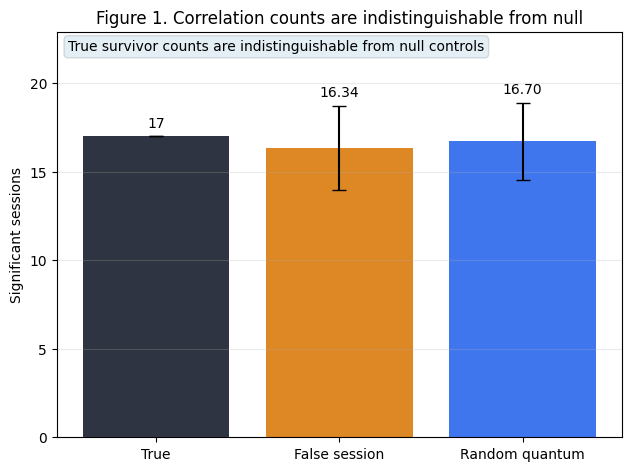

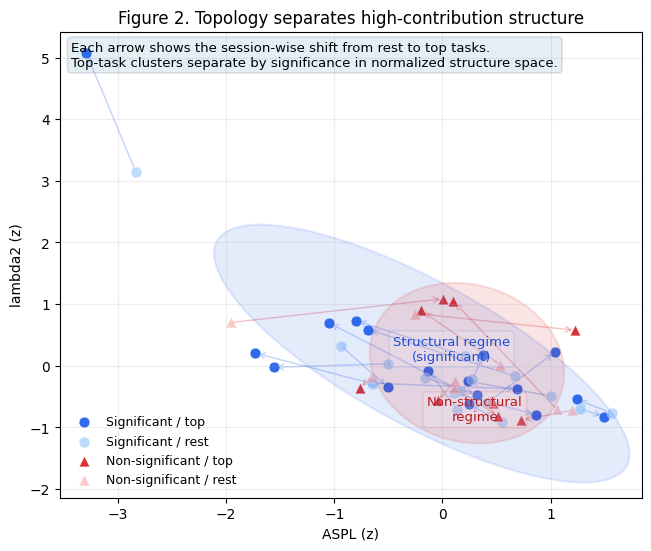

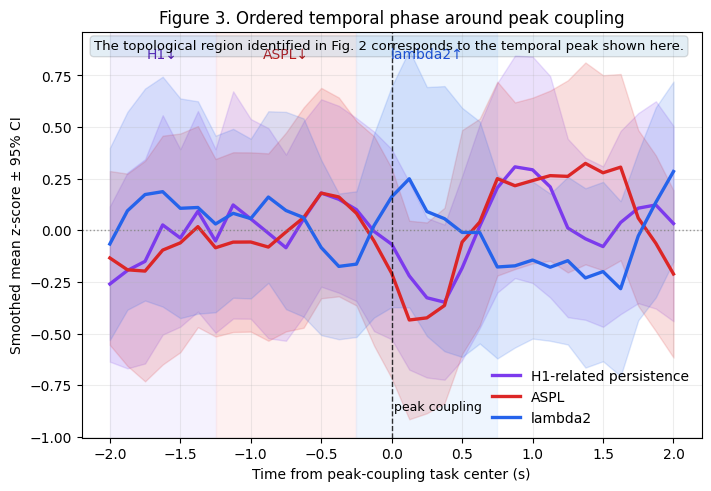

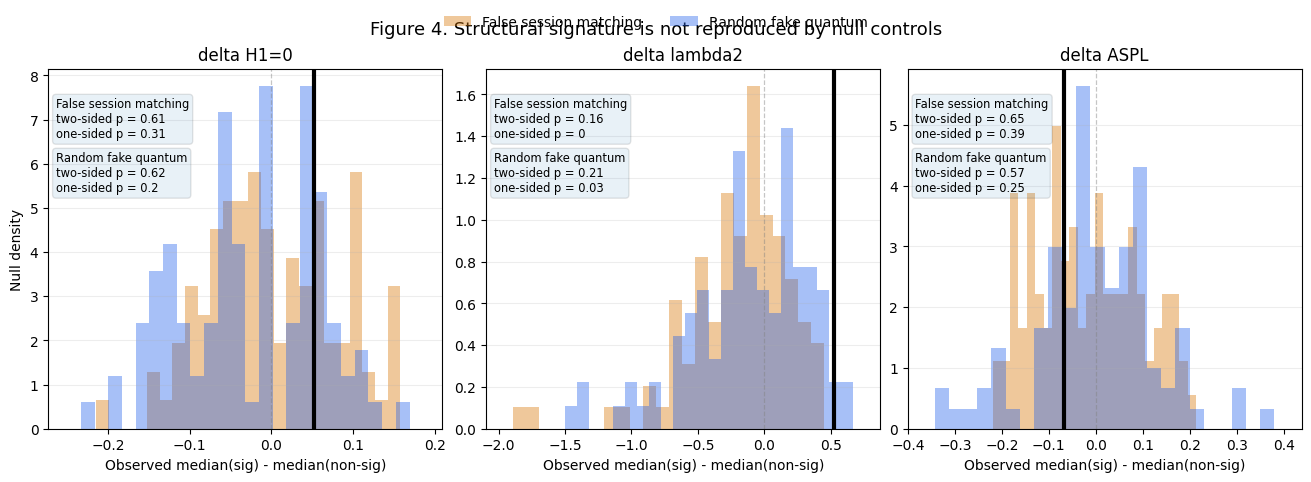

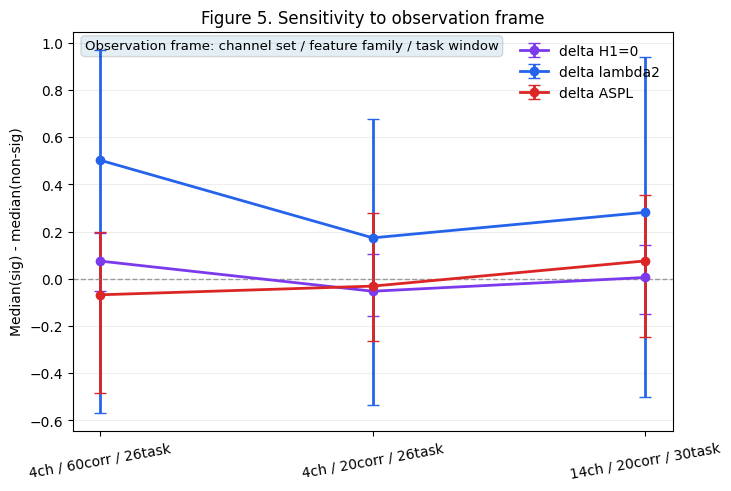

In [73]:
primary_key = primary_data["frame_key"]

# Figure 1
counts = primary_null["counts"].copy()
true_n = int(primary_data["session_summary"]["is_sig_session"].sum())
false_vals = counts.loc[counts["condition"] == "false_session_matching", "significant_sessions"].to_numpy(float)
fake_vals = counts.loc[counts["condition"] == "random_fake_quantum", "significant_sessions"].to_numpy(float)
fig, ax = plt.subplots(figsize=(6.2, 4.6), constrained_layout=True)
plot_df = pd.DataFrame(
    [
        {"label": "True", "mean_sig_n": float(true_n), "sd_sig_n": 0.0},
        {"label": "False session", "mean_sig_n": float(np.mean(false_vals)), "sd_sig_n": float(np.std(false_vals, ddof=1))},
        {"label": "Random quantum", "mean_sig_n": float(np.mean(fake_vals)), "sd_sig_n": float(np.std(fake_vals, ddof=1))},
    ]
)
x = np.arange(len(plot_df))
ax.bar(x, plot_df["mean_sig_n"], yerr=plot_df["sd_sig_n"], color=["#111827", "#d97706", "#2563eb"], alpha=0.88, capsize=5)
for i, row in plot_df.iterrows():
    txt = f"{int(row['mean_sig_n'])}" if row["sd_sig_n"] == 0 else f"{row['mean_sig_n']:.2f}"
    ax.text(i, row["mean_sig_n"] + row["sd_sig_n"] + 0.35, txt, ha="center", va="bottom", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"])
ax.set_ylabel("Significant sessions")
ax.set_title("Figure 1. Correlation counts are indistinguishable from null")
ax.grid(axis="y", alpha=0.25)
ax.set_ylim(0, max(plot_df["mean_sig_n"] + plot_df["sd_sig_n"]) + 4)
ax.text(
    0.02,
    0.98,
    "True survivor counts are indistinguishable from null controls",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.12),
)
save_figure(fig, f"{primary_key}_Figure1_correlation_counts")


# Figure 2
topo_sig = primary_data["topology_signature"].copy()
plot_rows = []
for _, row in topo_sig.iterrows():
    plot_rows.append(
        {
            "label": row["label"],
            "is_sig_session": row["is_sig_session"],
            "zone": "top",
            "lambda2": row["top_lambda2"],
            "aspl": row["top_aspl"],
        }
    )
    plot_rows.append(
        {
            "label": row["label"],
            "is_sig_session": row["is_sig_session"],
            "zone": "rest",
            "lambda2": row["rest_lambda2"],
            "aspl": row["rest_aspl"],
        }
    )
plot_df = pd.DataFrame(plot_rows)
plot_df["lambda2_z"] = zscore(plot_df["lambda2"])
plot_df["aspl_z"] = zscore(plot_df["aspl"])

style = {
    (1, "top"): {"label": "Significant / top", "color": "#2563eb", "marker": "o", "alpha": 0.95},
    (1, "rest"): {"label": "Significant / rest", "color": "#93c5fd", "marker": "o", "alpha": 0.60},
    (0, "top"): {"label": "Non-significant / top", "color": "#dc2626", "marker": "^", "alpha": 0.95},
    (0, "rest"): {"label": "Non-significant / rest", "color": "#fca5a5", "marker": "^", "alpha": 0.60},
}

fig, ax = plt.subplots(figsize=(6.4, 5.4), constrained_layout=True)
for _, row in topo_sig.iterrows():
    rest = plot_df[(plot_df["label"] == row["label"]) & (plot_df["zone"] == "rest")].iloc[0]
    top = plot_df[(plot_df["label"] == row["label"]) & (plot_df["zone"] == "top")].iloc[0]
    color = "#2563eb" if row["is_sig_session"] == 1 else "#dc2626"
    ax.annotate(
        "",
        xy=(top["aspl_z"], top["lambda2_z"]),
        xytext=(rest["aspl_z"], rest["lambda2_z"]),
        arrowprops=dict(arrowstyle="->", color=color, alpha=0.28, linewidth=1.0),
        zorder=1,
    )
for key, sty in style.items():
    sub = plot_df[(plot_df["is_sig_session"] == key[0]) & (plot_df["zone"] == key[1])]
    ax.scatter(
        sub["aspl_z"],
        sub["lambda2_z"],
        s=62,
        color=sty["color"],
        marker=sty["marker"],
        alpha=sty["alpha"],
        edgecolor="white",
        linewidth=0.5,
        label=sty["label"],
    )

sig_top = plot_df[(plot_df["is_sig_session"] == 1) & (plot_df["zone"] == "top")]
non_top = plot_df[(plot_df["is_sig_session"] == 0) & (plot_df["zone"] == "top")]
add_cov_ellipse(ax, sig_top["aspl_z"], sig_top["lambda2_z"], "#2563eb", n_std=1.55, alpha=0.12)
add_cov_ellipse(ax, non_top["aspl_z"], non_top["lambda2_z"], "#dc2626", n_std=1.55, alpha=0.12)
ax.text(
    float(sig_top["aspl_z"].median()) - 0.15,
    float(sig_top["lambda2_z"].median()) + 0.35,
    "Structural regime\n(significant)",
    color="#1d4ed8",
    fontsize=9.5,
    ha="center",
    va="center",
    bbox=dict(boxstyle="round", alpha=0.12, facecolor="white", edgecolor="#2563eb"),
)
ax.text(
    float(non_top["aspl_z"].median()) + 0.2,
    float(non_top["lambda2_z"].median()) - 0.35,
    "Non-structural\nregime",
    color="#b91c1c",
    fontsize=9.5,
    ha="center",
    va="center",
    bbox=dict(boxstyle="round", alpha=0.12, facecolor="white", edgecolor="#dc2626"),
)
ax.set_xlabel("ASPL (z)")
ax.set_ylabel("lambda2 (z)")
ax.set_title("Figure 2. Topology separates high-contribution structure")
ax.grid(alpha=0.22)
ax.legend(frameon=False, fontsize=9, loc="best")
ax.text(
    0.02,
    0.98,
    "Each arrow shows the session-wise shift from rest to top tasks.\nTop-task clusters separate by significance in normalized structure space.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round", alpha=0.12),
)
save_figure(fig, f"{primary_key}_Figure2_topology_separation")
topo_sig.to_csv(REPRO_CSV_DIR / f"{primary_key}_Figure2_top_rest_points.csv", index=False)


# Figure 3
fig, ax = plt.subplots(figsize=(7.0, 4.8), constrained_layout=True)
if len(sliding_agg_df) > 0:
    t = sliding_agg_df["rel_t_sec"].to_numpy(float)
    mean_h1 = moving_average_centered(sliding_agg_df["mean_h1"], 3)
    mean_lambda2 = moving_average_centered(sliding_agg_df["mean_lambda2"], 3)
    mean_aspl = moving_average_centered(sliding_agg_df["mean_aspl"], 3)
    ci_h1 = 1.96 * moving_average_centered(sliding_agg_df["sem_h1"], 3)
    ci_lambda2 = 1.96 * moving_average_centered(sliding_agg_df["sem_lambda2"], 3)
    ci_aspl = 1.96 * moving_average_centered(sliding_agg_df["sem_aspl"], 3)

    ax.axvspan(-2.0, -1.25, color="#ede9fe", alpha=0.55, zorder=0)
    ax.axvspan(-1.25, -0.25, color="#fee2e2", alpha=0.45, zorder=0)
    ax.axvspan(-0.25, 0.75, color="#dbeafe", alpha=0.45, zorder=0)

    ax.fill_between(t, mean_h1 - ci_h1, mean_h1 + ci_h1, color="#7c3aed", alpha=0.15)
    ax.fill_between(t, mean_aspl - ci_aspl, mean_aspl + ci_aspl, color="#dc2626", alpha=0.15)
    ax.fill_between(t, mean_lambda2 - ci_lambda2, mean_lambda2 + ci_lambda2, color="#2563eb", alpha=0.15)

    ax.plot(t, mean_h1, color="#7c3aed", linewidth=2.4, label="H1-related persistence")
    ax.plot(t, mean_aspl, color="#dc2626", linewidth=2.4, label="ASPL")
    ax.plot(t, mean_lambda2, color="#2563eb", linewidth=2.4, label="lambda2")
ax.axvline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.8)
ax.axhline(0, color="gray", linestyle=":", linewidth=1.0, alpha=0.8)
ax.set_xlabel("Time from peak-coupling task center (s)")
ax.set_ylabel("Smoothed mean z-score ± 95% CI")
ax.set_title("Figure 3. Ordered temporal phase around peak coupling")
ax.grid(alpha=0.22)
ax.legend(frameon=False, loc="best")
ax.text(0.02, 0.06, "peak coupling", transform=ax.get_xaxis_transform(), ha="left", va="bottom", fontsize=9, color="black")
ax.text(-1.63, ax.get_ylim()[1] * 0.92, "H1↓", ha="center", va="top", fontsize=10, color="#5b21b6")
ax.text(-0.75, ax.get_ylim()[1] * 0.92, "ASPL↓", ha="center", va="top", fontsize=10, color="#b91c1c")
ax.text(0.25, ax.get_ylim()[1] * 0.92, "lambda2↑", ha="center", va="top", fontsize=10, color="#1d4ed8")
ax.text(
    0.02,
    0.98,
    "The topological region identified in Fig. 2 corresponds to the temporal peak shown here.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round", alpha=0.12),
)
save_figure(fig, f"{primary_key}_Figure3_temporal_phase")


# Figure 4
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.6), constrained_layout=True)
pvalues = pd.read_csv(REPRO_CSV_DIR / f"{primary_key}_null_pvalues.csv")
null_diffs = primary_null["null_diffs"]
observed = primary_null["observed"]
metrics = [
    ("delta_h1_zero", "delta H1=0"),
    ("delta_lambda2", "delta lambda2"),
    ("delta_aspl", "delta ASPL"),
]
cond_style = {
    "false_session_matching": {"label": "False session matching", "color": "#d97706"},
    "random_fake_quantum": {"label": "Random fake quantum", "color": "#2563eb"},
}
for ax, (metric, title) in zip(axes, metrics):
    observed_value = float(observed.loc[observed["metric"] == metric, "observed_diff"].iloc[0])
    vals_all = []
    for condition, sty in cond_style.items():
        vals = pd.to_numeric(
            null_diffs.loc[(null_diffs["condition"] == condition) & (null_diffs["metric"] == metric), "median_diff"],
            errors="coerce",
        ).dropna().to_numpy(float)
        vals_all.append(vals)
        ax.hist(vals, bins=24, density=True, alpha=0.40, color=sty["color"], label=sty["label"])
        row = pvalues[(pvalues["condition"] == condition) & (pvalues["metric"] == metric)].iloc[0]
        ax.text(
            0.02,
            0.92 if condition == "false_session_matching" else 0.77,
            f"{sty['label']}\n"
            f"two-sided p = {float(row['p_two_sided']):.3g}\n"
            f"one-sided p = {float(row['p_one_sided']):.3g}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.3,
            bbox=dict(boxstyle="round", alpha=0.10),
        )
    ax.axvline(observed_value, color="black", linewidth=3.0)
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.9, alpha=0.45)
    lo = min(np.min(v) for v in vals_all if len(v) > 0)
    hi = max(np.max(v) for v in vals_all if len(v) > 0)
    pad = max(0.04, 0.08 * (hi - lo if hi > lo else 1.0))
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_title(title)
    ax.set_xlabel("Observed median(sig) - median(non-sig)")
    ax.grid(axis="y", alpha=0.22)
axes[0].set_ylabel("Null density")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Figure 4. Structural signature is not reproduced by null controls", fontsize=13)
save_figure(fig, f"{primary_key}_Figure4_null_robustness")


# Figure 5
fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
x = np.arange(len(frame_comparison_df))
spec = [
    ("delta_h1_zero", "#7c3aed", "delta H1=0"),
    ("delta_lambda2", "#2563eb", "delta lambda2"),
    ("delta_aspl", "#dc2626", "delta ASPL"),
]
for metric, color, label in spec:
    y = frame_comparison_df[metric].to_numpy(float)
    yerr = np.vstack(
        [
            y - frame_comparison_df[f"{metric}_lo"].to_numpy(float),
            frame_comparison_df[f"{metric}_hi"].to_numpy(float) - y,
        ]
    )
    ax.errorbar(x, y, yerr=yerr, marker="o", linewidth=2.0, capsize=4, color=color, label=label)
ax.axhline(0, color="gray", linestyle="--", linewidth=1.0, alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(frame_comparison_df["condition"], rotation=10)
ax.set_ylabel("Median(sig) - median(non-sig)")
ax.set_title("Figure 5. Sensitivity to observation frame")
ax.grid(axis="y", alpha=0.22)
ax.legend(frameon=False, loc="best")
ax.text(
    0.02,
    0.98,
    "Observation frame: channel set / feature family / task window",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    bbox=dict(boxstyle="round", alpha=0.12),
)
save_figure(fig, f"{primary_key}_Figure5_frame_dependence")

## 8. Export summary

In [74]:
print("Primary frame key:", primary_key)
print("Saved CSV files:")
for path in sorted(REPRO_CSV_DIR.glob(f"{primary_key}*.csv")):
    print(" -", path)
print("Saved figures:")
for path in sorted(REPRO_FIG_DIR.glob(f"{primary_key}*.png")):
    print(" -", path)
print("Shared comparison CSV:")
print(" -", REPRO_CSV_DIR / "frame_comparison_summary.csv")

Primary frame key: 4ch_60corr_26task
Saved CSV files:
 - Repro_CSV/4ch_60corr_26task_Figure2_top_rest_points.csv
 - Repro_CSV/4ch_60corr_26task_null_counts.csv
 - Repro_CSV/4ch_60corr_26task_null_group_diffs.csv
 - Repro_CSV/4ch_60corr_26task_null_pvalues.csv
 - Repro_CSV/4ch_60corr_26task_observed_group_diffs.csv
 - Repro_CSV/4ch_60corr_26task_session_summary.csv
 - Repro_CSV/4ch_60corr_26task_sliding_aggregate.csv
 - Repro_CSV/4ch_60corr_26task_sliding_profiles.csv
 - Repro_CSV/4ch_60corr_26task_task_table.csv
 - Repro_CSV/4ch_60corr_26task_topology_signature.csv
 - Repro_CSV/4ch_60corr_26task_topology_tasks.csv
Saved figures:
 - Repro_Figure/4ch_60corr_26task_Figure1_correlation_counts.png
 - Repro_Figure/4ch_60corr_26task_Figure2_topology_separation.png
 - Repro_Figure/4ch_60corr_26task_Figure3_temporal_phase.png
 - Repro_Figure/4ch_60corr_26task_Figure4_null_robustness.png
 - Repro_Figure/4ch_60corr_26task_Figure5_frame_dependence.png
Shared comparison CSV:
 - Repro_CSV/frame_comp

## Output checklist

After a successful run, check the following folders.

### `Repro_Figure`

You should see five PNG files and five PDF files for the current primary frame:

- `..._Figure1_correlation_counts`
- `..._Figure2_topology_separation`
- `..._Figure3_temporal_phase`
- `..._Figure4_null_robustness`
- `..._Figure5_frame_dependence`

### `Repro_CSV`

You should also see:

- task-level tables
- session-level FDR summaries
- topology signature tables
- null simulation summaries
- sliding-profile summaries
- frame-comparison summary